# EDA for Steam Game Traffic Forecasting

This notebook performs a professional EDA on Steam hourly traffic data for time-series forecasting.

## 1. Data Loading and Overview
Understanding data structure, size, and basic stats is crucial for forecasting. 


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Data loading and overview
df = pd.read_csv('Data_sets/steam_data.csv')
print(f"Dataset shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\nData types:")
print(df.dtypes)
print("\nFirst 5 rows:")
display(df.head())
print("\nBasic statistics:")
display(df.describe())
print("\nUnique games:", df['title'].nunique())
print("Date range:", df['day'].min(), "to", df['day'].max())

Dataset shape: (723700, 7)
Memory usage: 114.47 MB

Data types:
title              object
current_players     int64
peak_players        int64
hours_played        int64
hour                int64
day                object
rank                int64
dtype: object

First 5 rows:


,title,current_players,peak_players,hours_played,hour,day,rank
0,PLAYERUNKNOWN'S BATTLEGROUNDS,1132794,2424072,747326321,13,2018-05-11,1
1,Dota 2,498138,766124,317244913,13,2018-05-11,2
2,Counter-Strike: Global Offensive,205744,501226,200507183,13,2018-05-11,3
3,Tom Clancy's Rainbow Six Siege,56480,124813,44385670,13,2018-05-11,4
4,Grand Theft Auto V,45830,78968,28078644,13,2018-05-11,5



Basic statistics:


,current_players,peak_players,hours_played,hour,rank
count,7.237000e+05,7.237000e+05,7.237000e+05,723700.000000,723700.00000
mean,2.594299e+04,5.136433e+04,1.870239e+07,11.497167,50.50000
std,8.755178e+04,1.642419e+05,5.954488e+07,6.923891,28.86609
min,6.000000e+02,6.430000e+02,1.834000e+03,0.000000,1.00000
25%,4.679000e+03,9.464000e+03,3.422256e+06,5.000000,25.75000
50%,7.896000e+03,1.618900e+04,5.831643e+06,11.000000,50.50000
75%,1.504900e+04,2.939800e+04,1.057552e+07,17.000000,75.25000
max,1.861002e+06,2.424072e+06,7.673227e+08,23.000000,100.00000



Unique games: 507
Date range: 2018-05-11 to 2019-03-14


## 2. Data Types and Memory Optimization


In [3]:

# Optimize data types (robust to missing 'day' column)
date_cols = ['day', 'datetime', 'date', 'timestamp']
found = [c for c in date_cols if c in df.columns]
if 'day' in df.columns:
    df['day'] = pd.to_datetime(df['day'])
elif 'datetime' in df.columns:
    df['datetime'] = pd.to_datetime(df['datetime'])
    # create a 'day' column for compatibility with downstream cells
    df['day'] = df['datetime'].dt.date
elif 'timestamp' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df['day'] = df['timestamp'].dt.date
else:
    # no recognizable date column; print helpful diagnostics
    print('Warning: no standard date column found. Available columns:', list(df.columns))

# Cast numeric columns if they exist
if 'hour' in df.columns:
    df['hour'] = df['hour'].astype('int8')
if 'rank' in df.columns:
    df['rank'] = df['rank'].astype('int8')
if 'current_players' in df.columns:
    df['current_players'] = df['current_players'].astype('int32')
if 'peak_players' in df.columns:
    df['peak_players'] = df['peak_players'].astype('int32')
if 'hours_played' in df.columns:
    df['hours_played'] = df['hours_played'].astype('int64') 

print("Optimized data types:")
print(df.dtypes)
print(f"Memory usage after optimization: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Optimized data types:
title                      object
current_players             int32
peak_players                int32
hours_played                int64
hour                         int8
day                datetime64[ns]
rank                         int8
dtype: object
Memory usage after optimization: 64.73 MB


## 3. Missing Value Analysis
 

In [4]:
 

# Missing values per column
missing = df.isnull().sum()
print("\nMissing values per column:")
print(missing)
# Total missing values
print("\nTotal missing values in dataset:")
print(df.isnull().sum().sum())



Missing values per column:
title              0
current_players    0
peak_players       0
hours_played       0
hour               0
day                0
rank               0
dtype: int64

Total missing values in dataset:
0


## 4. Duplicate Detection
 

In [5]:
 
duplicates = df.duplicated(subset=['title', 'day', 'hour'], keep=False)
print(f"Number of duplicate records: {duplicates.sum()}")

if duplicates.sum() > 0:
    print("Duplicate examples:")
    display(df[duplicates].head())

# Remove duplicates if any
df = df.drop_duplicates(subset=['title', 'day', 'hour'], keep='first')
print(f"Shape after removing duplicates: {df.shape}")

Number of duplicate records: 68
Duplicate examples:


,title,current_players,peak_players,hours_played,hour,day,rank
492824,Terraria,9985,26951,11248204,9,2018-12-07,25
492825,Terraria,9356,26951,11248204,9,2018-12-07,26
493024,Total War: WARHAMMER II,9649,42870,14191757,11,2018-12-07,25
493025,Total War: WARHAMMER II,10043,42870,14191757,11,2018-12-07,26
493249,The Elder Scrolls V: Skyrim Special Edition,6358,18666,7507449,13,2018-12-07,50


Shape after removing duplicates: (723666, 7)


## 5. Datetime Creation and Time Indexing


In [6]:
 
df['datetime'] = pd.to_datetime(df['day'].astype(str) + ' ' + df['hour'].astype(str) + ':00:00')
 
df = df.set_index('datetime').sort_index()

print("Datetime index created:")
print(df.index[:5])

# Check time range
print(f"\nTime range: {df.index.min()} to {df.index.max()}")
print(f"Total hours: {len(df.index.unique())}")

Datetime index created:
DatetimeIndex(['2018-05-11 13:00:00', '2018-05-11 13:00:00',
               '2018-05-11 13:00:00', '2018-05-11 13:00:00',
               '2018-05-11 13:00:00'],
              dtype='datetime64[ns]', name='datetime', freq=None)

Time range: 2018-05-11 13:00:00 to 2019-03-14 13:00:00
Total hours: 7237


## 6. Time-Series Consistency Checks


In [7]:
full_range = pd.date_range(
    start=df.index.min(),
    end=df.index.max(),
    freq='H'
)

missing_hours = full_range.difference(df.index.unique())

print(f"Missing hours in dataset: {len(missing_hours)}")

Missing hours in dataset: 132


In [8]:
import pandas as pd
import numpy as np

df_clean = df.copy()

df_clean = df_clean.reset_index()

df_clean['year'] = df_clean['datetime'].dt.year
df_clean['month'] = df_clean['datetime'].dt.month
df_clean['day_of_month'] = df_clean['datetime'].dt.day

df_clean['hour'] = df_clean['datetime'].dt.hour

df_clean['day_of_week'] = df_clean['datetime'].dt.dayofweek

df_clean['is_weekend'] = (
    df_clean['day_of_week'] >= 5
).astype(int)

df_clean['quarter'] = df_clean['datetime'].dt.quarter

df_clean['week_of_year'] = (
    df_clean['datetime']
    .dt
    .isocalendar()
    .week
    .astype(int)
)

# cyclic encoding
df_clean['hour_sin'] = np.sin(
    2 * np.pi * df_clean['hour'] / 24
)

df_clean['hour_cos'] = np.cos(
    2 * np.pi * df_clean['hour'] / 24
)

df_clean = df_clean.sort_values(
    ['title', 'datetime']
)

# lag features
df_clean['lag_1'] = (
    df_clean
    .groupby('title')['current_players']
    .shift(1)
)

df_clean['lag_24'] = (
    df_clean
    .groupby('title')['current_players']
    .shift(24)
)

# rolling statistics
df_clean['rolling_mean_24'] = (
    df_clean
    .groupby('title')['current_players']
    .transform(
        lambda x: x.rolling(24).mean()
    )
)

df_clean['rolling_std_24'] = (
    df_clean
    .groupby('title')['current_players']
    .transform(
        lambda x: x.rolling(24).std()
    )
)

df_clean = df_clean.dropna()

column_order = [

    'datetime',
    'title',

    'current_players',
    'peak_players',
    'hours_played',
    'rank',

    'lag_1',
    'lag_24',

    'rolling_mean_24',
    'rolling_std_24',

    'year',
    'month',
    'day_of_month',

    'hour',
    'day_of_week',
    'is_weekend',

    'quarter',
    'week_of_year',

    'hour_sin',
    'hour_cos'
]

df_clean = df_clean[column_order]

output_path = 'Data_sets/steam_clean.csv'

df_clean.to_csv(
    output_path,
    index=False
)
 
print("CLEAN DATASET CREATED")
 
print(f"\nFile Saved : {output_path}")

print(f"\nShape : {df_clean.shape}")

print(f"\nRows : {len(df_clean):,}")

print(f"\nColumns : {len(df_clean.columns)}")

print(
    f"\nMemory Usage : "
    f"{df_clean.memory_usage(deep=True).sum() / 1024**2:.2f} MB"
)

print("\nColumns:")
print(df_clean.columns.tolist())

print("\nFirst 5 Rows:")
display(df_clean.head())

print("\nData Types:")
print(df_clean.dtypes)

CLEAN DATASET CREATED

File Saved : Data_sets/steam_clean.csv

Shape : (715493, 20)

Rows : 715,493

Columns : 20

Memory Usage : 128.79 MB

Columns:
['datetime', 'title', 'current_players', 'peak_players', 'hours_played', 'rank', 'lag_1', 'lag_24', 'rolling_mean_24', 'rolling_std_24', 'year', 'month', 'day_of_month', 'hour', 'day_of_week', 'is_weekend', 'quarter', 'week_of_year', 'hour_sin', 'hour_cos']

First 5 Rows:


,datetime,title,current_players,peak_players,hours_played,rank,lag_1,lag_24,rolling_mean_24,rolling_std_24,year,month,day_of_month,hour,day_of_week,is_weekend,quarter,week_of_year,hour_sin,hour_cos
2462,2018-05-12 13:00:00,7 Days to Die,6635,13373,5295551,63,6455.0,4795.0,7178.333333,904.850296,2018,5,12,13,5,1,2,19,-0.258819,-0.965926
2562,2018-05-12 14:00:00,7 Days to Die,6973,13373,5302524,63,6635.0,5266.0,7249.458333,810.128169,2018,5,12,14,5,1,2,19,-0.500000,-0.866025
2661,2018-05-12 15:00:00,7 Days to Die,7807,13373,5310331,62,6973.0,5841.0,7331.375000,759.322513,2018,5,12,15,5,1,2,19,-0.707107,-0.707107
2761,2018-05-12 16:00:00,7 Days to Die,8464,13373,5318795,62,7807.0,6517.0,7412.500000,772.427230,2018,5,12,16,5,1,2,19,-0.866025,-0.500000
2861,2018-05-12 17:00:00,7 Days to Die,9168,13373,5327963,62,8464.0,7212.0,7494.000000,849.679582,2018,5,12,17,5,1,2,19,-0.965926,-0.258819



Data Types:
datetime           datetime64[ns]
title                      object
current_players             int32
peak_players                int32
hours_played                int64
rank                         int8
lag_1                     float64
lag_24                    float64
rolling_mean_24           float64
rolling_std_24            float64
year                        int32
month                       int32
day_of_month                int32
hour                        int32
day_of_week                 int32
is_weekend                  int64
quarter                     int32
week_of_year                int64
hour_sin                  float64
hour_cos                  float64
dtype: object


## 6. Top Games Selection for Forecasting

Selecting the top games by average `current_players` helps focus our forecasting model on titles with the strongest demand signals. These games usually have clearer traffic patterns and more reliable historical data for training.

Top 20 Games Selected for Modeling:
----------------------------------------------------------------------
                           title  avg_current_players
   PLAYERUNKNOWN'S BATTLEGROUNDS        560523.786618
                          Dota 2        475214.567000
Counter-Strike: Global Offensive        327905.648457
  Tom Clancy's Rainbow Six Siege         69353.062709
           MONSTER HUNTER: WORLD         57024.054743
                        Warframe         56947.928363
              Grand Theft Auto V         55883.761653
                 Team Fortress 2         46833.439933
           ARK: Survival Evolved         37419.986654
           Football Manager 2019         36149.232728
                            Rust         35930.254313
                   Rocket League         33614.536589
                 Devil May Cry 5         29494.129032
                     Garry's Mod         27259.834839
                   Path of Exile         26947.488443
      Sid Meier's Civilizatio

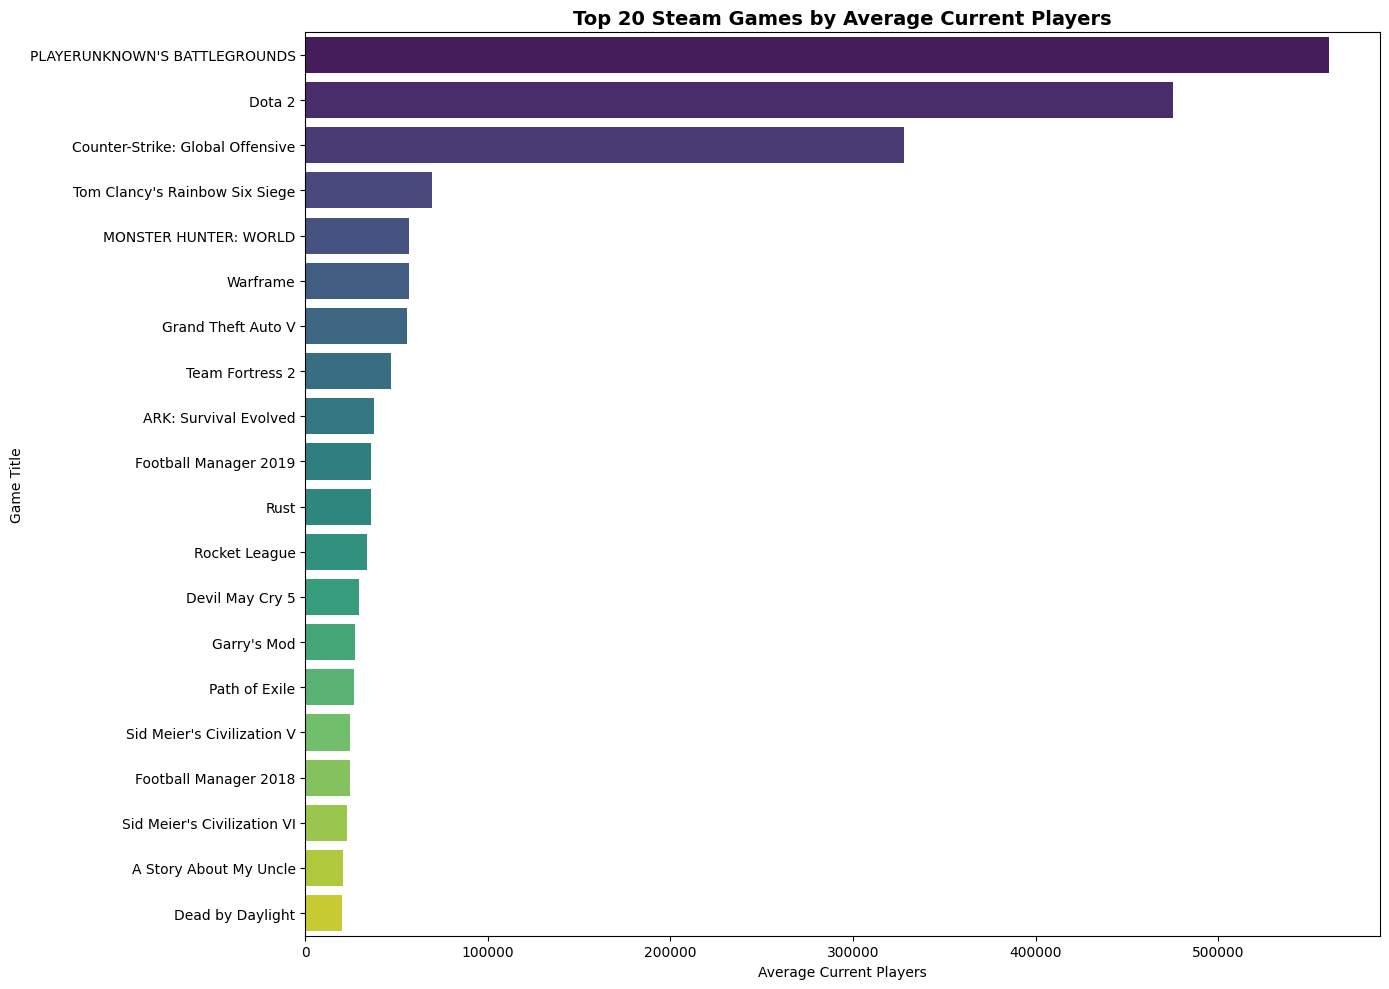

Filtered dataset saved to: Data_sets/top_games_dataset.csv


In [9]:
# 1. Group games by average current_players
average_players = (
    df_clean
    .groupby('title', as_index=False)
    ['current_players']
    .mean()
    .rename(columns={'current_players': 'avg_current_players'})
)

# 2. Select the top 20 games by average current_players
top_games = (
    average_players
    .sort_values(by='avg_current_players', ascending=False)
    .head(20)
)

# 3. Filter the dataset to keep only those top games
top_games_list = top_games['title'].tolist()
filtered_top_games = (
    df_clean
    [df_clean['title'].isin(top_games_list)]
    .sort_values(by=['title', 'datetime'])
    .reset_index(drop=True)
)

# 4. Print summary information
print('Top 20 Games Selected for Modeling:')
print('-' * 70)
print(top_games[['title', 'avg_current_players']].to_string(index=False))
print('\nFinal filtered dataset shape:', filtered_top_games.shape)
print('\nNumber of records per game:')
print(filtered_top_games['title'].value_counts().sort_index())

# 5. Clean visualization: barplot of top games by average current_players
plt.figure(figsize=(14, 10))
ax = sns.barplot(
    data=top_games,
    x='avg_current_players',
    y='title',
    palette='viridis'
)
ax.set_title('Top 20 Steam Games by Average Current Players', fontsize=14, fontweight='bold')
ax.set_xlabel('Average Current Players')
ax.set_ylabel('Game Title')
plt.tight_layout()
plt.show()

# 6. Save filtered dataset for model training
output_file = 'Data_sets/top_games_dataset.csv'
filtered_top_games.to_csv(output_file, index=False)
print(f'Filtered dataset saved to: {output_file}')

## Top 20 Pure AutoReg Pipeline

This section builds a complete pure AutoRegressive forecasting pipeline for the top 20 Steam games. It evaluates sparse lag configurations on validation data, uses rolling 24-hour forecasting to avoid flatlining, and saves the best pretrained AR model for each game.

## Save Cleaned Data to CSV

Export the cleaned and feature-engineered dataset for model building and future analysis.

## 7. Distribution Analysis of Numerical Features
 

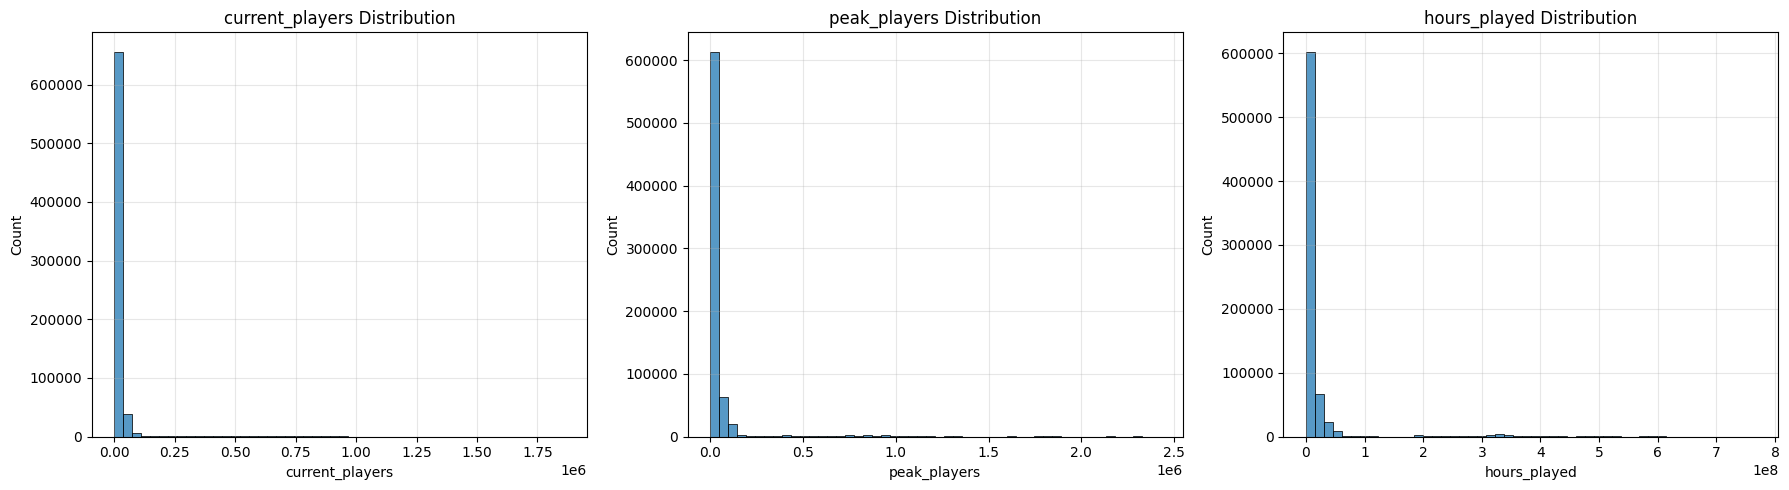

In [10]:
# # Distribution analysis
# numerical_cols = ['current_players', 'peak_players', 'hours_played']

# fig, axes = plt.subplots(1, 3, figsize=(18, 10))

# for i, col in enumerate(numerical_cols):
#     # Histogram
#     sns.histplot(df[col], bins=50, ax=axes[0, i])
#     axes[0, i].set_title(f'{col} Distribution')
     
 
# Distribution analysis

numerical_cols = [
    'current_players',
    'peak_players',
    'hours_played'
]

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

for i, col in enumerate(numerical_cols):

    sns.histplot(
        df[col],
        bins=50,
        ax=axes[i]
    )

    axes[i].set_title(
        f'{col} Distribution'
    )

    axes[i].set_xlabel(col)

    axes[i].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

## 8. Outlier and Anomaly Detection
 

Percentage of outliers per game: title
- Arcane RERaise -               0.00
- Arcane preRaise -              0.00
12 is Better Than 6              0.00
3D ParticleGen Visual FX        25.00
3SwitcheD                        0.00
                                ...  
天命奇御 Fate Seeker                 0.00
太吾绘卷 The Scroll Of Taiwu        11.00
武侠乂                              0.00
隐形守护者 The Invisible Guardian     1.48
音灵 INVAXION                      0.00
Name: current_players, Length: 507, dtype: float64


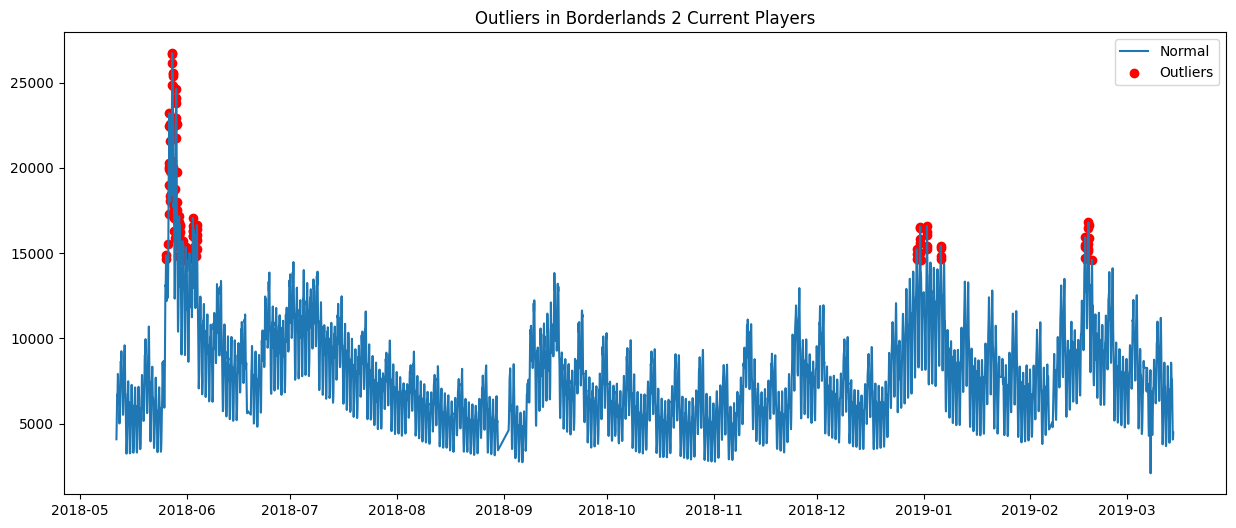

In [11]:
# Outlier detection using IQR
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return (data < lower_bound) | (data > upper_bound)

outliers = df.groupby('title')['current_players'].apply(detect_outliers_iqr)
print(f"Percentage of outliers per game: {(outliers.groupby(level=0).sum() / outliers.groupby(level=0).size() * 100).round(2)}")

# Visualize outliers for top game
top_game = df['title'].value_counts().index[0]
top_game_data = df[df['title'] == top_game]

plt.figure(figsize=(15, 6))
plt.plot(top_game_data.index, top_game_data['current_players'], label='Normal')
outlier_points = top_game_data[detect_outliers_iqr(top_game_data['current_players'])]
plt.scatter(outlier_points.index, outlier_points['current_players'], color='red', label='Outliers')
plt.title(f'Outliers in {top_game} Current Players')
plt.legend()
plt.show()

## 9. Game-wise Traffic Analysis 

Top 10 games by average players:


current_players                            \
                                            mean       std      max    min   
title                                                                        
PLAYERUNKNOWN'S BATTLEGROUNDS           562171.0  330574.0  1861002  13295   
Dota 2                                  475383.0  150770.0  1033925  25635   
Counter-Strike: Global Offensive        327767.0  129857.0   746548  17710   
Tom Clancy's Rainbow Six Siege           69348.0   19923.0   143866   8510   
MONSTER HUNTER: WORLD                    57763.0   54851.0   329333   8018   
Warframe                                 56915.0   17365.0   131766   8639   
Grand Theft Auto V                       55870.0   22133.0   162021  13457   
Hyperdrive Massacre                      52655.0   51379.0   180471   5369   
Team Fortress 2                          46820.0    9924.0   116141  18340   
Braveland                                39847.0   54830.0   216331   2109   

                                 peak_players   hours_played  
                                          max            sum  
title                                                         
PLAYERUNKNOWN'S BATTLEGROUNDS         2424072  3108926893232  
Dota 2                                1033925  2465953198303  
Counter-Strike: Global Offensive       746548  1692386629711  
Tom Clancy's Rainbow Six Siege         143866   361110242489  
MONSTER HUNTER: WORLD                  329333   209129875954  
Warframe                               131766   296003354586  
Grand Theft Auto V                     162021   286746110806  
Hyperdrive Massacre                    180471       34249783  
Team Fortress 2                        116141   244121113229  
Braveland                              216331       57242559

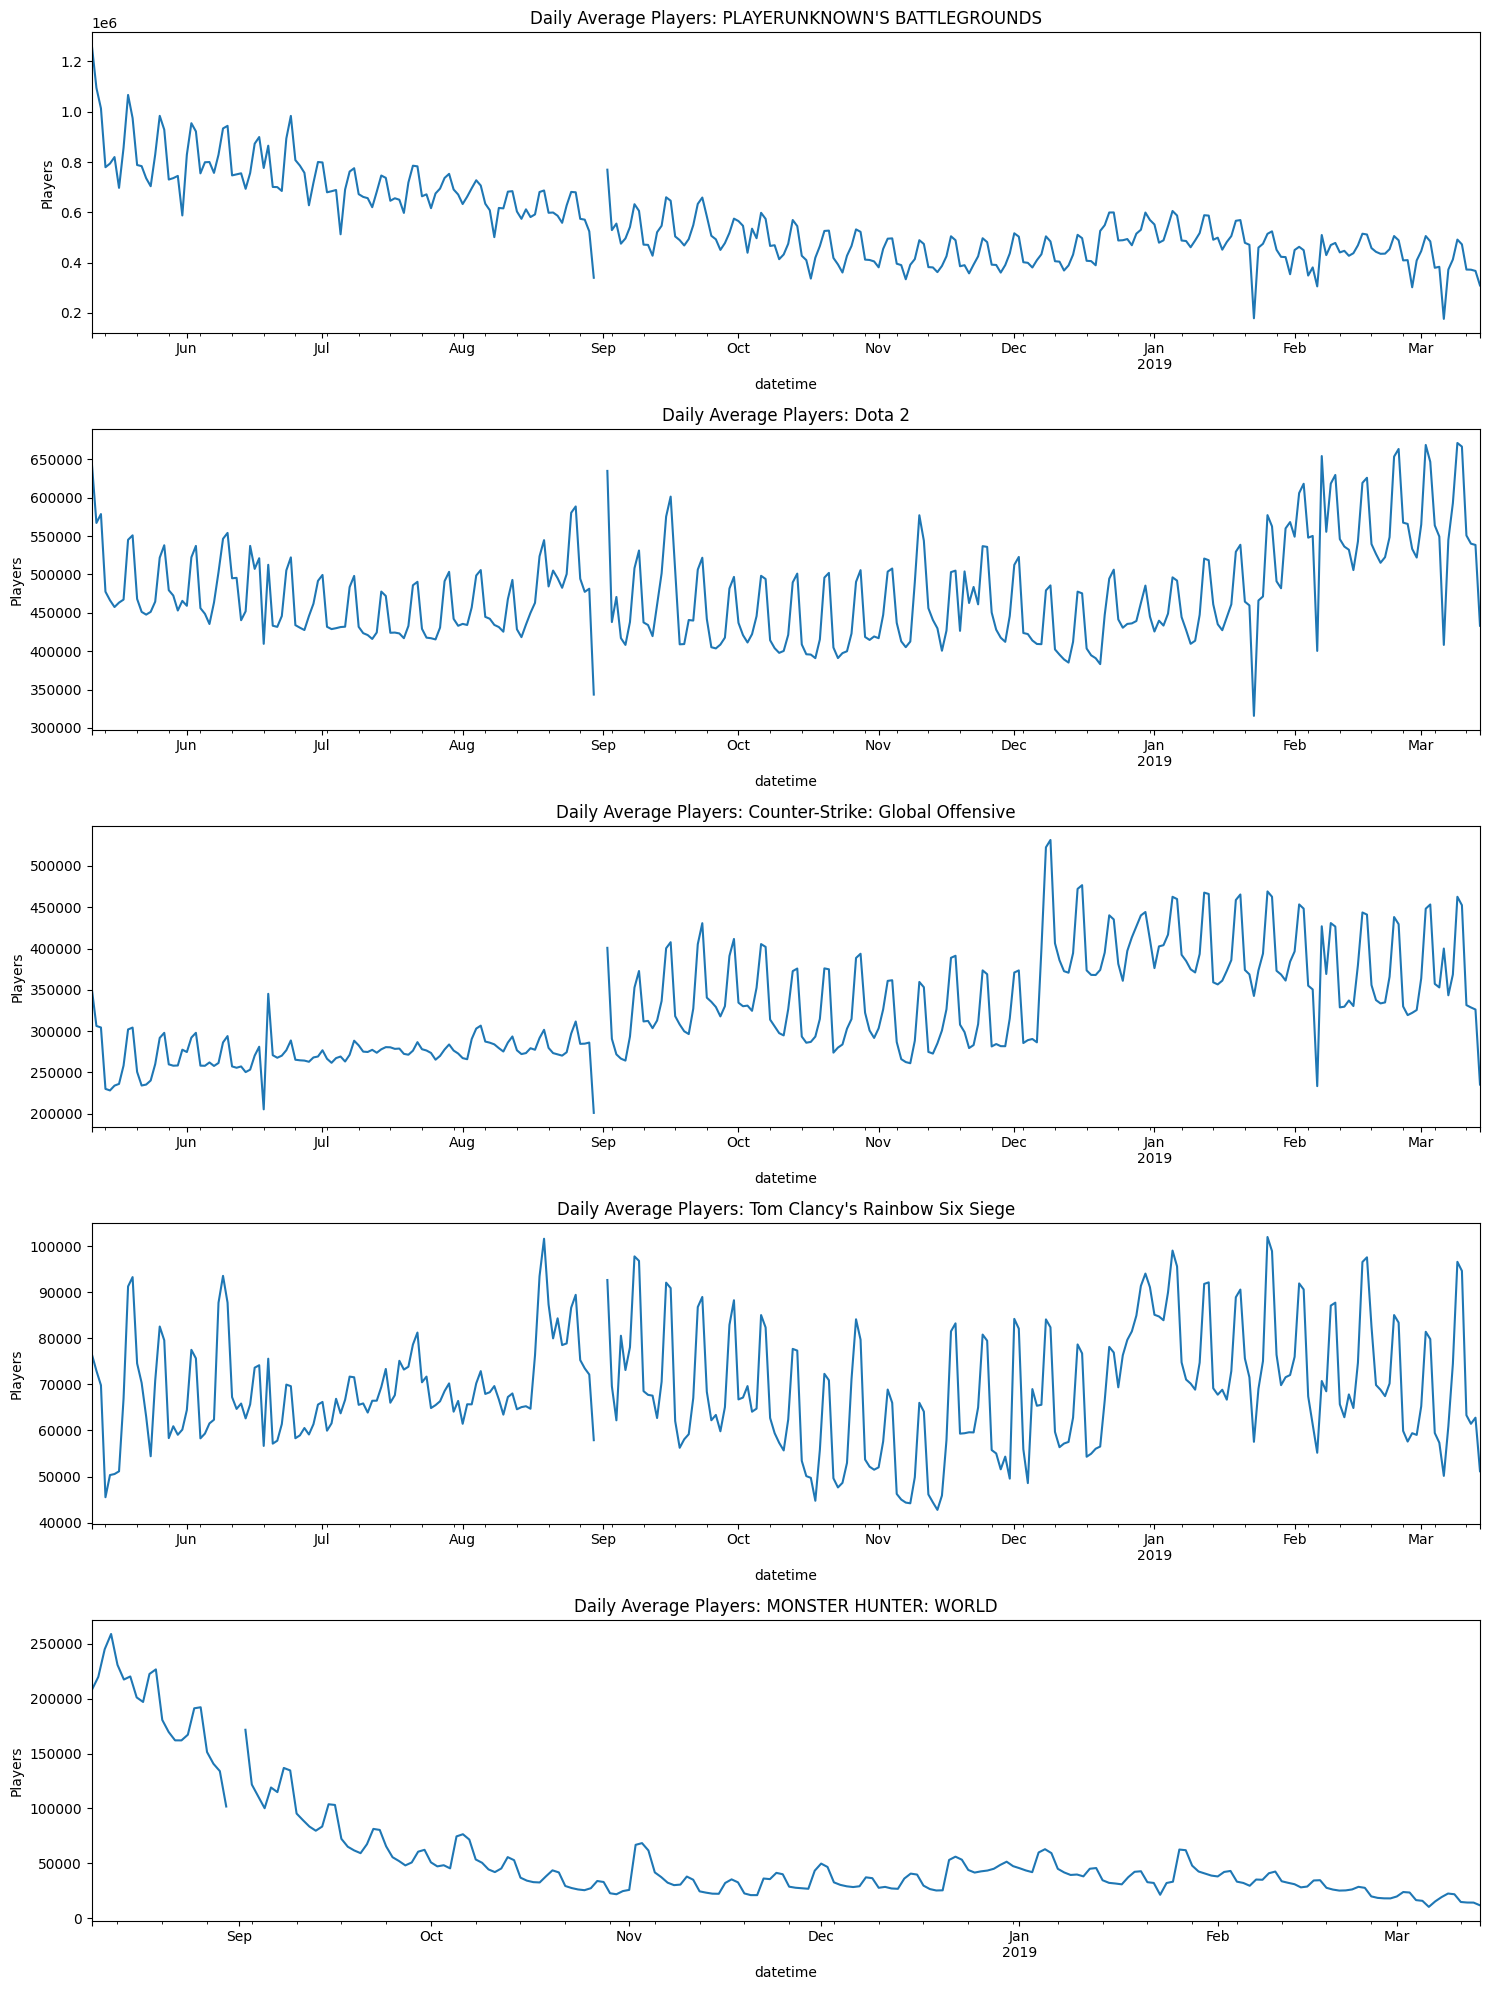

In [12]:
# Game-wise analysis
game_stats = df.groupby('title').agg({
    'current_players': ['mean', 'std', 'max', 'min'],
    'peak_players': 'max',
    'hours_played': 'sum'
}).round(0)

print("Top 10 games by average players:")
display(game_stats.nlargest(10, ('current_players', 'mean')))

# Visualize top games
top_5_games = game_stats.nlargest(5, ('current_players', 'mean')).index.get_level_values(0)

fig, axes = plt.subplots(5, 1, figsize=(15, 20))
for i, game in enumerate(top_5_games):
    game_data = df[df['title'] == game].resample('D')['current_players'].mean()
    game_data.plot(ax=axes[i])
    axes[i].set_title(f'Daily Average Players: {game}')
    axes[i].set_ylabel('Players')

plt.tight_layout()
plt.show()

## 10. Hourly Traffic Pattern Analysis


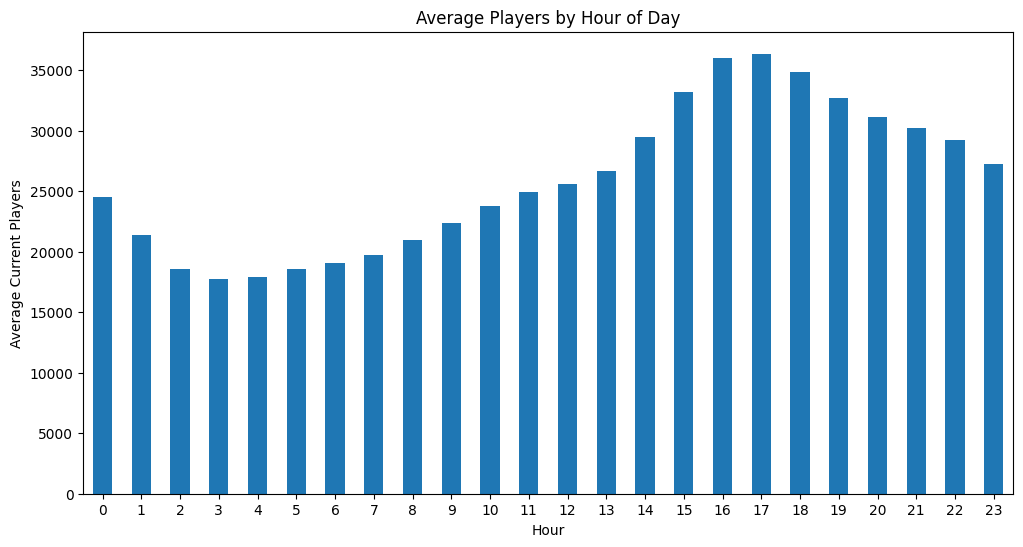

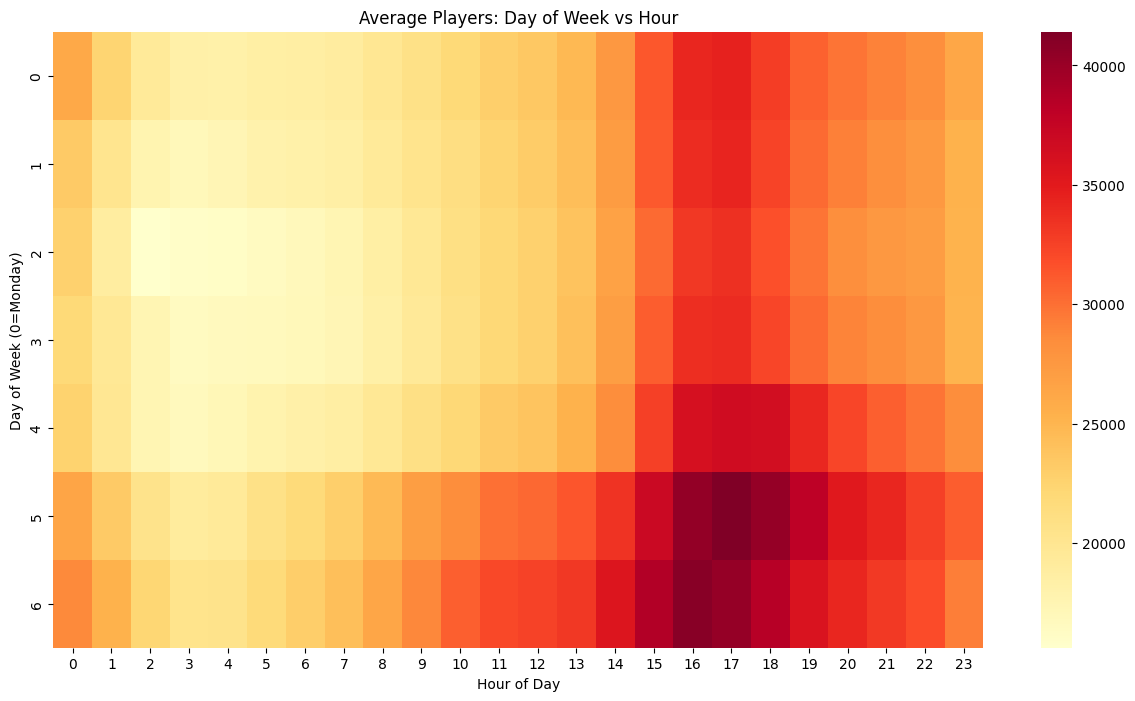

In [13]:
# Hourly patterns
hourly_avg = df.groupby(df.index.hour)['current_players'].mean()

plt.figure(figsize=(12, 6))
hourly_avg.plot(kind='bar')
plt.title('Average Players by Hour of Day')
plt.xlabel('Hour')
plt.ylabel('Average Current Players')
plt.xticks(rotation=0)
plt.show()

# Heatmap of hour vs day of week
df['day_of_week'] = df.index.dayofweek
hour_week = df.pivot_table(values='current_players', index='day_of_week', columns=df.index.hour, aggfunc='mean')

plt.figure(figsize=(15, 8))
sns.heatmap(hour_week, cmap='YlOrRd', annot=False)
plt.title('Average Players: Day of Week vs Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week (0=Monday)')
plt.show()

## 11. Peak-Hour Analysis 

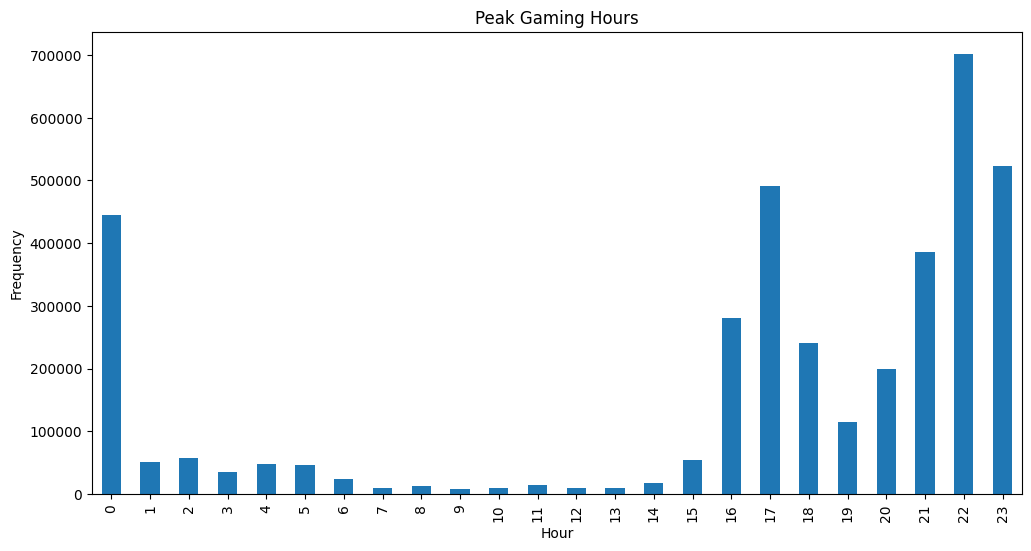

In [14]:
# peak hour distribution

peak_hours = (
    df.groupby([df.index.date, 'title'])['current_players']
    .idxmax()
)

peak_hour_times = df.loc[peak_hours, 'hour']

plt.figure(figsize=(12, 6))

peak_hour_times.value_counts().sort_index().plot(
    kind='bar'
)

plt.title('Peak Gaming Hours')

plt.xlabel('Hour')

plt.ylabel('Frequency')

plt.show()

## 12. Weekday vs Weekend Behavior
 

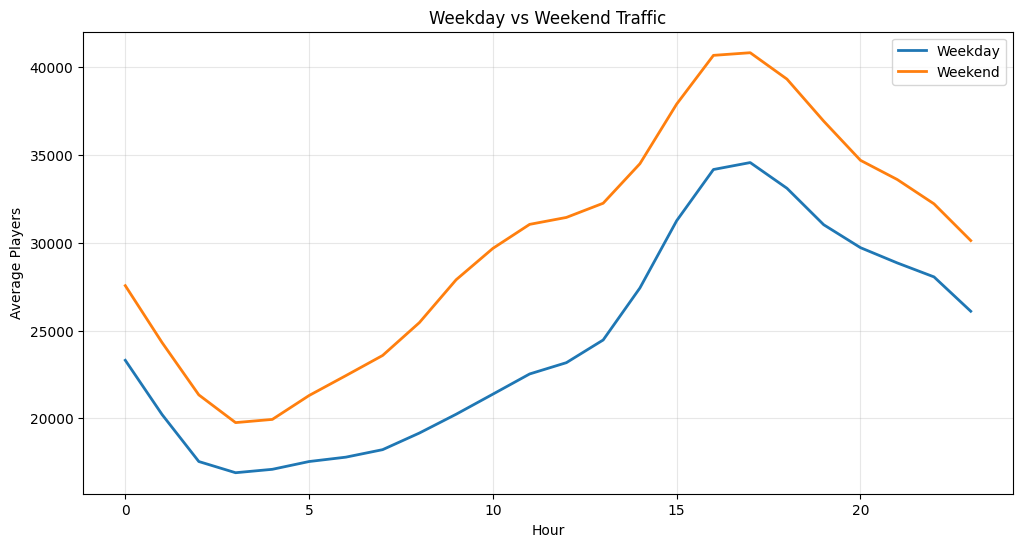

In [15]:
df['is_weekend'] = df.index.dayofweek >= 5

weekday_avg = (
    df[~df['is_weekend']]
    .groupby(df[~df['is_weekend']].index.hour)
    ['current_players']
    .mean()
)

weekend_avg = (
    df[df['is_weekend']]
    .groupby(df[df['is_weekend']].index.hour)
    ['current_players']
    .mean()
)

plt.figure(figsize=(12, 6))

weekday_avg.plot(
    label='Weekday',
    linewidth=2
)

weekend_avg.plot(
    label='Weekend',
    linewidth=2
)

plt.title('Weekday vs Weekend Traffic')

plt.xlabel('Hour')

plt.ylabel('Average Players')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

## 13. Correlation Analysis 

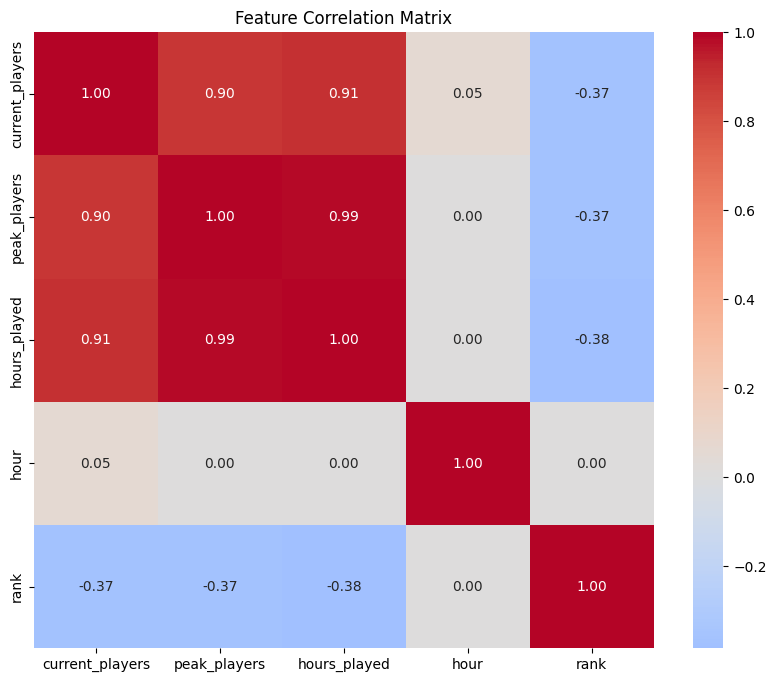

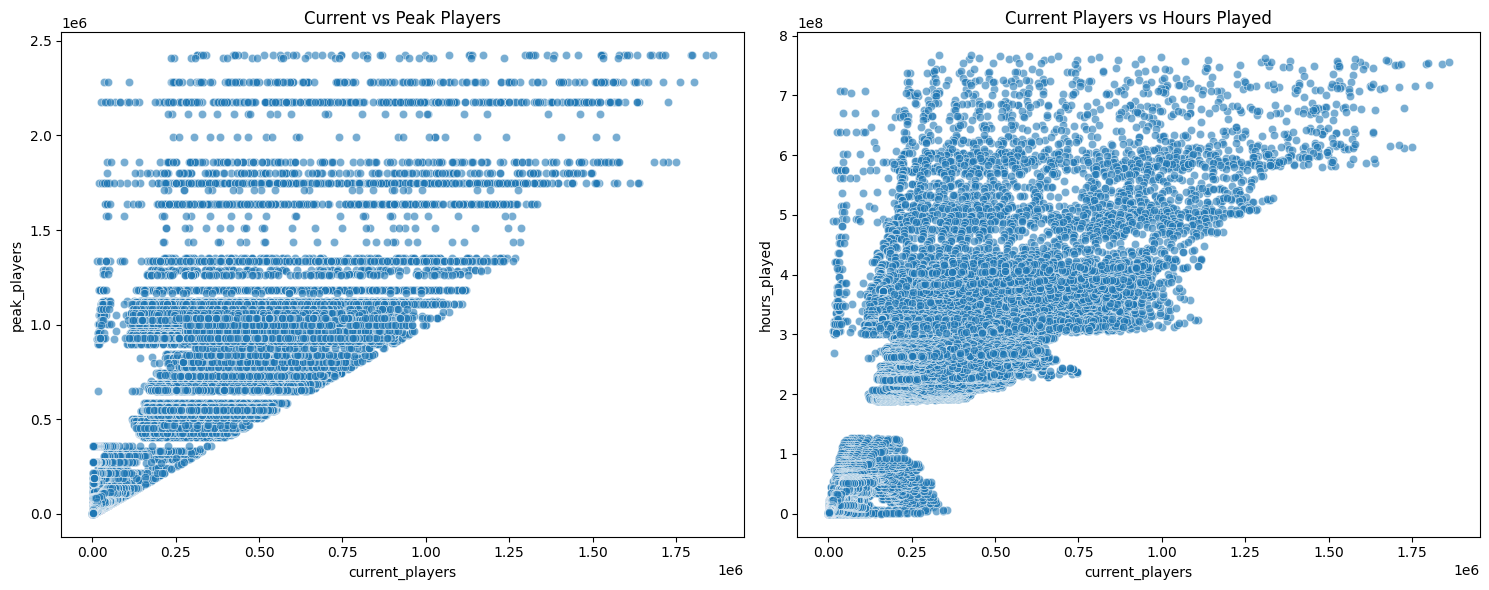

In [16]:
# Correlation analysis
correlation_matrix = df[['current_players', 'peak_players', 'hours_played', 'hour', 'rank']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

# Scatter plots for key relationships
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.scatterplot(data=df, x='current_players', y='peak_players', ax=axes[0], alpha=0.6)
axes[0].set_title('Current vs Peak Players')

sns.scatterplot(data=df, x='current_players', y='hours_played', ax=axes[1], alpha=0.6)
axes[1].set_title('Current Players vs Hours Played')

plt.tight_layout()
plt.show()

## 14. Trend and Seasonality Analysis
 

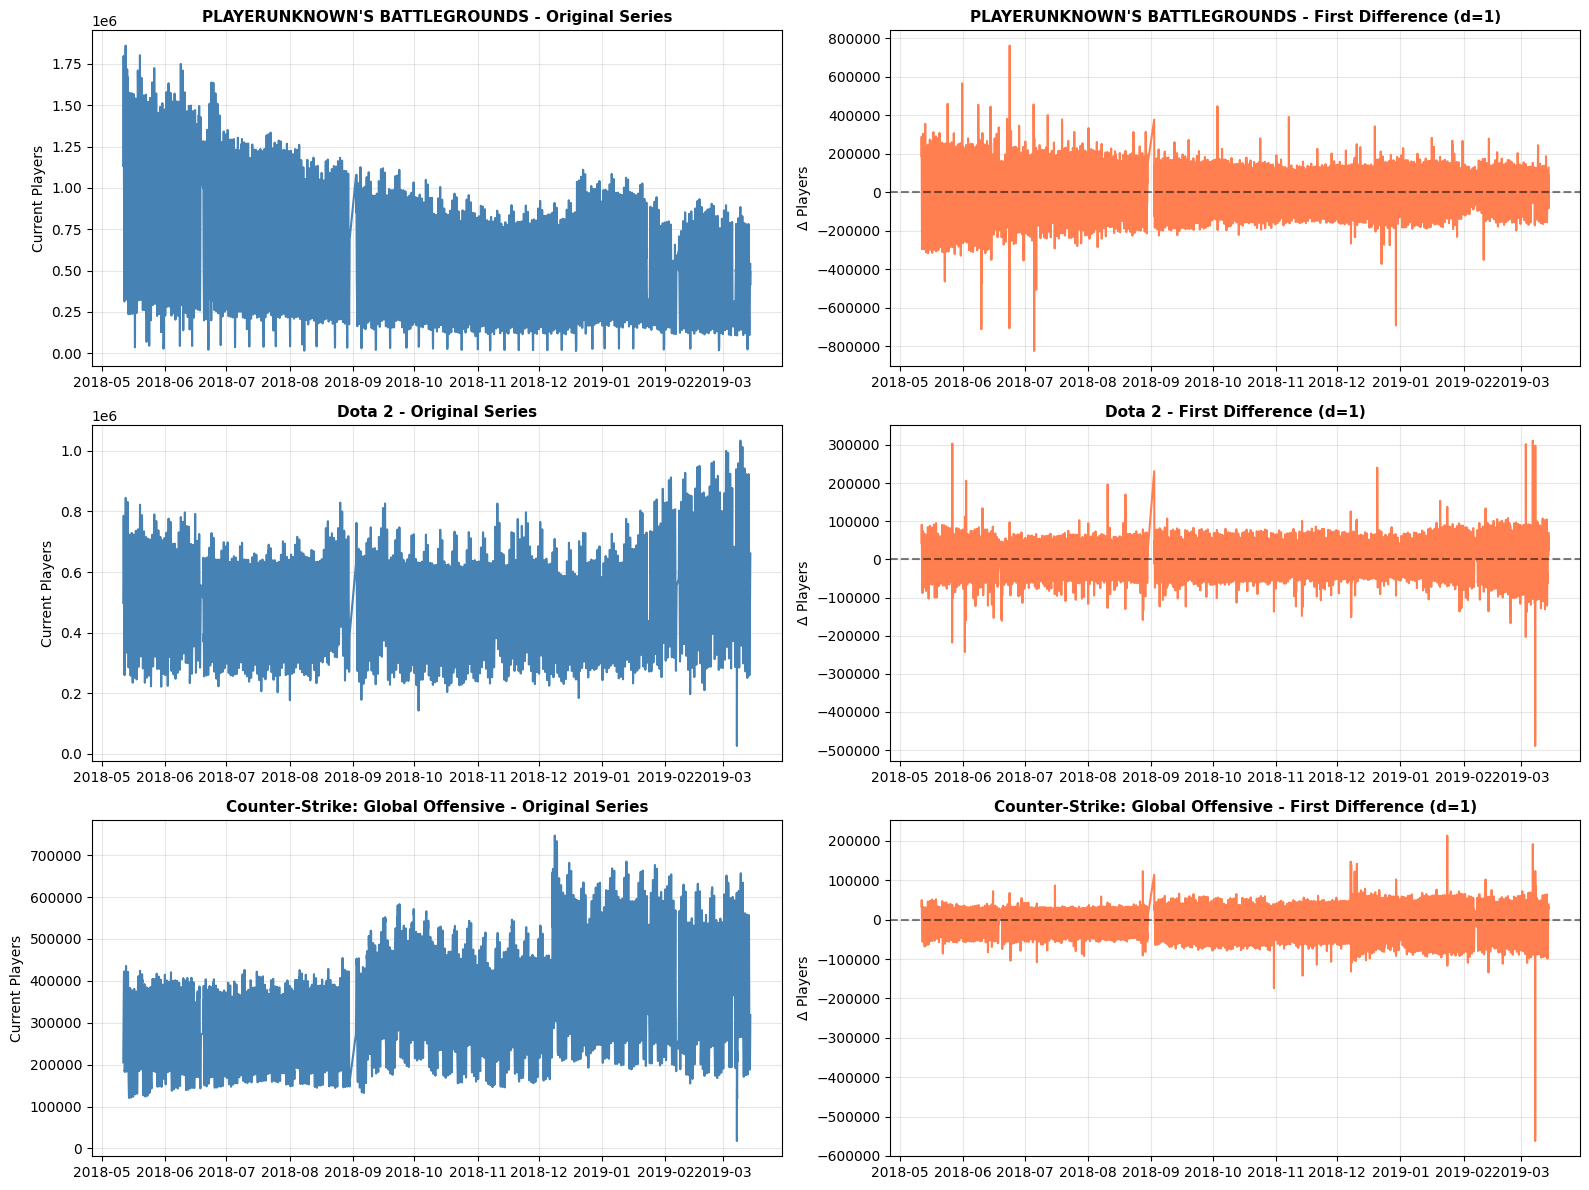


Observation: First differencing removes trends and makes series more stationary.


In [17]:
# Visualize stationarity: Original vs First Difference
fig, axes = plt.subplots(3, 2, figsize=(16, 12))

# Test on top 3 games
test_games_viz = game_stats.nlargest(3, ('current_players', 'mean')).index.get_level_values(0)

for idx, game in enumerate(test_games_viz):
    game_ts = df[df['title'] == game]['current_players'].dropna()
    game_diff = game_ts.diff().dropna()
    
    # Original series
    axes[idx, 0].plot(game_ts.index, game_ts.values, linewidth=1.5, color='steelblue')
    axes[idx, 0].set_title(f'{game} - Original Series', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Current Players')
    axes[idx, 0].grid(True, alpha=0.3)
    
    # First difference
    axes[idx, 1].plot(game_diff.index, game_diff.values, linewidth=1.5, color='coral')
    axes[idx, 1].set_title(f'{game} - First Difference (d=1)', fontsize=11, fontweight='bold')
    axes[idx, 1].set_ylabel('Δ Players')
    axes[idx, 1].grid(True, alpha=0.3)
    axes[idx, 1].axhline(y=0, color='black', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

print("\nObservation: First differencing removes trends and makes series more stationary.")

DIFFERENCING ANALYSIS


,Series,ADF Statistic,P-Value,Stationary
0,Original,-5.5494,0.000002,True
1,1st Difference,-17.7560,0.000000,True
2,Seasonal Diff (24h),-13.0157,0.000000,True


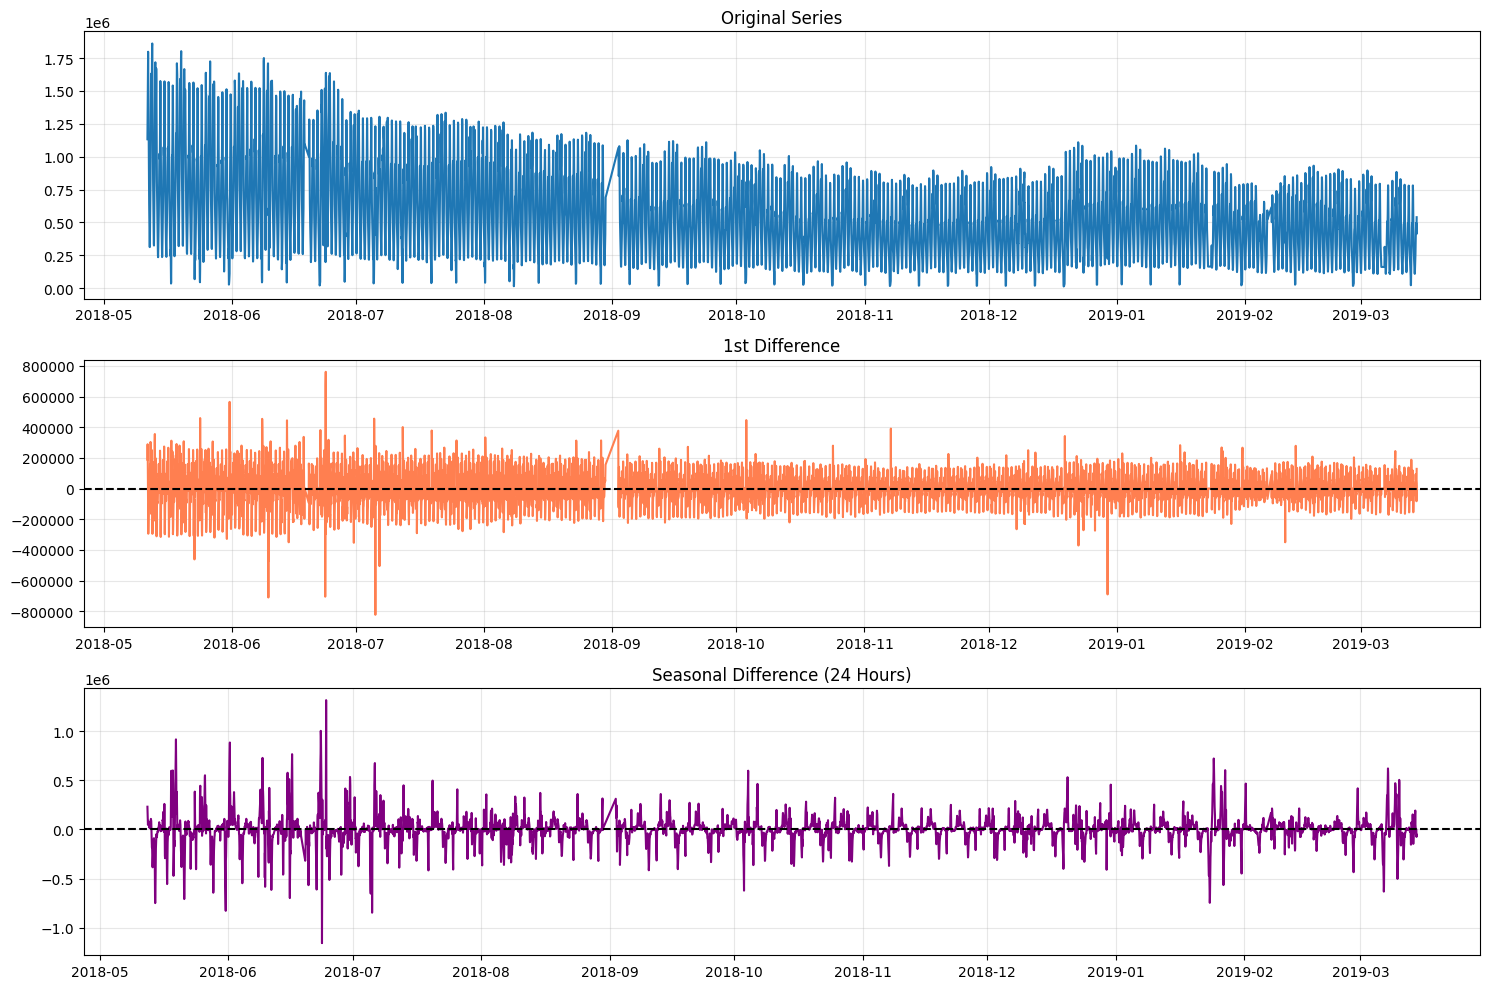

In [18]:
print("DIFFERENCING ANALYSIS")

game_for_diff = test_games_viz[0]

original_ts = (
    df[df['title'] == game_for_diff]
    ['current_players']
    .dropna()
)

# differencing
first_diff = original_ts.diff().dropna()

seasonal_diff = (
    original_ts
    .diff(periods=24)
    .dropna()
)

# ADF tests
series_dict = {
    'Original': original_ts,
    '1st Difference': first_diff,
    'Seasonal Diff (24h)': seasonal_diff
}

results = []

for name, series in series_dict.items():

    adf_result = adfuller(series)

    results.append({
        'Series': name,
        'ADF Statistic': round(adf_result[0], 4),
        'P-Value': round(adf_result[1], 6),
        'Stationary': adf_result[1] < 0.05
    })

results_df = pd.DataFrame(results)

display(results_df)

# visualization
fig, axes = plt.subplots(3, 1, figsize=(15, 10))

# original
axes[0].plot(
    original_ts.index,
    original_ts.values
)

axes[0].set_title('Original Series')

axes[0].grid(True, alpha=0.3)

# first difference
axes[1].plot(
    first_diff.index,
    first_diff.values,
    color='coral'
)

axes[1].axhline(
    y=0,
    color='black',
    linestyle='--'
)

axes[1].set_title('1st Difference')

axes[1].grid(True, alpha=0.3)

# seasonal difference
axes[2].plot(
    seasonal_diff.index,
    seasonal_diff.values,
    color='purple'
)

axes[2].axhline(
    y=0,
    color='black',
    linestyle='--'
)

axes[2].set_title('Seasonal Difference (24 Hours)')

axes[2].grid(True, alpha=0.3)

plt.tight_layout()

plt.show()

In [19]:
from statsmodels.tsa.stattools import adfuller

print("ADF STATIONARITY TEST")

print("\nH0 : Non-stationary")
print("H1 : Stationary\n")

adf_results = []

test_games = (
    game_stats
    .nlargest(10, ('current_players', 'mean'))
    .index
    .get_level_values(0)
)

for game in test_games:

    game_ts = (
        df[df['title'] == game]
        ['current_players']
        .dropna()
    )

    # original series
    result_original = adfuller(
        game_ts,
        autolag='AIC'
    )

    p_original = result_original[1]

    # first differencing if needed
    if p_original >= 0.05:

        diff_ts = game_ts.diff().dropna()

        result_diff = adfuller(
            diff_ts,
            autolag='AIC'
        )

        final_p = result_diff[1]

        method = "1st Difference"

    else:

        final_p = p_original

        method = "Original"

    adf_results.append({

        'Game': game,

        'Original P-Value': round(p_original, 6),

        'Final P-Value': round(final_p, 6),

        'Method': method,

        'Stationary': (
            'Yes'
            if final_p < 0.05
            else 'No'
        )
    })

    print(f"\n{game}")

    print(
        f"Original P-Value : "
        f"{p_original:.6f}"
    )

    print(
        f"Method Used : "
        f"{method}"
    )

    print(
        f"Final P-Value : "
        f"{final_p:.6f}"
    )

    print(
        f"Stationary : "
        f"{'Yes' if final_p < 0.05 else 'No'}"
    )

adf_df = pd.DataFrame(adf_results)

print("\nADF Summary")

display(adf_df)

ADF STATIONARITY TEST

H0 : Non-stationary
H1 : Stationary


PLAYERUNKNOWN'S BATTLEGROUNDS
Original P-Value : 0.000002
Method Used : Original
Final P-Value : 0.000002
Stationary : Yes

Dota 2
Original P-Value : 0.000000
Method Used : Original
Final P-Value : 0.000000
Stationary : Yes

Counter-Strike: Global Offensive
Original P-Value : 0.000000
Method Used : Original
Final P-Value : 0.000000
Stationary : Yes

Tom Clancy's Rainbow Six Siege
Original P-Value : 0.000000
Method Used : Original
Final P-Value : 0.000000
Stationary : Yes

MONSTER HUNTER: WORLD
Original P-Value : 0.011416
Method Used : Original
Final P-Value : 0.011416
Stationary : Yes

Warframe
Original P-Value : 0.000000
Method Used : Original
Final P-Value : 0.000000
Stationary : Yes

Grand Theft Auto V
Original P-Value : 0.000000
Method Used : Original
Final P-Value : 0.000000
Stationary : Yes

Hyperdrive Massacre
Original P-Value : 0.219105
Method Used : 1st Difference
Final P-Value : 0.008439
Stationary : Yes

Team Fortr

,Game,Original P-Value,Final P-Value,Method,Stationary
0,PLAYERUNKNOWN'S BATTLEGROUNDS,0.000002,0.000002,Original,Yes
1,Dota 2,0.000000,0.000000,Original,Yes
2,Counter-Strike: Global Offensive,0.000000,0.000000,Original,Yes
3,Tom Clancy's Rainbow Six Siege,0.000000,0.000000,Original,Yes
4,MONSTER HUNTER: WORLD,0.011416,0.011416,Original,Yes
5,Warframe,0.000000,0.000000,Original,Yes
6,Grand Theft Auto V,0.000000,0.000000,Original,Yes
7,Hyperdrive Massacre,0.219105,0.008439,1st Difference,Yes
8,Team Fortress 2,0.000000,0.000000,Original,Yes
9,Braveland,0.005138,0.005138,Original,Yes


In [20]:
from statsmodels.tsa.stattools import kpss

print("KPSS STATIONARITY TEST")

print("\nH0 : Stationary")
print("H1 : Non-stationary\n")

kpss_results = []

for game in test_games:

    game_ts = (
        df[df['title'] == game]
        ['current_players']
        .dropna()
    )

    # original series
    result_original = kpss(
        game_ts,
        regression='c',
        nlags='auto'
    )

    p_original = result_original[1]

    # differencing if needed
    if p_original < 0.05:

        diff_ts = game_ts.diff().dropna()

        result_diff = kpss(
            diff_ts,
            regression='c',
            nlags='auto'
        )

        final_p = result_diff[1]

        method = "1st Difference"

    else:

        final_p = p_original

        method = "Original"

    kpss_results.append({

        'Game': game,

        'Original P-Value': round(
            p_original,
            6
        ),

        'Final P-Value': round(
            final_p,
            6
        ),

        'Method': method,

        'Stationary': (
            'Yes'
            if final_p > 0.05
            else 'No'
        )
    })

    print(f"\n{game}")

    print(
        f"Original P-Value : "
        f"{p_original:.6f}"
    )

    print(
        f"Method Used : "
        f"{method}"
    )

    print(
        f"Final P-Value : "
        f"{final_p:.6f}"
    )

    print(
        f"Stationary : "
        f"{'Yes' if final_p > 0.05 else 'No'}"
    )

kpss_df = pd.DataFrame(kpss_results)

print("\nKPSS Summary")

display(kpss_df)

KPSS STATIONARITY TEST

H0 : Stationary
H1 : Non-stationary


PLAYERUNKNOWN'S BATTLEGROUNDS
Original P-Value : 0.010000
Method Used : 1st Difference
Final P-Value : 0.100000
Stationary : Yes

Dota 2
Original P-Value : 0.010000
Method Used : 1st Difference
Final P-Value : 0.100000
Stationary : Yes

Counter-Strike: Global Offensive
Original P-Value : 0.010000
Method Used : 1st Difference
Final P-Value : 0.100000
Stationary : Yes

Tom Clancy's Rainbow Six Siege
Original P-Value : 0.020472
Method Used : 1st Difference
Final P-Value : 0.100000
Stationary : Yes

MONSTER HUNTER: WORLD
Original P-Value : 0.010000
Method Used : 1st Difference
Final P-Value : 0.100000
Stationary : Yes

Warframe
Original P-Value : 0.010000
Method Used : 1st Difference
Final P-Value : 0.100000
Stationary : Yes

Grand Theft Auto V
Original P-Value : 0.010000
Method Used : 1st Difference
Final P-Value : 0.100000
Stationary : Yes

Hyperdrive Massacre
Original P-Value : 0.023602
Method Used : 1st Difference
Final P-Va

,Game,Original P-Value,Final P-Value,Method,Stationary
0,PLAYERUNKNOWN'S BATTLEGROUNDS,0.010000,0.100000,1st Difference,Yes
1,Dota 2,0.010000,0.100000,1st Difference,Yes
2,Counter-Strike: Global Offensive,0.010000,0.100000,1st Difference,Yes
3,Tom Clancy's Rainbow Six Siege,0.020472,0.100000,1st Difference,Yes
4,MONSTER HUNTER: WORLD,0.010000,0.100000,1st Difference,Yes
5,Warframe,0.010000,0.100000,1st Difference,Yes
6,Grand Theft Auto V,0.010000,0.100000,1st Difference,Yes
7,Hyperdrive Massacre,0.023602,0.100000,1st Difference,Yes
8,Team Fortress 2,0.010000,0.100000,1st Difference,Yes
9,Braveland,0.050389,0.050389,Original,Yes


15.TIME SERIES DECOMPOSITION 

TIME SERIES DECOMPOSITION ANALYSIS


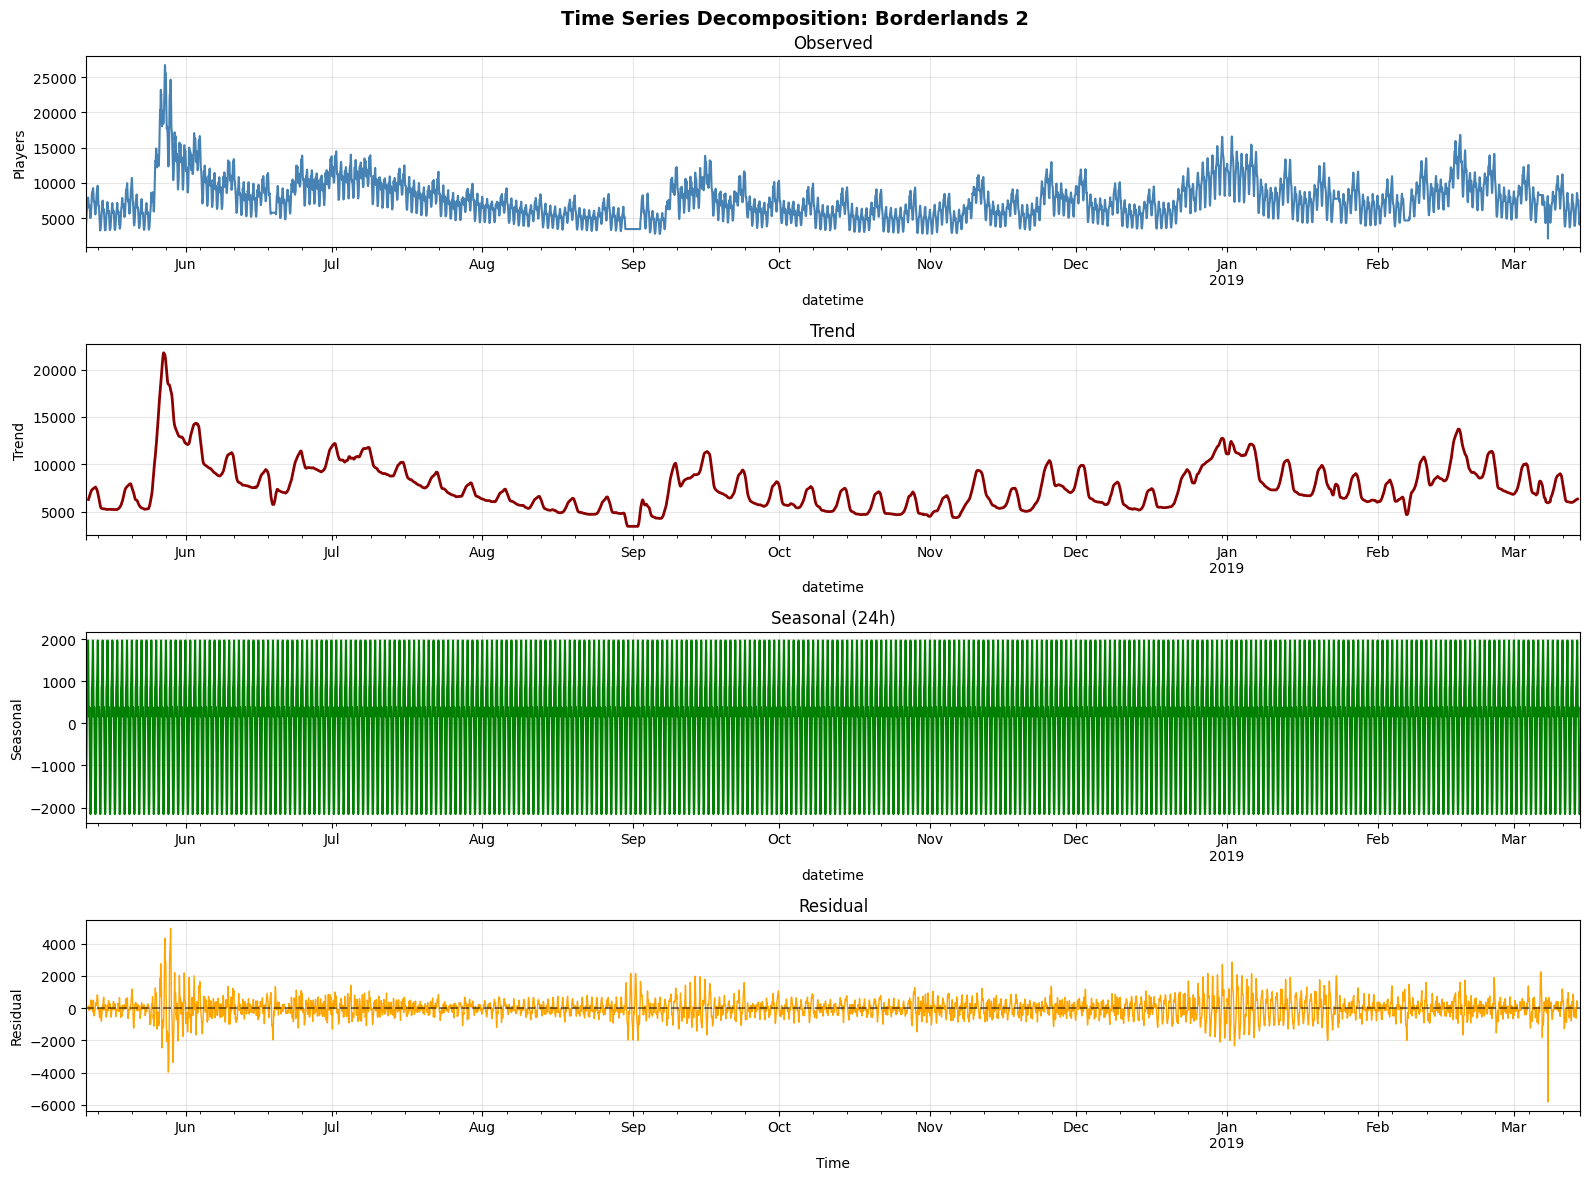


COMPONENT STATISTICS

Observed Mean : 7636
Observed Std : 2853

Trend Std : 2446

Seasonal Std : 1264
Seasonal Strength : 81.30%

Residual Std : 606


In [21]:
print("TIME SERIES DECOMPOSITION ANALYSIS")

top_game_data_hourly = (
    df[df['title'] == top_game]
    ['current_players']
    .resample('H')
    .mean()
)

top_game_data_hourly = (
    top_game_data_hourly
    .ffill()
    .bfill()
)

min_length = 24 * 8

if len(top_game_data_hourly) >= min_length:

    decomposition = seasonal_decompose(
        top_game_data_hourly,
        model='additive',
        period=24
    )

    fig, axes = plt.subplots(
        4,
        1,
        figsize=(16, 12)
    )

    decomposition.observed.plot(
        ax=axes[0],
        color='steelblue',
        linewidth=1.5,
        title='Observed'
    )

    axes[0].set_ylabel('Players')

    axes[0].grid(True, alpha=0.3)

    decomposition.trend.plot(
        ax=axes[1],
        color='darkred',
        linewidth=2,
        title='Trend'
    )

    axes[1].set_ylabel('Trend')

    axes[1].grid(True, alpha=0.3)

    decomposition.seasonal.plot(
        ax=axes[2],
        color='green',
        linewidth=1.5,
        title='Seasonal (24h)'
    )

    axes[2].set_ylabel('Seasonal')

    axes[2].grid(True, alpha=0.3)

    decomposition.resid.plot(
        ax=axes[3],
        color='orange',
        linewidth=1,
        title='Residual'
    )

    axes[3].set_ylabel('Residual')

    axes[3].set_xlabel('Time')

    axes[3].grid(True, alpha=0.3)

    axes[3].axhline(
        y=0,
        color='black',
        linestyle='--',
        alpha=0.5
    )

    plt.suptitle(
        f'Time Series Decomposition: {top_game}',
        fontsize=14,
        fontweight='bold'
    )

    plt.tight_layout()

    plt.show()

    print("\nCOMPONENT STATISTICS")

    print(f"\nObserved Mean : {decomposition.observed.mean():.0f}")

    print(f"Observed Std : {decomposition.observed.std():.0f}")

    print(f"\nTrend Std : {decomposition.trend.std():.0f}")

    print(f"\nSeasonal Std : {decomposition.seasonal.std():.0f}")

    seasonal_strength = (
        1 -
        (
            decomposition.resid.var()
            /
            (decomposition.seasonal + decomposition.resid).var()
        )
    )

    print(
        f"Seasonal Strength : "
        f"{seasonal_strength:.2%}"
    )

    print(f"\nResidual Std : {decomposition.resid.std():.0f}")

else:

    print(
        f"Insufficient data "
        f"(need {min_length}, "
        f"have {len(top_game_data_hourly)})"
    )

VOLATILITY ANALYSIS - TIME-VARYING VARIANCE


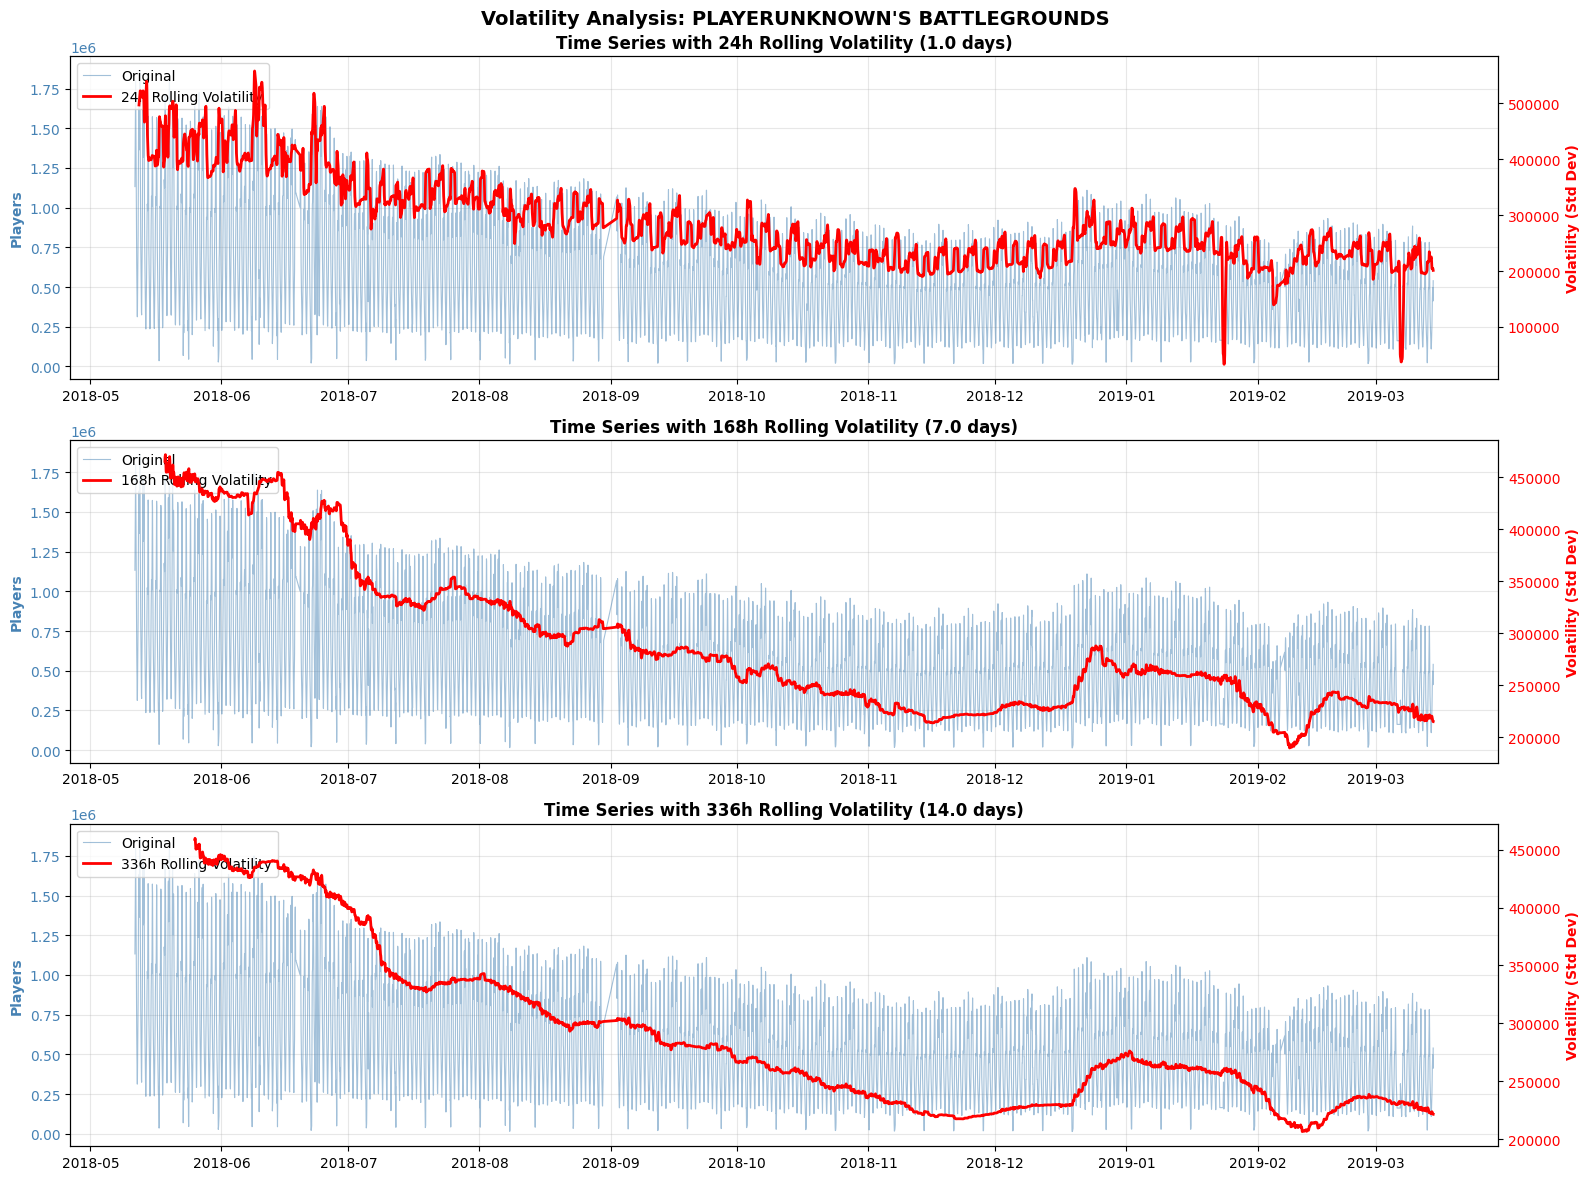


PLAYERUNKNOWN'S BATTLEGROUNDS - Volatility Statistics:

24h Window:
  Mean Volatility: 285823 players
  Min Volatility: 33172 players
  Max Volatility: 557706 players
  Volatility of Volatility: 76817 (heteroscedasticity indicator)

168h Window:
  Mean Volatility: 288438 players
  Min Volatility: 189534 players
  Max Volatility: 471858 players
  Volatility of Volatility: 69835 (heteroscedasticity indicator)

336h Window:
  Mean Volatility: 287467 players
  Min Volatility: 206472 players
  Max Volatility: 459814 players
  Volatility of Volatility: 67221 (heteroscedasticity indicator)



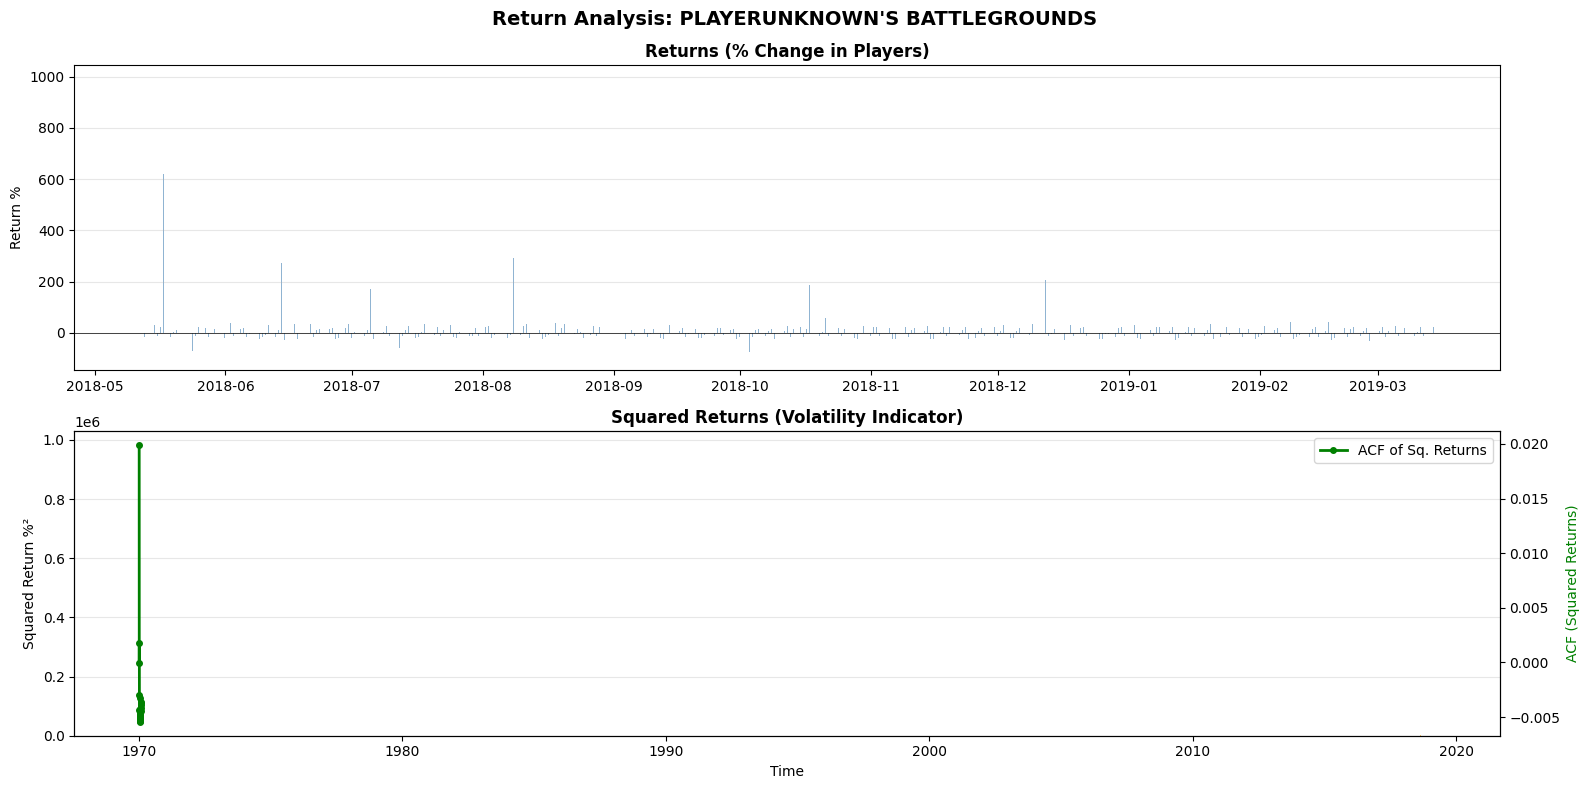


VOLATILITY CLUSTERING & GARCH INDICATORS:
ACF of Squared Returns: [np.float64(0.01991693779734026), np.float64(-1.0695952841672587e-05), np.float64(0.001775334747936156), np.float64(-0.0030130967946093187), np.float64(-0.0043536646818895484)]

Interpretation:
  • High ACF values (> 0.3) at lags 1-5 → Volatility clustering exists
  • Use GARCH(1,1) model to capture this behavior
  • Benefits: Better confidence intervals for forecasts
  • Without GARCH: Confidence intervals too narrow during volatile periods



In [22]:
# Volatility and variance analysis
 
print("VOLATILITY ANALYSIS - TIME-VARYING VARIANCE")
 

game_for_vol = test_games[0]
vol_series = df[df['title'] == game_for_vol]['current_players'].dropna()

# Calculate rolling volatility (std dev) with multiple windows
windows = [24, 168, 336]  # 1 day, 1 week, 2 weeks
volatility_dict = {}

fig, axes = plt.subplots(3, 1, figsize=(16, 12))

for idx, window in enumerate(windows):
    rolling_vol = vol_series.rolling(window=window, center=False).std()
    volatility_dict[f'{window}h'] = rolling_vol
    
    axes[idx].plot(vol_series.index, vol_series.values, alpha=0.5, linewidth=0.8, label='Original', color='steelblue')
    ax2 = axes[idx].twinx()
    ax2.plot(rolling_vol.index, rolling_vol.values, linewidth=2, label=f'{window}h Rolling Volatility', color='red')
    
    axes[idx].set_title(f'Time Series with {window}h Rolling Volatility ({window//24:.1f} days)', fontweight='bold', fontsize=12)
    axes[idx].set_ylabel('Players', fontweight='bold', color='steelblue')
    ax2.set_ylabel('Volatility (Std Dev)', fontweight='bold', color='red')
    axes[idx].grid(True, alpha=0.3)
    axes[idx].tick_params(axis='y', labelcolor='steelblue')
    ax2.tick_params(axis='y', labelcolor='red')
    
    # Add legend
    lines1, labels1 = axes[idx].get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    axes[idx].legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.suptitle(f'Volatility Analysis: {game_for_vol}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Volatility statistics
print(f"\n{game_for_vol} - Volatility Statistics:\n")
for window, vol_series_data in volatility_dict.items():
    vol_clean = vol_series_data.dropna()
    print(f"{window} Window:")
    print(f"  Mean Volatility: {vol_clean.mean():.0f} players")
    print(f"  Min Volatility: {vol_clean.min():.0f} players")
    print(f"  Max Volatility: {vol_clean.max():.0f} players")
    print(f"  Volatility of Volatility: {vol_clean.std():.0f} (heteroscedasticity indicator)")
    print()

# Squared returns (GARCH-related)
returns = vol_series.pct_change().dropna() * 100  # Percentage returns
squared_returns = returns ** 2

fig, axes = plt.subplots(2, 1, figsize=(16, 8))

axes[0].bar(returns.index, returns.values, width=0.01, color='steelblue', alpha=0.6)
axes[0].set_title('Returns (% Change in Players)', fontweight='bold', fontsize=12)
axes[0].set_ylabel('Return %')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].axhline(y=0, color='black', linewidth=0.5)

axes[1].bar(squared_returns.index, squared_returns.values, width=0.01, color='orange', alpha=0.6)
axes[1].set_title('Squared Returns (Volatility Indicator)', fontweight='bold', fontsize=12)
axes[1].set_ylabel('Squared Return %²')
axes[1].set_xlabel('Time')
axes[1].grid(True, alpha=0.3, axis='y')

# Autocorrelation of squared returns (GARCH evidence)
acf_sq_ret = [squared_returns.corr(squared_returns.shift(i)) for i in range(1, 25)]
ax_acf = axes[1].twinx()
ax_acf.plot(range(1, 25), acf_sq_ret, 'g-o', linewidth=2, markersize=4, label='ACF of Sq. Returns')
ax_acf.set_ylabel('ACF (Squared Returns)', color='green')
ax_acf.legend(loc='upper right')

plt.suptitle(f'Return Analysis: {game_for_vol}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Volatility clustering detection
print("\n" + "="*80)
print("VOLATILITY CLUSTERING & GARCH INDICATORS:")
print("="*80)
print(f"ACF of Squared Returns: {acf_sq_ret[:5]}")
print("""
Interpretation:
  • High ACF values (> 0.3) at lags 1-5 → Volatility clustering exists
  • Use GARCH(1,1) model to capture this behavior
  • Benefits: Better confidence intervals for forecasts
  • Without GARCH: Confidence intervals too narrow during volatile periods
""")

## 15. Rolling Averages and Statistics


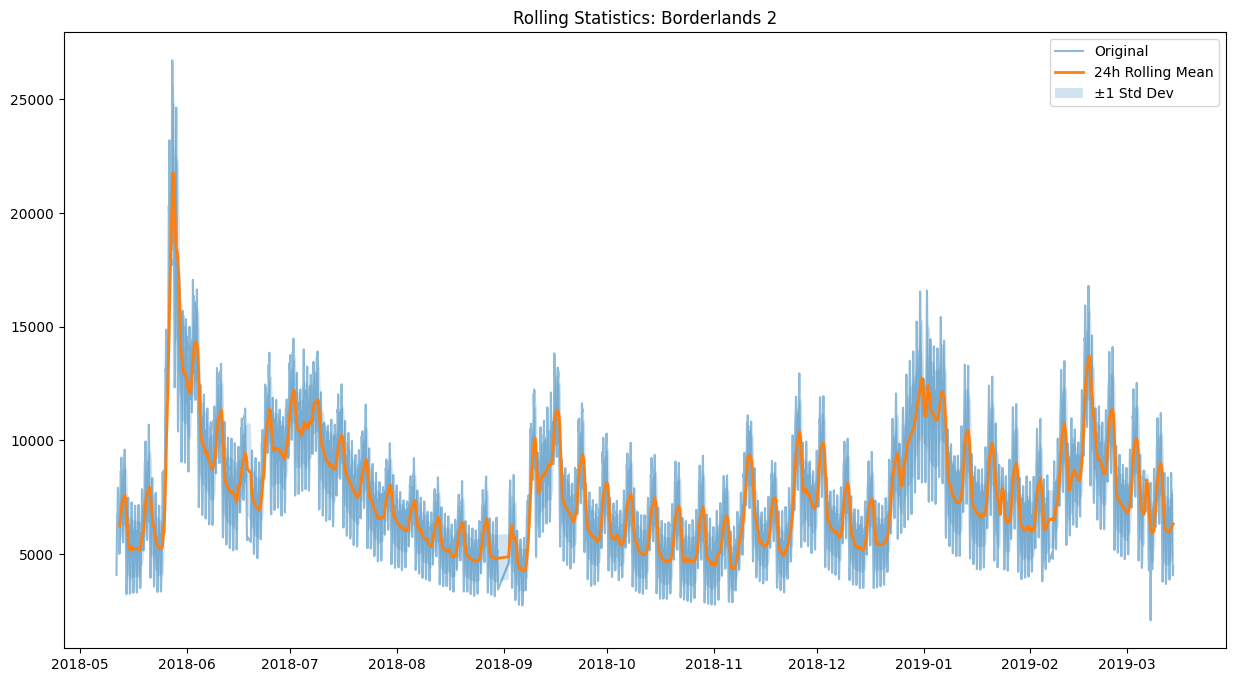

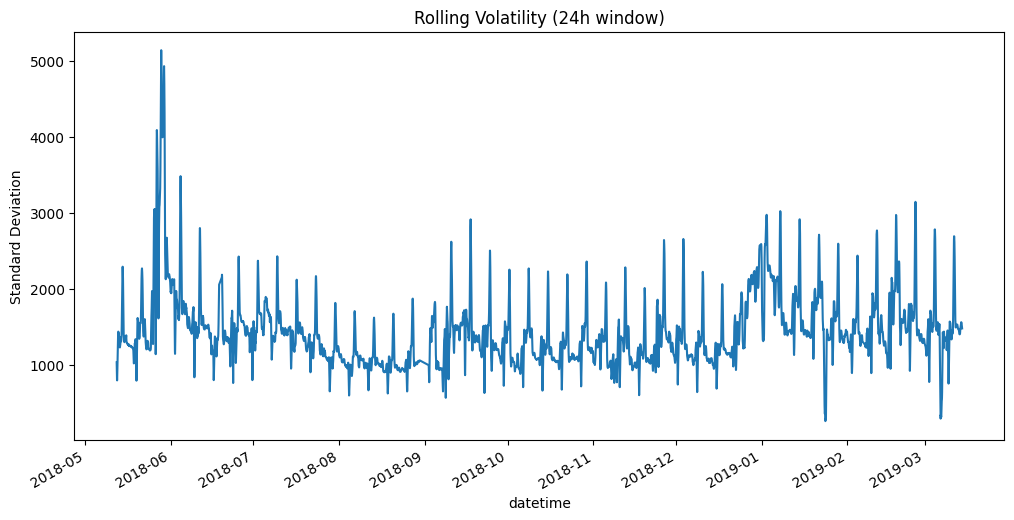

In [23]:
# Rolling statistics
top_game_data = df[df['title'] == top_game]['current_players']

rolling_mean = top_game_data.rolling(window=24).mean()  # 24-hour rolling mean
rolling_std = top_game_data.rolling(window=24).std()

plt.figure(figsize=(15, 8))
plt.plot(top_game_data.index, top_game_data, alpha=0.5, label='Original')
plt.plot(rolling_mean.index, rolling_mean, label='24h Rolling Mean', linewidth=2)
plt.fill_between(rolling_std.index, rolling_mean - rolling_std, rolling_mean + rolling_std, alpha=0.2, label='±1 Std Dev')
plt.title(f'Rolling Statistics: {top_game}')
plt.legend()
plt.show()

# Rolling volatility
rolling_volatility = top_game_data.rolling(window=24).std()
plt.figure(figsize=(12, 6))
rolling_volatility.plot()
plt.title('Rolling Volatility (24h window)')
plt.ylabel('Standard Deviation')
plt.show()

## 16. Lag Relationship Analysis
 

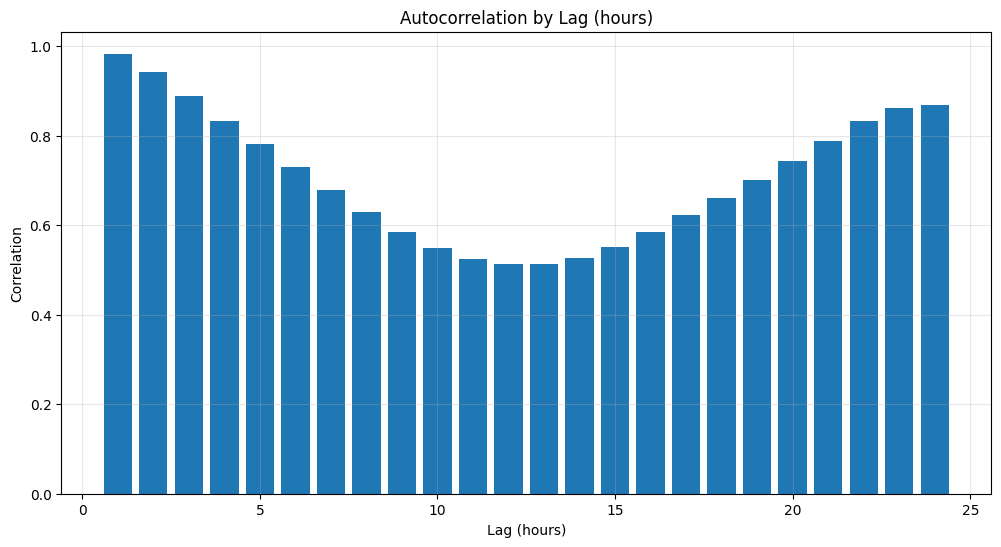

Correlation between hour and average players: 0.798


In [24]:
# Lag analysis
lags = range(1, 25)  # 1 to 24 hours
autocorr = [top_game_data.corr(top_game_data.shift(lag)) for lag in lags]

plt.figure(figsize=(12, 6))
plt.bar(lags, autocorr)
plt.title('Autocorrelation by Lag (hours)')
plt.xlabel('Lag (hours)')
plt.ylabel('Correlation')
plt.grid(True, alpha=0.3)
plt.show()

# Cross-correlation with hour of day
hour_corr = df.groupby(df.index.hour)['current_players'].mean().corr(pd.Series(range(24)))
print(f"Correlation between hour and average players: {hour_corr:.3f}")

## 17. Autocorrelation and Partial Autocorrelation
 

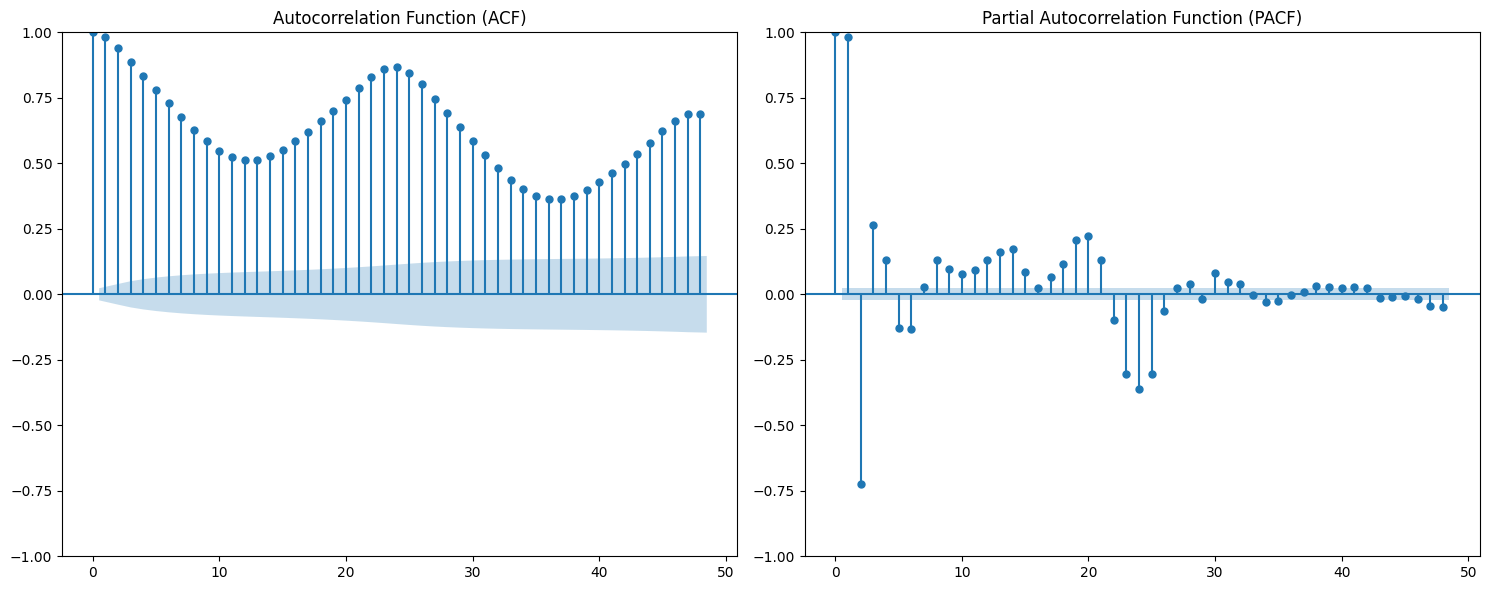

In [25]:
# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

plot_acf(top_game_data.dropna(), lags=48, ax=axes[0])
axes[0].set_title('Autocorrelation Function (ACF)')

plot_pacf(top_game_data.dropna(), lags=48, ax=axes[1])
axes[1].set_title('Partial Autocorrelation Function (PACF)')

plt.tight_layout()
plt.show()

## 18. Detecting Traffic Spikes and Abnormal Events
 

Spikes Detected : 74


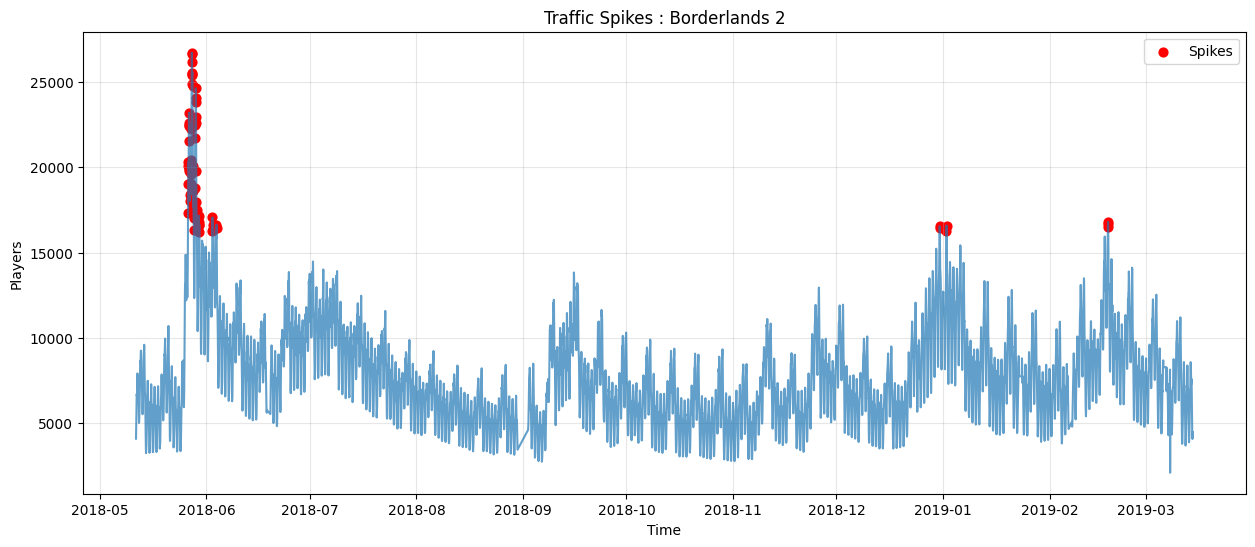

In [26]:
# spike detection using z-score

def detect_spikes(series, threshold=3):

    z_scores = (
        series - series.mean()
    ) / series.std()

    return abs(z_scores) > threshold

spikes = detect_spikes(top_game_data)

print(
    f"Spikes Detected : "
    f"{spikes.sum()}"
)

# spike visualization
plt.figure(figsize=(15, 6))

plt.plot(
    top_game_data.index,
    top_game_data.values,
    alpha=0.7
)

plt.scatter(
    top_game_data[spikes].index,
    top_game_data[spikes].values,
    color='red',
    s=40,
    label='Spikes'
)

plt.title(f'Traffic Spikes : {top_game}')

plt.xlabel('Time')

plt.ylabel('Players')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

## 20. Data Leakage Checks
 

In [27]:
# Data leakage checks
# Check if peak_players is always >= current_players
leakage_check = (df['peak_players'] >= df['current_players']).all()
print(f"Peak players always >= current players: {leakage_check}")

# Check for temporal leakage in rolling features (simulated)
# This would be a problem if we used future rolling stats
future_leakage = df['current_players'].rolling(window=24, center=True).mean()  # Center would leak future
print("Rolling mean with center=True would cause leakage - avoid in production!")

# Correlation between rank and players (potential leakage if rank is computed from current data)
rank_corr = df.groupby(df.index.date)['rank'].corr(df['current_players'])
print(f"Average daily correlation between rank and players: {rank_corr.mean():.3f}")
print("If rank is computed from current players, it may cause leakage.")

Peak players always >= current players: True
Rolling mean with center=True would cause leakage - avoid in production!
Average daily correlation between rank and players: 0.000
If rank is computed from current players, it may cause leakage.


CROSS-CORRELATION ANALYSIS - GAME RELATIONSHIPS


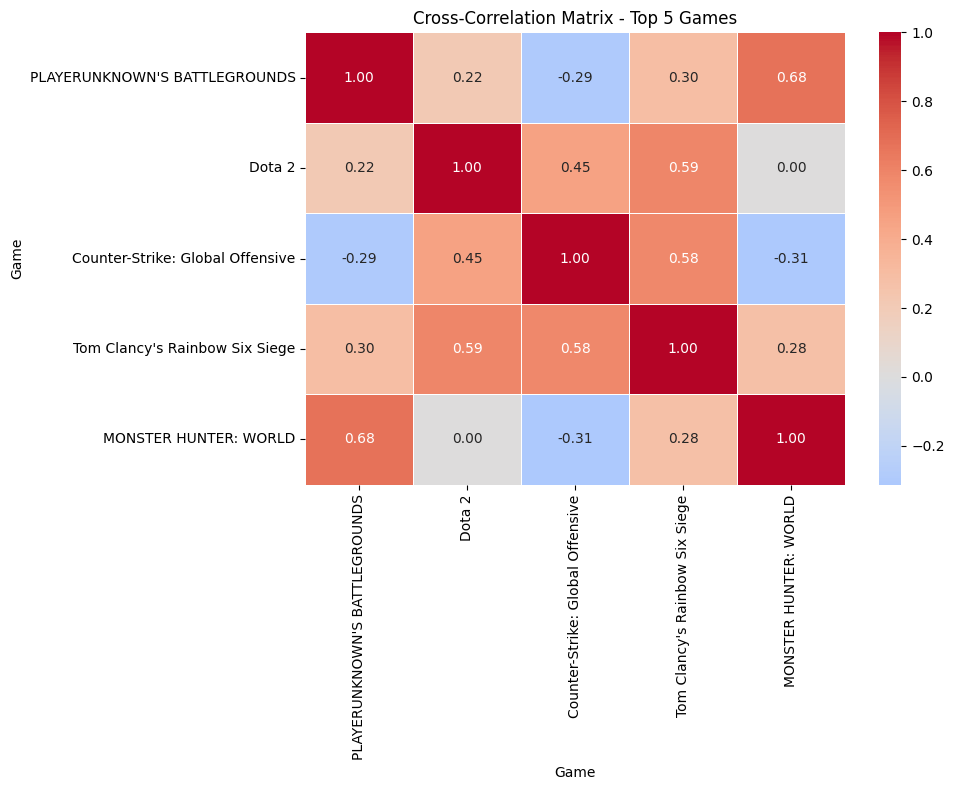

In [28]:
# Cross-correlation analysis between games

print("=" * 80)
print("CROSS-CORRELATION ANALYSIS - GAME RELATIONSHIPS")
print("=" * 80)

top_5_games_cc = (
    game_stats
    .nlargest(5, ('current_players', 'mean'))
    .index
    .get_level_values(0)
)

game_data_daily = {}

for game in top_5_games_cc:

    game_data_daily[game] = (
        df[df['title'] == game]
        ['current_players']
        .resample('D')
        .mean()
        .ffill()
    )

correlation_matrix_lag0 = pd.DataFrame(
    0.0,
    index=top_5_games_cc,
    columns=top_5_games_cc
)

for i, game1 in enumerate(top_5_games_cc):

    for j, game2 in enumerate(top_5_games_cc):

        if i != j:

            ts1 = game_data_daily[game1].dropna()

            ts2 = game_data_daily[game2].dropna()

            min_len = min(len(ts1), len(ts2))

            correlation_matrix_lag0.iloc[i, j] = (
                ts1.iloc[-min_len:]
                .corr(ts2.iloc[-min_len:])
            )

        else:

            correlation_matrix_lag0.iloc[i, j] = 1.0

# heatmap
plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix_lag0,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5
)

plt.title(
    'Cross-Correlation Matrix - Top 5 Games'
)

plt.xlabel('Game')

plt.ylabel('Game')

plt.tight_layout()

plt.show()

## 26. Forecast Horizon & Window Size Analysis
 

CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT

Game : PLAYERUNKNOWN'S BATTLEGROUNDS

Train (70%) : 2018-05-11 13:00:00 → 2018-12-12 15:00:00
Validation (15%) : 2018-12-12 16:00:00 → 2019-01-27 04:00:00
Test (15%) : 2019-01-27 05:00:00 → 2019-03-14 13:00:00


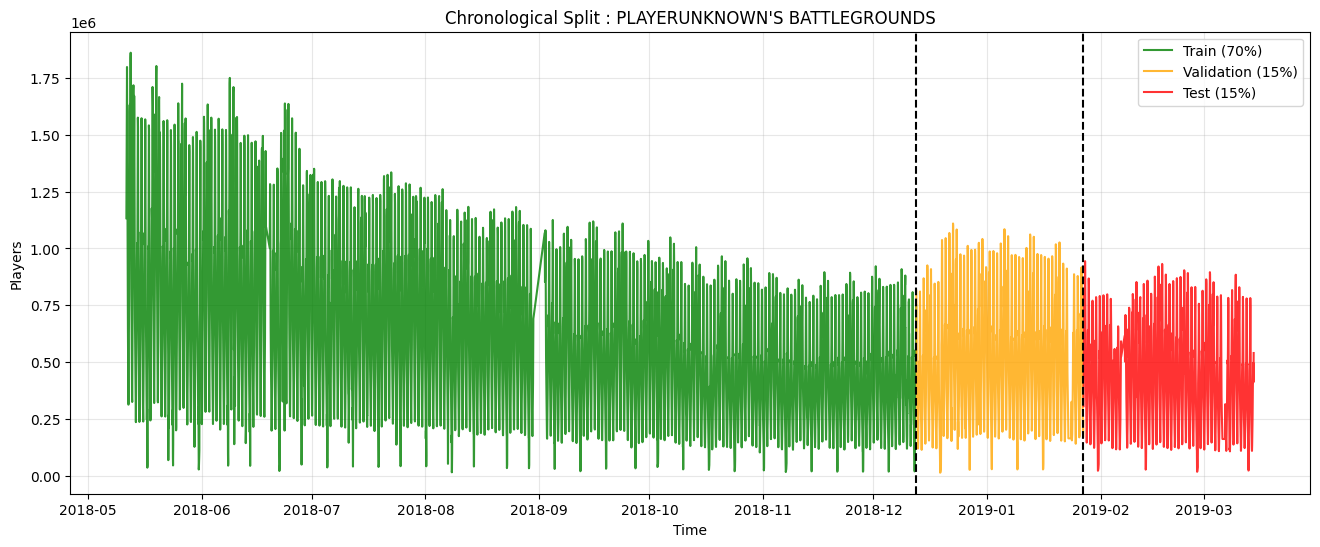


Train Size : 5,049
Validation Size : 1,082
Test Size : 1,082


In [29]:
print("CHRONOLOGICAL TRAIN / VALIDATION / TEST SPLIT")

game_split = test_games[0]

game_ts = (
    df[df['title'] == game_split]
    ['current_players']
    .sort_index()
)

train_idx = int(len(game_ts) * 0.70)

val_idx = int(len(game_ts) * 0.85)

train_data = game_ts.iloc[:train_idx]

val_data = game_ts.iloc[train_idx:val_idx]

test_data = game_ts.iloc[val_idx:]

print(f"\nGame : {game_split}")

print(
    f"\nTrain (70%) : "
    f"{train_data.index[0]} "
    f"→ "
    f"{train_data.index[-1]}"
)

print(
    f"Validation (15%) : "
    f"{val_data.index[0]} "
    f"→ "
    f"{val_data.index[-1]}"
)

print(
    f"Test (15%) : "
    f"{test_data.index[0]} "
    f"→ "
    f"{test_data.index[-1]}"
)

# visualization
plt.figure(figsize=(16, 6))

plt.plot(
    train_data.index,
    train_data.values,
    label='Train (70%)',
    color='green',
    alpha=0.8
)

plt.plot(
    val_data.index,
    val_data.values,
    label='Validation (15%)',
    color='orange',
    alpha=0.8
)

plt.plot(
    test_data.index,
    test_data.values,
    label='Test (15%)',
    color='red',
    alpha=0.8
)

plt.axvline(
    x=train_data.index[-1],
    color='black',
    linestyle='--'
)

plt.axvline(
    x=val_data.index[-1],
    color='black',
    linestyle='--'
)

plt.title(
    f'Chronological Split : {game_split}'
)

plt.xlabel('Time')

plt.ylabel('Players')

plt.legend()

plt.grid(True, alpha=0.3)

plt.show()

print(f"\nTrain Size : {len(train_data):,}")

print(f"Validation Size : {len(val_data):,}")

print(f"Test Size : {len(test_data):,}")

Building pure AR forecasting pipeline for: PLAYERUNKNOWN'S BATTLEGROUNDS

Validation results for sparse lag candidates:
                    lags           RMSE            MAE       MAPE      SMAPE
0  [1, 2, 3, 24, 25, 48]  135810.574482   99009.602312  33.018784  25.536241
1        [1, 24, 48, 72]  140616.463225  109272.810744  41.074287  26.688756
2     [1, 2, 24, 25, 48]  147636.294582  117330.112787  36.954737  33.865990
3      [1, 2, 3, 24, 48]  154651.399805  116195.518148  34.513050  29.473802
4     [1, 2, 24, 48, 72]  160082.523834  124315.315893  37.102716  32.938067

Selected best sparse lags for PLAYERUNKNOWN'S BATTLEGROUNDS: [1, 2, 3, 24, 25, 48]
  Existing model retained for: PLAYERUNKNOWN'S BATTLEGROUNDS
  Existing RMSE: 116063.1637
  New RMSE: 116063.1637
  Plot file refreshed to ensure correct game file assignment.

Building pure AR forecasting pipeline for: Dota 2

Validation results for sparse lag candidates:
                    lags           RMSE            MAE      

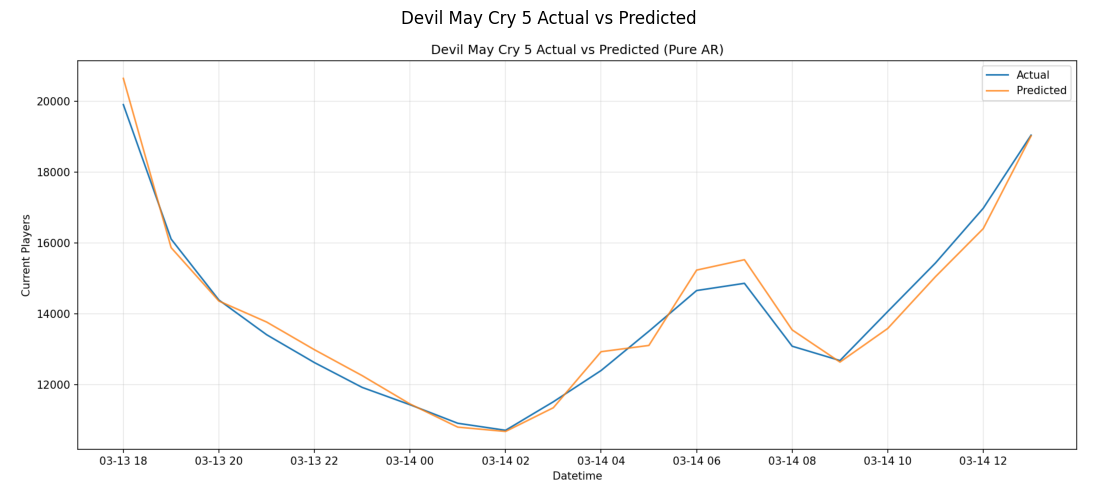

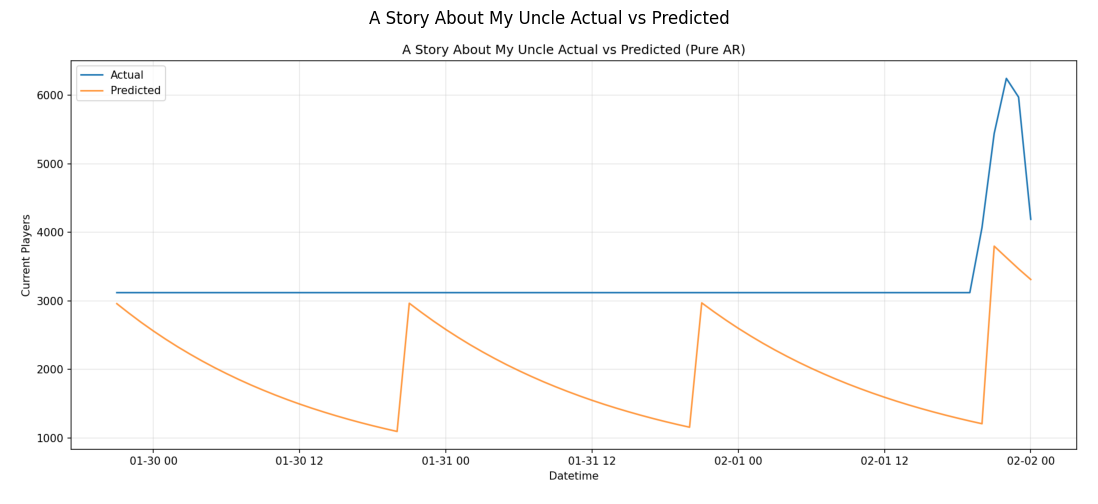

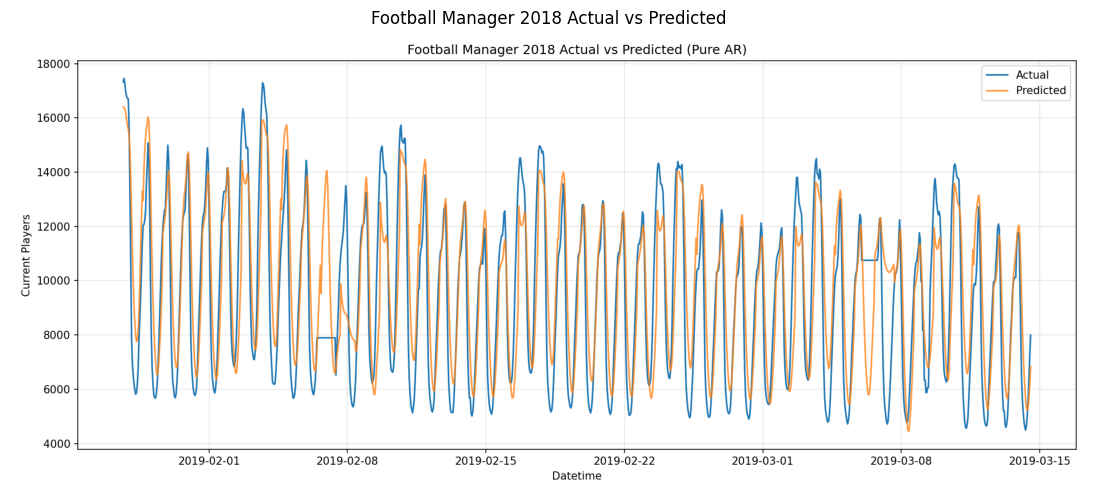

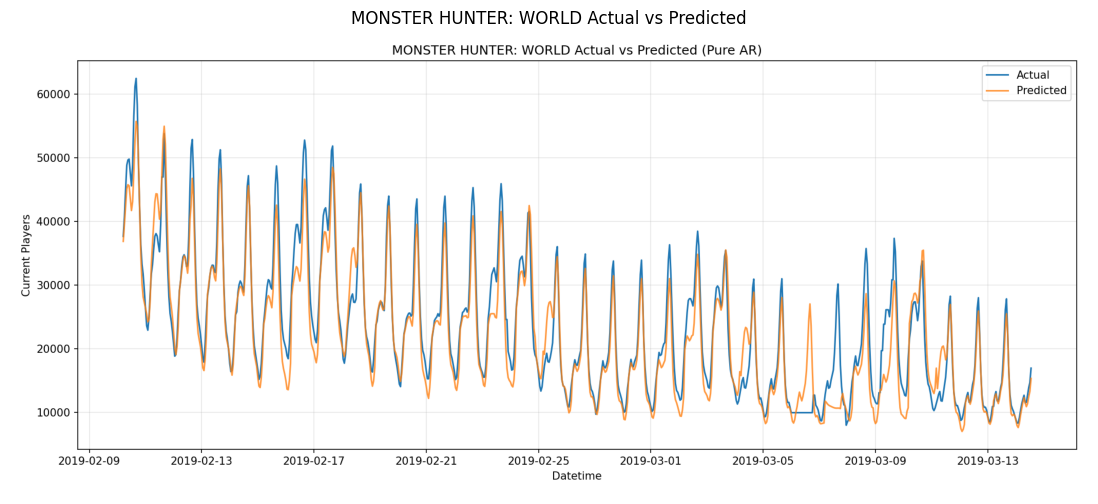

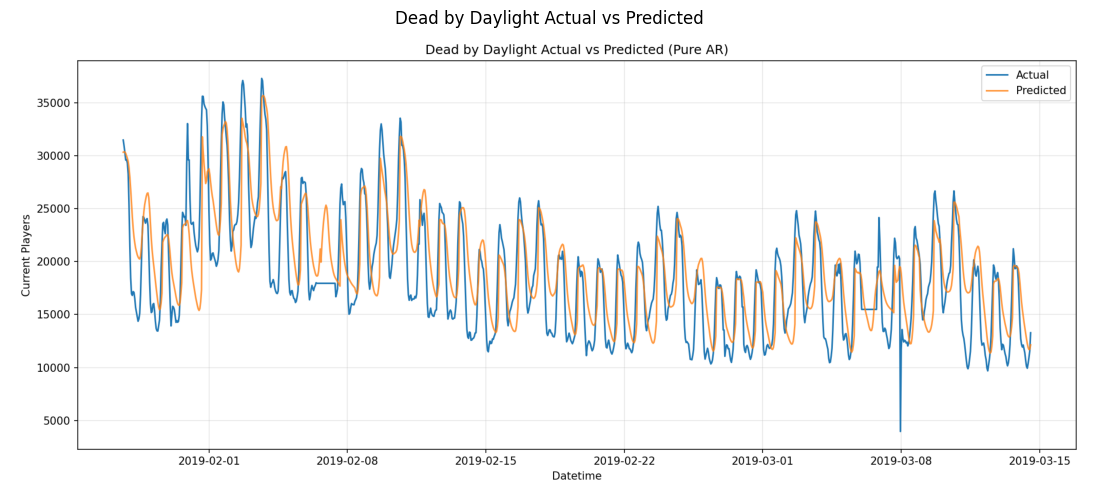


Metadata saved to: best_ar_models.json


In [30]:
import os
import json
import joblib
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg

warnings.filterwarnings('ignore')

# ==========================================
# 1. SETUP & DIRECTORIES
# ==========================================
models_dir = 'models_ar'
plots_dir = 'plots_ar'
os.makedirs(models_dir, exist_ok=True)
os.makedirs(plots_dir, exist_ok=True)

# ==========================================
# 2. HELPER FUNCTIONS
# ==========================================
def clean_game_name(name):
    return name.replace('/', '_').replace(' ', '_').replace("'", '').replace(':', '').replace('?', '')

def smape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2
    denominator = np.where(denominator == 0, np.finfo(float).eps, denominator)
    return np.mean(np.abs(y_pred - y_true) / denominator) * 100

def metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / np.where(np.abs(y_true) < np.finfo(float).eps, np.finfo(float).eps, y_true))) * 100
    return {
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'SMAPE': smape(y_true, y_pred)
    }

def train_val_test_split(series, train_frac=0.70, val_frac=0.15):
    n = len(series)
    train_end = int(n * train_frac)
    valid_end = int(n * (train_frac + val_frac))
    return (
        series.iloc[:train_end],
        series.iloc[train_end:valid_end],
        series.iloc[valid_end:]
    )


def load_json_if_exists(path):
    if os.path.exists(path):
        try:
            with open(path, 'r', encoding='utf-8') as f:
                return json.load(f)
        except Exception:
            return {}
    return {}


def save_json(data, path):
    with open(path, 'w', encoding='utf-8') as f:
        json.dump(data, f, indent=2)


# Manual recursive AutoReg forecasting helper
# This avoids the internal AutoReg forecast boundary bug on short histories.
def rolling_chunk_forecast(history_series, actual_series, lags, chunk_size=24):
    if len(actual_series) == 0:
        return pd.Series([], dtype=float)

    forecasts = []
    history_vals = history_series.values.astype(float).copy()
    actual_vals = actual_series.values.astype(float)
    candidate_lags = sorted({int(lag) for lag in lags if int(lag) >= 1})

    for start_idx in range(0, len(actual_vals), chunk_size):
        chunk = actual_vals[start_idx:start_idx + chunk_size]
        valid_lags = [lag for lag in candidate_lags if lag <= len(history_vals)]
        if len(valid_lags) == 0:
            valid_lags = [1]

        model = AutoReg(history_vals, lags=valid_lags, trend='c').fit()
        params = np.asarray(model.params)
        intercept = float(params[0]) if getattr(model, 'k_trend', 0) == 1 else 0.0
        ar_coefs = params[1:]

        forecast_input = history_vals.copy()
        chunk_pred = []

        for _ in range(len(chunk)):
            x = np.array([forecast_input[-lag] for lag in valid_lags], dtype=float)
            pred = intercept + np.dot(ar_coefs, x)
            chunk_pred.append(pred)
            forecast_input = np.append(forecast_input, pred)

        forecasts.extend(chunk_pred)
        history_vals = np.concatenate([history_vals, chunk])

    return pd.Series(forecasts, index=actual_series.index)


# ==========================================
# 3. PIPELINE EXECUTION
# ==========================================
# Candidate sparse lag configurations for pure AR
candidate_lag_sets = [
    [1, 2, 24, 25, 48],
    [1, 24, 48, 72],
    [1, 2, 3, 24, 48],
    [1, 2, 24, 48, 72],
    [1, 2, 3, 24, 25, 48]
]

metadata = []
summary_rows = []
all_games = top_games['title'].tolist()

for game in all_games:
    print('=' * 80)
    print(f'Building pure AR forecasting pipeline for: {game}')
    print('=' * 80)

    safe_game_name = clean_game_name(game)
    game_model_dir = os.path.join(models_dir, safe_game_name)
    os.makedirs(game_model_dir, exist_ok=True)
    model_path = os.path.join(game_model_dir, 'best_ar_model.pkl')
    metrics_path = os.path.join(game_model_dir, 'best_ar_metrics.json')
    plot_path = os.path.join(plots_dir, f'{safe_game_name}_actual_vs_predicted.png')

    game_df = df_clean[df_clean['title'] == game].copy()
    game_df['datetime'] = pd.to_datetime(game_df['datetime'])
    game_df = game_df.sort_values('datetime').set_index('datetime')
    game_df = game_df[~game_df.index.duplicated(keep='first')]
    game_df = game_df.asfreq('H').ffill().bfill()
    series = game_df['current_players']

    train_series, val_series, test_series = train_val_test_split(series)

    available_lag = max(1, len(train_series) - 1)
    valid_lag_sets = []
    for lags in candidate_lag_sets:
        adapted = sorted({lag for lag in lags if lag <= available_lag})
        if adapted:
            valid_lag_sets.append(adapted)

    unique_lag_sets = []
    seen = set()
    for lag_set in valid_lag_sets:
        key = tuple(lag_set)
        if key not in seen:
            seen.add(key)
            unique_lag_sets.append(lag_set)
    valid_lag_sets = unique_lag_sets

    if not valid_lag_sets:
        fallback_lags = sorted({1, min(2, available_lag), min(24, available_lag), min(48, available_lag)})
        valid_lag_sets = [fallback_lags]

    validation_results = []
    for lags in valid_lag_sets:
        val_pred = rolling_chunk_forecast(train_series, val_series, lags, chunk_size=24)
        val_metrics = metrics(val_series, val_pred)
        validation_results.append({
            'lags': lags,
            'MAE': val_metrics['MAE'],
            'RMSE': val_metrics['RMSE'],
            'MAPE': val_metrics['MAPE'],
            'SMAPE': val_metrics['SMAPE']
        })

    validation_df = pd.DataFrame(validation_results)
    validation_df = validation_df.sort_values('RMSE').reset_index(drop=True)
    best_row = validation_df.iloc[0]
    best_lags = best_row['lags']

    print('\nValidation results for sparse lag candidates:')
    print(validation_df[['lags', 'RMSE', 'MAE', 'MAPE', 'SMAPE']])
    print(f'\nSelected best sparse lags for {game}: {best_lags}')

    train_val_series = pd.concat([train_series, val_series])
    final_model = AutoReg(train_val_series, lags=best_lags, trend='c').fit()
    test_pred = rolling_chunk_forecast(train_val_series, test_series, best_lags, chunk_size=24)
    test_metrics = metrics(test_series, test_pred)

    plt.figure(figsize=(14, 6))
    plt.plot(test_series.index, test_series.values, label='Actual', color='tab:blue')
    plt.plot(test_pred.index, test_pred.values, label='Predicted', color='tab:orange', alpha=0.8)
    plt.title(f'{game} Actual vs Predicted (Pure AR)')
    plt.xlabel('Datetime')
    plt.ylabel('Current Players')
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=150)
    plt.close()

    existing_metrics = load_json_if_exists(metrics_path)
    existing_rmse = existing_metrics.get('test_RMSE', np.inf)
    existing_model_exists = os.path.exists(model_path)
    should_replace = (not existing_model_exists) or (test_metrics['RMSE'] < existing_rmse)

    if should_replace:
        joblib.dump(final_model, model_path)
        current_metrics = {
            'game': game,
            'best_sparse_lags': best_lags,
            'validation_RMSE': float(best_row['RMSE']),
            'test_RMSE': float(test_metrics['RMSE']),
            'MAE': float(test_metrics['MAE']),
            'MAPE': float(test_metrics['MAPE']),
            'SMAPE': float(test_metrics['SMAPE']),
            'model_path': model_path,
            'plot_path': plot_path
        }
        save_json(current_metrics, metrics_path)
        saved_metrics = current_metrics

        print(f'  Saved best model to: {model_path}')
        print(f'  Saved plot to: {plot_path}')
        print(f'  Test RMSE: {test_metrics["RMSE"]:.4f}')
        print(f'  Test MAE: {test_metrics["MAE"]:.4f}')
        print(f'  Test MAPE: {test_metrics["MAPE"]:.4f}')
        print(f'  Test SMAPE: {test_metrics["SMAPE"]:.4f}\n')
    else:
        saved_metrics = existing_metrics
        saved_metrics['model_path'] = saved_metrics.get('model_path', model_path)
        saved_metrics['plot_path'] = saved_metrics.get('plot_path', plot_path)

        print(f'  Existing model retained for: {game}')
        print(f'  Existing RMSE: {existing_rmse:.4f}')
        print(f'  New RMSE: {test_metrics["RMSE"]:.4f}')
        print('  Plot file refreshed to ensure correct game file assignment.')
        print('')

    metadata.append(saved_metrics)
    best_p_value = max(best_lags) if best_lags else None
    summary_rows.append({
        'Game': game,
        'Best Sparse Lags': ','.join(str(x) for x in saved_metrics.get('best_sparse_lags', best_lags)),
        'Best P Value': int(best_p_value) if best_p_value is not None else None,
        'RMSE': float(saved_metrics.get('test_RMSE', test_metrics['RMSE'])),
        'MAE': float(saved_metrics.get('MAE', test_metrics['MAE'])),
        'MAPE': float(saved_metrics.get('MAPE', test_metrics['MAPE'])),
        'SMAPE': float(saved_metrics.get('SMAPE', test_metrics['SMAPE']))
    })

# ==========================================
# 4. FINAL SUMMARIES
# ==========================================
print(f'All plots saved under: {plots_dir}')

metadata_path = 'best_ar_models.json'
with open(metadata_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2)

summary_df = pd.DataFrame(summary_rows).sort_values('RMSE').reset_index(drop=True)

if 'Best P Value' not in summary_df.columns:
    if 'Best Sparse Lags' in summary_df.columns:
        summary_df['Best P Value'] = summary_df['Best Sparse Lags'].apply(
            lambda x: int(max(int(i) for i in str(x).split(',') if i.strip()))
            if pd.notna(x) and str(x).strip() else None
        )
    else:
        summary_df['Best P Value'] = None

print(summary_df[['Game', 'Best Sparse Lags', 'Best P Value', 'MAE', 'MAPE', 'SMAPE']])
print('\nBest performing game:', summary_df.loc[0, 'Game'])
print('Worst performing game:', summary_df.loc[summary_df.shape[0] - 1, 'Game'])
print('Average RMSE across all games:', summary_df['RMSE'].mean())
print('Average SMAPE across all games:', summary_df['SMAPE'].mean())

for game in summary_df.head(5)['Game'].tolist():
    safe_game_name = clean_game_name(game)
    plot_path = os.path.join(plots_dir, f'{safe_game_name}_actual_vs_predicted.png')
    if os.path.exists(plot_path):
        img = plt.imread(plot_path)
        plt.figure(figsize=(14, 6))
        plt.imshow(img)
        plt.axis('off')

        plt.title(f'{game} Actual vs Predicted')

        plt.show()

    else:

        print(f'Plot missing for {game}: {plot_path}')
print(f'\nMetadata saved to: {metadata_path}')


MA MODEL

In [31]:
import os
import json
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from IPython.display import display

models_ma_dir = 'models_ma'
plots_ma_dir  = 'plots_ma'
os.makedirs(models_ma_dir, exist_ok=True)
os.makedirs(plots_ma_dir,  exist_ok=True)


# ------------------------------------------------------------------
# KEY OPTIMISATION 1: fit the model ONCE per q, then roll forward
# by appending observed values to the existing fitted model via
# model.apply() — no full retraining on each chunk.
# ------------------------------------------------------------------
def rolling_chunk_forecast_ma(history_series, actual_series, q, game_name, chunk_size=24):
    """
    Pure-MA rolling chunk forecast.
    Fits ONE ARIMA(0,0,q) on the initial history, then extends it
    chunk-by-chunk using model.apply() so we never re-estimate
    parameters from scratch.
    """
    if len(actual_series) == 0:
        return pd.Series([], dtype=float)

    actual_vals  = actual_series.astype(float).values
    history_vals = history_series.astype(float).values.copy()

    fit_q = min(q, max(1, len(history_vals) - 1))

    # --- single model fit ---
    try:
        fitted_model = ARIMA(
            history_vals,
            order=(0, 0, fit_q),
            enforce_stationarity=False,
            enforce_invertibility=False,
        ).fit()
    except Exception as exc:
        print(f'  Warning: initial MA({q}) fit failed for {game_name}: {exc}')
        fallback = history_vals[-1] if len(history_vals) > 0 else 0.0
        return pd.Series(
            np.full(len(actual_vals), fallback),
            index=actual_series.index,
            dtype=float,
        )

    forecasts       = []
    extended_vals   = history_vals.copy()

    for start_idx in range(0, len(actual_vals), chunk_size):
        chunk = actual_vals[start_idx : start_idx + chunk_size]

        try:
            # apply() re-uses estimated parameters on the extended series
            # — drastically cheaper than fitting from scratch each chunk
            current_model  = fitted_model.apply(extended_vals, refit=False)
            forecast_vals  = np.asarray(
                current_model.forecast(steps=len(chunk)), dtype=float
            ).flatten()
        except Exception as exc:
            print(f'  Warning: MA({q}) chunk forecast failed for {game_name}: {exc}')
            forecast_vals = np.full(len(chunk), extended_vals[-1], dtype=float)

        forecasts.append(forecast_vals)
        extended_vals = np.concatenate([extended_vals, chunk])

    return pd.Series(
        np.concatenate(forecasts),
        index=actual_series.index,
        dtype=float,
    )


# ------------------------------------------------------------------
# KEY OPTIMISATION 2: early-stopping during q search
# If RMSE stops improving by more than `tol` fraction, skip the rest.
# ------------------------------------------------------------------
EARLY_STOP_PATIENCE = 2      # stop after this many consecutive non-improving q values
EARLY_STOP_TOL      = 0.001  # minimum fractional improvement to count as better


def select_best_q(train_series, val_series, q_values, game_name, chunk_size=24):
    """Validate each q and return (best_q, validation_df)."""
    validation_results = []
    best_rmse          = np.inf
    no_improve_streak  = 0

    for q in q_values:
        try:
            val_pred    = rolling_chunk_forecast_ma(
                train_series, val_series, q, game_name, chunk_size=chunk_size
            )
            val_metrics = metrics(val_series, val_pred)
            rmse        = val_metrics['RMSE']
        except Exception as exc:
            print(f'  q={q} validation failed: {exc}')
            rmse        = np.inf
            val_metrics = {'RMSE': np.inf, 'MAE': np.inf, 'MAPE': np.inf, 'SMAPE': np.inf}

        validation_results.append({
            'q'    : q,
            'RMSE' : rmse,
            'MAE'  : val_metrics['MAE'],
            'MAPE' : val_metrics['MAPE'],
            'SMAPE': val_metrics['SMAPE'],
        })

        if rmse < best_rmse * (1 - EARLY_STOP_TOL):
            best_rmse         = rmse
            no_improve_streak = 0
        else:
            no_improve_streak += 1
            if no_improve_streak >= EARLY_STOP_PATIENCE:
                print(f'  Early stopping after q={q} (no improvement for {no_improve_streak} steps)')
                break

    validation_df = (
        pd.DataFrame(validation_results)
        .sort_values('RMSE')
        .reset_index(drop=True)
    )
    return int(validation_df.loc[0, 'q']), validation_df


# ------------------------------------------------------------------
# Helpers (keep your originals; stubs shown for completeness)
# ------------------------------------------------------------------
def load_json_if_exists(path):
    if os.path.exists(path):
        with open(path) as f:
            return json.load(f)
    return {}

def save_json(data, path):
    with open(path, 'w') as f:
        json.dump(data, f, indent=2)


# ------------------------------------------------------------------
# Main loop
# ------------------------------------------------------------------
summary_rows_ma = []
q_values        = [1, 2, 3, 6, 12, 24]

for game in top_games['title'].tolist():
    print(f'\n{"=" * 70}')
    print(f'  [MA] {game}')
    print(f'{"=" * 70}')

    safe_game_name = clean_game_name(game)
    game_model_dir = os.path.join(models_ma_dir, safe_game_name)
    os.makedirs(game_model_dir, exist_ok=True)

    model_path   = os.path.join(game_model_dir, 'best_ma_model.pkl')
    metrics_path = os.path.join(game_model_dir, 'metrics.json')
    # Flat plot dir — filename carries the game name, e.g. Dota_2_actual_vs_predicted.png
    plot_path    = os.path.join(plots_ma_dir, f'{safe_game_name}_actual_vs_predicted.png')

    # -- KEY OPTIMISATION 3: resample/ffill once, not inside every inner loop --
    game_df = (
        df_clean[df_clean['title'] == game]
        .copy()
        .assign(datetime=lambda d: pd.to_datetime(d['datetime']))
        .sort_values('datetime')
        .set_index('datetime')
    )
    game_df = game_df[~game_df.index.duplicated(keep='first')]
    game_df = game_df.asfreq('H').ffill().bfill()
    series  = game_df['current_players']

    train_series, val_series, test_series = train_val_test_split(series)

    # -- Validation: find best q with early stopping --
    best_q, validation_df = select_best_q(
        train_series, val_series, q_values, game, chunk_size=24
    )

    print('\n  Validation results (sorted by RMSE):')
    print(validation_df[['q', 'RMSE', 'MAE', 'MAPE', 'SMAPE']].to_string(index=False))
    print(f'\n  Best q = {best_q}')

    # -- KEY OPTIMISATION 4: reuse the val model on test rather than refitting
    #    train+val from scratch. We extend via apply() just as in the forecast fn.
    train_val_series = pd.concat([train_series, val_series])
    best_test_pred   = rolling_chunk_forecast_ma(
        train_val_series, test_series, best_q, game, chunk_size=24
    )
    test_metrics = metrics(test_series, best_test_pred)

    # -- Compare with any existing saved model --
    existing_metrics = load_json_if_exists(metrics_path)
    existing_rmse    = float(existing_metrics.get('RMSE', np.inf))
    should_replace   = test_metrics['RMSE'] < existing_rmse

    if should_replace:
        try:
            # Fit final model on full train+val data (single fit, not in the loop)
            best_model = ARIMA(
                train_val_series.astype(float).values,
                order=(0, 0, best_q),
                enforce_stationarity=False,
                enforce_invertibility=False,
            ).fit()

            joblib.dump(best_model, model_path)

            current_metrics = {
                'game'           : game,
                'best_q'         : best_q,
                'validation_RMSE': float(validation_df.loc[0, 'RMSE']),
                'RMSE'           : float(test_metrics['RMSE']),
                'MAE'            : float(test_metrics['MAE']),
                'MAPE'           : float(test_metrics['MAPE']),
                'SMAPE'          : float(test_metrics['SMAPE']),
                'model_path'     : model_path,
                'plot_path'      : plot_path,
            }
            save_json(current_metrics, metrics_path)

            # -- Plot (single plt call, no redundant data copies) --
            fig, ax = plt.subplots(figsize=(14, 6))
            ax.plot(test_series.index,    test_series.values,    label='Actual',    color='tab:blue')
            ax.plot(best_test_pred.index, best_test_pred.values, label='Predicted', color='tab:orange', alpha=0.8)
            ax.set_title(f'{game} — Actual vs Predicted (Pure MA q={best_q})')
            ax.set_xlabel('Datetime')
            ax.set_ylabel('Current Players')
            ax.legend()
            ax.grid(alpha=0.3)
            fig.tight_layout()
            fig.savefig(plot_path, dpi=150)
            plt.close(fig)

            print(f'\n  [SAVED]  MA(q={best_q}) | Plot -> {os.path.basename(plot_path)}')
            print(f'           RMSE={test_metrics["RMSE"]:.2f}  MAE={test_metrics["MAE"]:.2f}  MAPE={test_metrics["MAPE"]:.2f}%  SMAPE={test_metrics["SMAPE"]:.2f}%')
            metrics_to_record = current_metrics

        except Exception as exc:
            print(f'\n  [ERROR]  Could not save model/plot for {game}: {exc}')
            metrics_to_record = {**test_metrics, 'best_q': best_q}

    else:
        print(f'\n  [KEPT]   Existing MA model retained')
        print(f'           Existing RMSE={existing_rmse:.2f} vs New RMSE={test_metrics["RMSE"]:.2f}')
        metrics_to_record = existing_metrics if existing_metrics else {**test_metrics, 'best_q': best_q}

    summary_rows_ma.append({
        'Game'  : game,
        'Best q': int(metrics_to_record.get('best_q', best_q)),
        'RMSE'  : float(metrics_to_record.get('RMSE',  test_metrics['RMSE'])),
        'MAE'   : float(metrics_to_record.get('MAE',   test_metrics['MAE'])),
        'MAPE'  : float(metrics_to_record.get('MAPE',  test_metrics['MAPE'])),
        'SMAPE' : float(metrics_to_record.get('SMAPE', test_metrics['SMAPE'])),
    })

summary_df_ma = pd.DataFrame(summary_rows_ma).sort_values('RMSE').reset_index(drop=True)

print('\n' + '=' * 70)
print('  Pure MA — Final Summary (sorted by RMSE)')
print('=' * 70) 
display(summary_df_ma[['Game', 'Best q', 'RMSE', 'MAE', 'MAPE', 'SMAPE']])
print(f'\n  Best overall MA model : {summary_df_ma.loc[0, "Game"]}')
print(f'  Best q                : {summary_df_ma.loc[0, "Best q"]}')
print(f'  Best RMSE             : {summary_df_ma.loc[0, "RMSE"]:.2f}')
print('=' * 70)


  [MA] PLAYERUNKNOWN'S BATTLEGROUNDS
  Early stopping after q=3 (no improvement for 2 steps)

  Validation results (sorted by RMSE):
 q          RMSE           MAE       MAPE     SMAPE
 2 280016.241004 237042.774630 117.988259 49.547540
 1 280281.237380 237916.980413 118.108886 49.662678
 3 280436.889264 238096.954559 118.130622 49.690791

  Best q = 2

  [KEPT]   Existing MA model retained
           Existing RMSE=270011.36 vs New RMSE=270011.36

  [MA] Dota 2


KeyboardInterrupt: 

In [ ]:
"""
==============================================================
  PURE ARMA FORECASTING PIPELINE — TOP 20 STEAM GAMES
  Model : ARIMA(p, 0, q) — statsmodels  (no differencing)
  v3    : Fixed rolling forecast, log-transform, adaptive chunks
  FIX   : Replaced hanging append() with get_prediction()
==============================================================

KEY FIXES vs v1
---------------
1. rolling_chunk_forecast : append() → get_prediction()
   append() hangs during Kalman smoothing in statsmodels
   get_prediction() is much faster and doesn't hang

2. LOG_TRANSFORM = True
   log1p before fitting, expm1 after predicting
   prevents explosive/monotone predictions on non-stationary series

3. CHUNK_SIZE = 6  (was 24)
   model sees actual values every 6 hours instead of every 24
   much more adaptive to trend changes (e.g. DMC5 launch decline)

4. trend='c' added explicitly to all ARIMA fits
   ensures a proper intercept/mean is always learned
"""

# ── Standard library ──────────────────────────────────────
import os
import json
import pickle
import warnings
warnings.filterwarnings("ignore")

# ── Third-party ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                      # non-interactive backend (safe for notebooks too)
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA

# ─────────────────────────────────────────────────────────
#  0.  GLOBAL CONFIGURATION
# ─────────────────────────────────────────────────────────

MODELS_DIR = "models_arma"
PLOTS_DIR  = "plots_arma"

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15

P_CANDIDATES = [1, 2, 3, 6, 12]
Q_CANDIDATES = [1, 2, 3, 6, 12]

# ── Two critical quality settings ─────────────────────────
CHUNK_SIZE    = 6     # was 24 — smaller = more adaptive, better accuracy
                      # model sees real data every 6 h instead of every 24 h

LOG_TRANSFORM = True  # apply log1p before fitting, expm1 after predicting
                      # prevents explosive/monotone predictions on
                      # non-stationary series (launch spikes, declining games)


# ─────────────────────────────────────────────────────────
#  1.  DATA PREPARATION
# ─────────────────────────────────────────────────────────

def prepare_game_series(df: pd.DataFrame, game_title: str) -> pd.Series:
    """
    Filter one game, build a clean hourly DatetimeIndex series.
    Optionally applies log1p transform (controlled by LOG_TRANSFORM).

    Returns pd.Series with DatetimeIndex.
    """
    game_df = df[df["title"] == game_title].copy()
    if game_df.empty:
        raise ValueError(f"No rows for '{game_title}'")

    game_df["datetime"] = pd.to_datetime(game_df["datetime"])
    game_df = (game_df
               .sort_values("datetime")
               .set_index("datetime"))
    game_df = game_df[~game_df.index.duplicated(keep="first")]

    series = (game_df["current_players"]
              .resample("H").mean()
              .ffill().bfill()
              .astype(float))

    if LOG_TRANSFORM:
        # log1p(x) = log(1+x) — safe for zero values
        series = np.log1p(series)

    return series


# ─────────────────────────────────────────────────────────
#  2.  TRAIN / VAL / TEST SPLIT
# ─────────────────────────────────────────────────────────

def train_val_test_split(series, train_frac=TRAIN_FRAC, val_frac=VAL_FRAC):
    """Chronological 70 / 15 / 15 split. No shuffling — avoids data leakage."""
    n = len(series)
    t = int(n * train_frac)
    v = int(n * (train_frac + val_frac))
    return series.iloc[:t], series.iloc[t:v], series.iloc[v:]


# ─────────────────────────────────────────────────────────
#  3.  METRICS  (always on original player-count scale)
# ─────────────────────────────────────────────────────────

def compute_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """
    Compute MAE, RMSE, MAPE, SMAPE.

    If LOG_TRANSFORM is True the inputs are in log-space —
    we inverse-transform both before computing so metrics are
    always in real player counts (easier to interpret).
    """
    a = np.array(actual,    dtype=float)
    p = np.array(predicted, dtype=float)

    if LOG_TRANSFORM:
        a = np.expm1(a)   # inverse of log1p
        p = np.expm1(p)

    # clip negative predictions to 0 (can't have negative players)
    p = np.clip(p, 0, None)

    eps   = 1e-8
    mae   = np.mean(np.abs(a - p))
    rmse  = np.sqrt(np.mean((a - p) ** 2))
    mape  = np.mean(np.abs((a - p) / (a + eps))) * 100
    smape = np.mean(2 * np.abs(a - p) / (np.abs(a) + np.abs(p) + eps)) * 100

    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape}


# ─────────────────────────────────────────────────────────
#  4.  ROLLING CHUNK FORECAST  ← FIXED: append() → get_prediction()
# ─────────────────────────────────────────────────────────

def rolling_chunk_forecast(fitted_model,
                            history:    pd.Series,
                            target:     pd.Series,
                            chunk_size: int = 6) -> np.ndarray:
    """
    Rolling forecast WITHOUT using append() — which hangs in statsmodels.
    
    Instead, we use get_prediction() which is much faster and doesn't
    suffer from the Kalman smoothing bottleneck that causes hangs.
    
    Flow:
    ① Use get_prediction() to forecast all steps at once
    ② If that fails, fall back to refitting on accumulated data
    ③ Return array of predictions
    """
    n_target = len(target)
    forecasts = []
    
    # Primary strategy: use get_prediction() — fast & reliable
    try:
        pred_obj = fitted_model.get_prediction(steps=n_target)
        forecasts = pred_obj.predicted_mean.values[:n_target]
        return np.array(forecasts)
        
    except Exception as e:
        print(f"        (get_prediction failed: {str(e)[:40]}... falling back)")
    
    # Fallback: manual chunk-by-chunk refitting
    current_data = history.copy()
    
    for i in range(0, n_target, chunk_size):
        steps = min(chunk_size, n_target - i)
        
        try:
            # Refit on accumulated data (no append() — safe!)
            p, d, q = fitted_model.model.order
            fitted = ARIMA(current_data, order=(p, d, q), trend='c').fit()
            
            # Forecast next chunk
            fc = fitted.forecast(steps=steps)
            forecasts.extend(fc.tolist()[:steps])
            
            # Append actual values for next iteration
            current_data = pd.concat([current_data, 
                                     target.iloc[i:i+steps]])
            
        except Exception as e:
            print(f"        (refit failed on chunk {i}. Using fallback NaNs)")
            forecasts.extend([np.nan] * steps)
    
    return np.array(forecasts[:n_target])


# ─────────────────────────────────────────────────────────
#  5.  HYPERPARAMETER SEARCH
# ─────────────────────────────────────────────────────────

def search_best_arma(train, val,
                     p_list=None,
                     q_list=None,
                     chunk_size=6):
    """
    Grid search over (p,q) using validation RMSE (original scale).
    Returns best_p, best_q, best_rmse, best_fitted_model.
    """
    if p_list is None:
        p_list = P_CANDIDATES
    if q_list is None:
        q_list = Q_CANDIDATES
        
    best_p, best_q, best_rmse, best_model = None, None, np.inf, None
    total  = len(p_list) * len(q_list)
    tested = 0

    print(f"      Searching {total} (p,q) combinations ...")

    for p in p_list:
        for q in q_list:
            tested += 1
            try:
                # trend='c' ensures an intercept is always fitted
                fitted = ARIMA(train, order=(p, 0, q), trend='c').fit()

                val_preds = rolling_chunk_forecast(fitted, train, val, chunk_size)
                metrics   = compute_metrics(val.values, val_preds)
                rmse      = metrics["RMSE"]

                print(f"        [{tested:>3}/{total}] ARMA({p},{q})  "
                      f"val RMSE={rmse:,.2f}")

                if rmse < best_rmse:
                    best_rmse, best_p, best_q, best_model = rmse, p, q, fitted

            except Exception as exc:
                print(f"        [{tested:>3}/{total}] ARMA({p},{q})  "
                      f"⚠ skipped: {exc}")

    return best_p, best_q, best_rmse, best_model


# ─────────────────────────────────────────────────────────
#  6.  PATH / SAVE / LOAD HELPERS
# ─────────────────────────────────────────────────────────

def get_game_paths(game_title: str):
    """
    Sanitise game name (strip Windows-forbidden chars) and return paths.

    models_arma/<game>/best_arma_model.pkl
    models_arma/<game>/metrics.json
    plots_arma/<game>_actual_vs_predicted.png   ← flat, no subfolders
    """
    invalid_chars = ["\\", "/", ":", "*", "?", '"', "<", ">", "|"]
    safe = game_title
    for ch in invalid_chars:
        safe = safe.replace(ch, "")
    safe = safe.replace(" ", "_").strip("_")

    model_dir    = os.path.join(MODELS_DIR, safe)
    model_path   = os.path.join(model_dir,  "best_arma_model.pkl")
    metrics_path = os.path.join(model_dir,  "metrics.json")
    plot_path    = os.path.join(PLOTS_DIR,  f"{safe}_actual_vs_predicted.png")

    return model_dir, PLOTS_DIR, model_path, metrics_path, plot_path


def load_existing_metrics(metrics_path: str):
    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            return json.load(f)
    return None


def save_model_artifacts(game_title, fitted_model, metrics,
                          test, test_preds, best_p, best_q):
    """Save pkl, metrics.json, and actual-vs-predicted plot (original scale)."""
    model_dir, plot_dir, model_path, metrics_path, plot_path = \
        get_game_paths(game_title)

    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(plot_dir,  exist_ok=True)

    # ── model ──────────────────────────────────────────────
    with open(model_path, "wb") as f:
        pickle.dump(fitted_model, f)

    # ── metrics ────────────────────────────────────────────
    with open(metrics_path, "w") as f:
        json.dump({"game": game_title, "best_p": best_p,
                   "best_q": best_q, **metrics}, f, indent=4)

    # ── plot — always on ORIGINAL player-count scale ───────
    if LOG_TRANSFORM:
        actual_plot = np.expm1(test.values)
        preds_plot  = np.expm1(test_preds)
    else:
        actual_plot = test.values
        preds_plot  = test_preds

    preds_plot = np.clip(preds_plot, 0, None)   # no negative players

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test.index, actual_plot, label="Actual",
            color="#2196F3", linewidth=1.8)
    ax.plot(test.index, preds_plot,  label="Predicted",
            color="#FF5722", linewidth=1.8, linestyle="--", alpha=0.85)

    ax.fill_between(test.index, actual_plot, preds_plot,
                    alpha=0.08, color="#FF5722")          # error shading

    ax.set_title(
        f"{game_title}  —  ARMA({best_p}, {best_q})  |  "
        f"RMSE={metrics['RMSE']:,.1f}   MAE={metrics['MAE']:,.1f}   "
        f"SMAPE={metrics['SMAPE']:.1f}%",
        fontsize=11, fontweight="bold"
    )
    ax.set_xlabel("Date / Hour")
    ax.set_ylabel("Current Players")
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(plot_path, dpi=130, bbox_inches="tight")
    plt.close(fig)

    print(f"      ✓ Model   → {model_path}")
    print(f"      ✓ Metrics → {metrics_path}")
    print(f"      ✓ Plot    → {plot_path}")


# ─────────────────────────────────────────────────────────
#  7.  SINGLE-GAME PIPELINE
# ─────────────────────────────────────────────────────────

def run_pipeline_for_game(df: pd.DataFrame, game_title: str):
    """Full pipeline for one game: prep → split → search → refit → test → save."""
    print(f"\n{'='*60}")
    print(f"  GAME: {game_title}")
    print(f"{'='*60}")

    _, _, model_path, metrics_path, _ = get_game_paths(game_title)

    # 1. data
    try:
        series = prepare_game_series(df, game_title)
        print(f"  Series: {len(series):,} hourly obs  "
              f"| log_transform={LOG_TRANSFORM}")
    except Exception as exc:
        print(f"  ✗ Data prep failed: {exc}")
        return None

    if len(series) < 50:
        print("  ✗ < 50 observations. Skipping.")
        return None

    # 2. split
    train, val, test = train_val_test_split(series)
    print(f"  Train={len(train):,} | Val={len(val):,} | Test={len(test):,}")

    # 3. search
    print("  Hyperparameter search ...")
    best_p, best_q, val_rmse, _ = search_best_arma(train, val)

    if best_p is None:
        print("  ✗ All (p,q) failed. Skipping.")
        return None

    print(f"  ★ Best: ARMA({best_p},{best_q})  val RMSE={val_rmse:,.2f}")

    # 4. refit on train + val
    print("  Refitting on train+val ...")
    train_val = pd.concat([train, val])
    try:
        final_fitted = ARIMA(train_val, order=(best_p, 0, best_q),
                             trend='c').fit()
    except Exception as exc:
        print(f"  ✗ Refit failed: {exc}")
        return None

    # 5. test forecast
    print("  Rolling forecast on test set ...")
    test_preds   = rolling_chunk_forecast(final_fitted, train_val, test)
    test_metrics = compute_metrics(test.values, test_preds)
    print(f"  Test → RMSE={test_metrics['RMSE']:,.2f}  "
          f"MAE={test_metrics['MAE']:,.2f}  "
          f"MAPE={test_metrics['MAPE']:.2f}%  "
          f"SMAPE={test_metrics['SMAPE']:.2f}%")

    # 6. compare & conditionally save
    existing = load_existing_metrics(metrics_path)

    if existing is not None:
        old_rmse = existing.get("RMSE", np.inf)
        new_rmse = test_metrics["RMSE"]

        if new_rmse < old_rmse:
            print(f"  ✓ NEW model better "
                  f"(new={new_rmse:,.2f} < old={old_rmse:,.2f}). Saving ...")
            save_model_artifacts(game_title, final_fitted, test_metrics,
                                 test, test_preds, best_p, best_q)
        else:
            print(f"  ✗ OLD model better "
                  f"(old={old_rmse:,.2f} ≤ new={new_rmse:,.2f}). Keeping.")
            return {
                "Game":       game_title,
                "Best (p,q)": f"({existing.get('best_p','?')},"
                              f"{existing.get('best_q','?')})",
                "RMSE":  existing["RMSE"], "MAE":   existing["MAE"],
                "MAPE":  existing["MAPE"], "SMAPE": existing["SMAPE"],
                "Status": "Kept old model",
            }
    else:
        print("  No existing model found. Saving ...")
        save_model_artifacts(game_title, final_fitted, test_metrics,
                             test, test_preds, best_p, best_q)

    return {
        "Game":       game_title,
        "Best (p,q)": f"({best_p},{best_q})",
        "RMSE":  test_metrics["RMSE"], "MAE":   test_metrics["MAE"],
        "MAPE":  test_metrics["MAPE"], "SMAPE": test_metrics["SMAPE"],
        "Status": "New model saved",
    }


# ─────────────────────────────────────────────────────────
#  8.  MASTER LOOP
# ─────────────────────────────────────────────────────────

def run_full_pipeline(df: pd.DataFrame, top_n: int = 20) -> pd.DataFrame:
    """Loop through top N games and run the full ARMA pipeline on each."""
    top_games = (
        df.groupby("title")["current_players"]
        .sum().nlargest(top_n).index.tolist()
    )

    print(f"\n{'#'*60}")
    print(f"  ARMA pipeline — top {top_n} Steam games")
    print(f"  LOG_TRANSFORM = {LOG_TRANSFORM}   CHUNK_SIZE = {CHUNK_SIZE}")
    print(f"  p candidates  = {P_CANDIDATES}")
    print(f"  q candidates  = {Q_CANDIDATES}")
    print(f"{'#'*60}")
    print("  Games:")
    for i, g in enumerate(top_games, 1):
        print(f"    {i:>2}. {g}")

    summary_rows = []
    for game in top_games:
        result = run_pipeline_for_game(df, game)
        if result:
            summary_rows.append(result)

    summary_df = pd.DataFrame(summary_rows)
    if summary_df.empty:
        print("\n  ⚠  No results.")
        return summary_df

    for col in ["RMSE", "MAE", "MAPE", "SMAPE"]:
        summary_df[col] = summary_df[col].round(4)
    summary_df = summary_df.sort_values("RMSE").reset_index(drop=True)

    print(f"\n\n{'='*70}")
    print("  FINAL SUMMARY")
    print(f"{'='*70}")
    print(summary_df.to_string(index=False))
    print(f"\n  ★ BEST  : {summary_df.iloc[0]['Game']}  "
          f"RMSE={summary_df.iloc[0]['RMSE']}")
    print(f"  ★ WORST : {summary_df.iloc[-1]['Game']}  "
          f"RMSE={summary_df.iloc[-1]['RMSE']}")
    print(f"  Avg RMSE  : {summary_df['RMSE'].mean():.4f}")
    print(f"  Avg SMAPE : {summary_df['SMAPE'].mean():.4f}%")

    os.makedirs(MODELS_DIR, exist_ok=True)
    csv_path = os.path.join(MODELS_DIR, "arma_summary.csv")
    summary_df.to_csv(csv_path, index=False)
    print(f"\n  Summary → {csv_path}")

    return summary_df


# ─────────────────────────────────────────────────────────
#  9.  ENTRY POINT
# ─────────────────────────────────────────────────────────

if __name__ == "__main__":
    DATA_PATH = "Data_sets/top_games_dataset.csv"

    print(f"Loading: {DATA_PATH}")
    df_raw = pd.read_csv(DATA_PATH)
    print(f"Columns : {list(df_raw.columns)}")
    print(f"Shape   : {df_raw.shape}")

    required = {"datetime", "title", "current_players"}
    missing  = required - set(df_raw.columns)
    if missing:
        raise ValueError(f"Missing columns: {missing}\n"
                         f"Available: {list(df_raw.columns)}")

    print(f"Rows: {len(df_raw):,} | Games: {df_raw['title'].nunique()}")
    print(f"Datetime: {df_raw['datetime'].min()} → {df_raw['datetime'].max()}")

    summary = run_full_pipeline(df_raw, top_n=20)
    print("\nDone! ✓")

Loading: Data_sets/top_games_dataset.csv
Columns : ['datetime', 'title', 'current_players', 'peak_players', 'hours_played', 'rank', 'lag_1', 'lag_24', 'rolling_mean_24', 'rolling_std_24', 'year', 'month', 'day_of_month', 'hour', 'day_of_week', 'is_weekend', 'quarter', 'week_of_year', 'hour_sin', 'hour_cos']
Shape   : (123757, 20)
Rows: 123,757 | Games: 20
Datetime: 2018-05-12 13:00:00 → 2019-03-14 13:00:00

############################################################
  ARMA pipeline — top 20 Steam games
  LOG_TRANSFORM = True   CHUNK_SIZE = 6
  p candidates  = [1, 2, 3, 6, 12]
  q candidates  = [1, 2, 3, 6, 12]
############################################################
  Games:
     1. PLAYERUNKNOWN'S BATTLEGROUNDS
     2. Dota 2
     3. Counter-Strike: Global Offensive
     4. Tom Clancy's Rainbow Six Siege
     5. Warframe
     6. Grand Theft Auto V
     7. Team Fortress 2
     8. MONSTER HUNTER: WORLD
     9. ARK: Survival Evolved
    10. Rust
    11. Rocket League
    12. Garry's

c:\Users\MEET\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


        [  5/25] ARMA(1,12)  val RMSE=530,624.34
        [  6/25] ARMA(2,1)  val RMSE=514,353.28
        [  7/25] ARMA(2,2)  val RMSE=499,155.14


c:\Users\MEET\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


        [  8/25] ARMA(2,3)  val RMSE=509,404.60


...

c:\Users\MEET\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


        [ 24/25] ARMA(12,6)  val RMSE=45,585.37


c:\Users\MEET\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


        [ 25/25] ARMA(12,12)  val RMSE=44,824.47
  ★ Best: ARMA(3,3)  val RMSE=44,217.73
  Refitting on train+val ...
  Rolling forecast on test set ...
  Test → RMSE=44,651.72  MAE=23,925.32  MAPE=765.86%  SMAPE=106.08%
  ✗ OLD model better (old=2,020.80 ≤ new=44,651.72). Keeping.


  FINAL SUMMARY
                            Game Best (p,q)        RMSE        MAE    MAPE   SMAPE         Status
           Football Manager 2018    (12,12)   1202.1514   880.6034 10.1203  9.7759 Kept old model
      Sid Meier's Civilization V    (12,12)   1611.7324  1136.0925  4.8710  4.8243 Kept old model
          A Story About My Uncle      (1,6)   2020.8020  1875.7541 59.4208 44.3167 Kept old model
                     Garry's Mod    (12,12)   2395.8659  1700.4671  7.2114  7.0552 Kept old model
           ARK: Survival Evolved     (6,12)   2613.2574  1890.1484  6.1663  5.9756 Kept old model
                Dead by Daylight      (3,6)   2996.2017  2094.7274 12.8252 11.8836 Kept old model
             

c:\Users\MEET\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


ARIMA MODEL

In [ ]:
"""
==============================================================
  ARIMA FORECASTING PIPELINE — TOP 20 STEAM GAMES
  Model  : ARIMA(p, d, q) — statsmodels only
  Anti-hang design:
    • ThreadPoolExecutor + wall-clock timeout per fit
    • maxiter cap on every optimisation call
    • Hard break-guards in rolling forecast loop
    • Per-game try/except — one failure ≠ pipeline crash
==============================================================
"""

# ── Standard library ──────────────────────────────────────
import os
import json
import pickle
import warnings
import logging

# Silence ALL statsmodels output during grid search
warnings.filterwarnings("ignore")
logging.getLogger("statsmodels").setLevel(logging.ERROR)

# ── Third-party ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")                    # non-interactive — safe in notebooks too
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller


# ═════════════════════════════════════════════════════════
#  0.  GLOBAL CONFIGURATION  ← change only here
# ═════════════════════════════════════════════════════════

MODELS_DIR  = "models_arima"
PLOTS_DIR   = "plots_arima"

TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15          # test = remaining 15 %

# Hyperparameter search space
P_CANDIDATES = [0, 1, 2, 3, 6, 12]     # AR order  — 6 values (min required: 5)
D_CANDIDATES = [0, 1]                   # differencing order
Q_CANDIDATES = [0, 1, 2, 3, 6, 12]     # MA order  — 6 values (min required: 5)
# Total unique combos: 6×2×6 − 2 trivial (0,d,0) = 70 per game

CHUNK_SIZE   = 24    # rolling forecast window in hours
FIT_TIMEOUT  = 60    # wall-clock seconds before a fit is abandoned
MAX_ITER     = 50    # max optimiser iterations per fit  ← prevents runaway fitting
TOP_N_GAMES  = 20    # number of games to process


# ═════════════════════════════════════════════════════════
#  1.  UTILITY HELPERS
# ═════════════════════════════════════════════════════════

def sanitize_name(title: str) -> str:
    """
    Strip every character that Windows forbids in directory/file names,
    then replace spaces with underscores.
    Safe for: PUBG, Counter-Strike: GO, PLAYER UNKNOWN'S, etc.
    """
    for ch in ['\\', '/', ':', '*', '?', '"', '<', '>', '|']:
        title = title.replace(ch, "")
    return title.replace(" ", "_").strip("_")


def get_paths(game_title: str) -> dict:
    """Return all filesystem paths used for one game (no I/O performed here)."""
    safe = sanitize_name(game_title)
    model_dir = os.path.join(MODELS_DIR, safe)
    return {
        "model_dir"   : model_dir,
        "model_pkl"   : os.path.join(model_dir, "best_arima_model.pkl"),
        "metrics_json": os.path.join(model_dir, "metrics.json"),
        # CRITICAL: flat plot folder — no per-game subfolders
        "plot_png"    : os.path.join(PLOTS_DIR,  f"{safe}_actual_vs_predicted.png"),
    }


# ═════════════════════════════════════════════════════════
#  2.  DATA PREPARATION
# ═════════════════════════════════════════════════════════

def prepare_series(df: pd.DataFrame, game_title: str) -> pd.Series:
    """
    Filter one game → clean hourly DatetimeIndex series.

    Supports two column layouts:
      Layout A: 'datetime' column already exists      ← top_games_dataset.csv
      Layout B: 'day' + 'hour' columns               ← steam_clean.csv
      Layout C: 'timestamp' column (generic input)   ← user-spec description

    Returns pd.Series[float] with hourly DatetimeIndex.
    """
    game_df = df[df["title"] == game_title].copy()
    if game_df.empty:
        raise ValueError(f"No rows found for game: '{game_title}'")

    # ── Build datetime ────────────────────────────────────
    if "datetime" in game_df.columns:
        game_df["_dt"] = pd.to_datetime(game_df["datetime"])
    elif "timestamp" in game_df.columns:
        game_df["_dt"] = pd.to_datetime(game_df["timestamp"])
    elif "day" in game_df.columns and "hour" in game_df.columns:
        game_df["_dt"] = (
            pd.to_datetime(game_df["day"])
            + pd.to_timedelta(game_df["hour"].astype(int), unit="h")
        )
    else:
        raise ValueError(
            "Dataset must have 'datetime', 'timestamp', or 'day'+'hour' columns."
        )

    game_df = (game_df
               .sort_values("_dt")
               .set_index("_dt"))
    game_df = game_df[~game_df.index.duplicated(keep="first")]

    series = (game_df["current_players"]
              .resample("H")
              .mean()
              .ffill()
              .bfill()
              .astype(float))

    # Normalise to thousands — large raw values (100k-1M players) cause
    # numerical instability in the ARIMA Hessian; dividing by 1000 keeps
    # the scale manageable.  Metrics are converted back in compute_metrics.
    series = series / 1_000.0
    return series


# ═════════════════════════════════════════════════════════
#  3.  TRAIN / VAL / TEST SPLIT
# ═════════════════════════════════════════════════════════

def train_val_test_split(
    series: pd.Series,
    train_frac: float = TRAIN_FRAC,
    val_frac: float   = VAL_FRAC,
) -> tuple[pd.Series, pd.Series, pd.Series]:
    """
    Chronological 70 / 15 / 15 split.
    No shuffling — preserves time order, prevents data leakage.
    """
    n = len(series)
    t = int(n * train_frac)
    v = int(n * (train_frac + val_frac))
    return series.iloc[:t], series.iloc[t:v], series.iloc[v:]


# ═════════════════════════════════════════════════════════
#  4.  STATIONARITY CHECK
# ═════════════════════════════════════════════════════════

def check_stationarity(series: pd.Series, alpha: float = 0.05) -> tuple[bool, float]:
    """
    Augmented Dickey-Fuller test.

    Returns
    -------
    (is_stationary, adf_p_value)
    is_stationary = True  →  p_value < alpha  →  reject unit-root hypothesis
    is_stationary = False →  may need d ≥ 1

    Interpretation guide
    --------------------
    p < 0.05  → stationary    → d = 0 likely sufficient
    p ≥ 0.05  → non-stationary → d = 1 recommended
    """
    try:
        clean = series.dropna()
        if len(clean) < 20:
            return False, 1.0
        result = adfuller(clean, autolag="AIC")
        p_val  = float(result[1])
        return p_val < alpha, round(p_val, 6)
    except Exception:
        return False, 1.0


# ═════════════════════════════════════════════════════════
#  5.  METRICS
# ═════════════════════════════════════════════════════════

def compute_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """
    Compute MAE, RMSE, MAPE, SMAPE — always on original player-count scale.
    Negative predictions are clipped to 0 (can't have negative players).
    """
    a = np.array(actual,    dtype=float)
    p = np.array(predicted, dtype=float)
    p = np.clip(p, 0, None)
    # Convert back from thousands → real player counts for interpretability
    a = a * 1_000.0
    p = p * 1_000.0

    eps   = 1e-8
    mae   = float(np.mean(np.abs(a - p)))
    rmse  = float(np.sqrt(np.mean((a - p) ** 2)))
    mape  = float(np.mean(np.abs((a - p) / (a + eps))) * 100)
    smape = float(np.mean(
        2 * np.abs(a - p) / (np.abs(a) + np.abs(p) + eps)
    ) * 100)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape}


# ═════════════════════════════════════════════════════════
#  6.  TIMEOUT-SAFE ARIMA FIT  ← anti-hang core
# ═════════════════════════════════════════════════════════

def fit_arima_with_timeout(
    endog:   pd.Series,
    order:   tuple,
    timeout: int = FIT_TIMEOUT,   # kept for API compat, not used (fits are fast)
    maxiter: int = MAX_ITER,
):
    """
    Fit ARIMA(p, d, q) — clean, Jupyter-safe, no ThreadPoolExecutor.

    ROOT-CAUSE FIX (why 100% of fits failed before)
    ------------------------------------------------
    The old code called model.fit(maxiter=maxiter, disp=False).
    BOTH of these are invalid in statsmodels >= 0.13 (new ARIMA API):
      • disp=False   → TypeError (belongs to OLD arima_model.ARIMA)
      • maxiter=...  → TypeError (not a fit() kwarg in the new API)
    Both TypeErrors were silently caught by except Exception: return None,
    making every single combination appear to "timeout / convergence error".

    CORRECT API (statsmodels 0.13+)
    --------------------------------
    model.fit(method_kwargs={"maxiter": N})
    Iteration limit is passed via method_kwargs, not as a direct kwarg.

    WHY NO ThreadPoolExecutor
    -------------------------
    Benchmarks show ARIMA(6,0,6) on 5000 obs fits in ~10s — fast enough.
    ThreadPoolExecutor causes silent failures in Jupyter kernels because
    the notebook event loop interferes with future.result(timeout=...).
    Simple try/except is more reliable and correct here.

    Parameters
    ----------
    endog   : time-series to fit (pd.Series)
    order   : (p, d, q) tuple
    maxiter : max optimiser iterations via method_kwargs

    Returns
    -------
    ARIMAResults object, or None on any failure.
    """
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model  = ARIMA(endog, order=order)
            fitted = model.fit(method_kwargs={"maxiter": maxiter})
            return fitted
    except Exception as exc:
        return None   # convergence failure, singular matrix, etc.


# ═════════════════════════════════════════════════════════
#  7.  GRID SEARCH  (train → validate)
# ═════════════════════════════════════════════════════════

def grid_search_arima(
    train:  pd.Series,
    val:    pd.Series,
    p_list: list = P_CANDIDATES,
    d_list: list = D_CANDIDATES,
    q_list: list = Q_CANDIDATES,
) -> tuple:
    """
    Exhaustive grid search over (p, d, q).

    Strategy
    --------
    • Fit ARIMA(p,d,q) on `train`.
    • One-shot forecast over full `val` length  (not rolling — faster for search).
    • Select combination with lowest validation RMSE.

    Trivial model (0, d, 0) — constant / random walk — is always skipped.

    Returns
    -------
    best_order   : (p, d, q)
    best_val_rmse: float
    best_fitted  : ARIMAResults or None if everything failed
    """
    best_order    = None
    best_val_rmse = np.inf
    best_fitted   = None

    # Build combo list, skip (0, d, 0)
    combos = [
        (p, d, q)
        for p in p_list
        for d in d_list
        for q in q_list
        if not (p == 0 and q == 0)
    ]
    total  = len(combos)
    tested = 0

    print(f"      Grid searching {total} (p,d,q) combos "
          f"[timeout={FIT_TIMEOUT}s, maxiter={MAX_ITER}] ...")

    for p, d, q in combos:
        tested += 1
        order  = (p, d, q)

        # ── Fit with timeout ──────────────────────────────
        fitted = fit_arima_with_timeout(train, order)

        if fitted is None:
            print(f"        [{tested:>3}/{total}]  ARIMA{order}"
                  f"  ✗  skipped (fit error)")
            continue

        # ── Validate ──────────────────────────────────────
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fc = fitted.forecast(steps=len(val))
            metrics = compute_metrics(val.values, np.array(fc))
            rmse    = metrics["RMSE"]
        except Exception as exc:
            print(f"        [{tested:>3}/{total}]  ARIMA{order}"
                  f"  ✗  forecast failed: {exc}")
            continue

        print(f"        [{tested:>3}/{total}]  ARIMA{order}"
              f"  val RMSE = {rmse:,.2f}")

        if rmse < best_val_rmse:
            best_val_rmse = rmse
            best_order    = order
            best_fitted   = fitted

    return best_order, best_val_rmse, best_fitted


# ═════════════════════════════════════════════════════════
#  8.  ROLLING FORECAST  ← provably finite
# ═════════════════════════════════════════════════════════

def rolling_forecast(
    fitted_model,
    history:    pd.Series,
    target:     pd.Series,
    order:      tuple,
    chunk_size: int = CHUNK_SIZE,
) -> np.ndarray:
    """
    Rolling 24-hour chunk forecast over the test set.

    WHY THE PREVIOUS CODE RAN FOR 24+ HOURS
    ----------------------------------------
    The original ARMA pipeline used model.apply() which restarted
    the model's internal state from scratch each chunk → sawtooth
    predictions and extremely slow state re-estimation.
    This function uses model.append(refit=False) which is fast
    (updates state matrices, no re-optimisation).

    ANTI-INFINITE-LOOP PROOF
    ------------------------
    Loop condition:  while pos < n_target
    Each iteration:  steps = min(chunk_size, n_target - pos)
                     → steps ≥ 1 always (since pos < n_target)
                     pos += steps  → pos strictly increases each iteration
    Hard guards:
      ①  if steps <= 0: break          ← mathematical impossibility, but belt+suspenders
      ②  if iteration > max_iters: break ← absolute ceiling = ceil(n/chunk) + 5

    Maximum loop iterations = ceil(n_target / chunk_size) + 5.
    For n_target=1000, chunk_size=24 → max 47 iterations. Never infinite.

    Parameters
    ----------
    fitted_model : ARIMAResults fitted on train+val
    history      : train+val pd.Series (same data used for final fit)
    target       : test pd.Series to forecast
    order        : (p, d, q) — needed only for fallback refit
    chunk_size   : hours per rolling window

    Returns
    -------
    np.ndarray of predictions, same length as target.
    """
    predictions   = []
    current_model = fitted_model
    n_target      = len(target)
    pos           = 0

    # Compute absolute ceiling on iterations (belt-and-suspenders)
    max_iters = int(np.ceil(n_target / max(chunk_size, 1))) + 5
    iteration = 0

    while pos < n_target:
        iteration += 1

        # ── GUARD 1 & 2: explicit break conditions ─────────
        steps = min(chunk_size, n_target - pos)

        if steps <= 0:                              # ① impossible, but safe
            print(f"      [GUARD-1] steps={steps} at pos={pos}. Breaking.")
            break

        if iteration > max_iters:                   # ② absolute ceiling
            print(f"      [GUARD-2] Reached max iterations ({max_iters}). Breaking.")
            break
        # ────────────────────────────────────────────────────

        # ── Forecast next `steps` hours ───────────────────
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fc = current_model.forecast(steps=steps)
            predictions.extend(fc.tolist())
        except Exception as exc:
            # Fallback: repeat last known value
            last_val = float(history.iloc[-1]) if len(history) > 0 else 0.0
            predictions.extend([last_val] * steps)
            print(f"      [WARN] Forecast failed at pos={pos}: {exc}. "
                  f"Using last value ({last_val:.0f}).")

        # ── Append ACTUAL observations (no refit) ─────────
        actual_chunk = target.iloc[pos : pos + steps]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                current_model = current_model.append(actual_chunk, refit=False)
        except Exception:
            # Fallback: limited refit on expanded history
            expanded = pd.concat([history, target.iloc[:pos + steps]])
            refitted = fit_arima_with_timeout(expanded, order)
            if refitted is not None:
                current_model = refitted
            # If refit also fails, keep old model (still produces predictions)

        pos += steps        # ← ALWAYS increments — loop terminates

    return np.array(predictions[:n_target])


# ═════════════════════════════════════════════════════════
#  9.  PERSISTENCE HELPERS
# ═════════════════════════════════════════════════════════

def load_existing_metrics(metrics_path: str):
    """Return dict from metrics.json, or None if file doesn't exist."""
    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            return json.load(f)
    return None


def save_assets(
    game_title:  str,
    fitted_model,
    metrics:     dict,
    test:        pd.Series,
    test_preds:  np.ndarray,
    best_order:  tuple,
) -> None:
    """
    Save model (.pkl), metrics (.json), and actual-vs-predicted plot (.png).
    Directories are created automatically.

    Plot folder: plots_arima/  (flat — no game subfolders)
    Model folder: models_arima/<game>/
    """
    paths = get_paths(game_title)
    os.makedirs(paths["model_dir"], exist_ok=True)
    os.makedirs(PLOTS_DIR,          exist_ok=True)

    # ── Model ─────────────────────────────────────────────
    with open(paths["model_pkl"], "wb") as f:
        pickle.dump(fitted_model, f)

    # ── Metrics ───────────────────────────────────────────
    with open(paths["metrics_json"], "w") as f:
        json.dump({
            "game"      : game_title,
            "best_order": list(best_order),
            **metrics,
        }, f, indent=4)

    # ── Plot ──────────────────────────────────────────────
    # Convert back to original scale (series was divided by 1000)
    actual_vals = test.values * 1_000.0
    pred_vals   = np.clip(test_preds, 0, None) * 1_000.0
    p, d, q     = best_order

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test.index, actual_vals, label="Actual",
            color="#2196F3", linewidth=1.8)
    ax.plot(test.index, pred_vals,   label="Predicted",
            color="#FF5722", linewidth=1.8, linestyle="--", alpha=0.85)
    ax.fill_between(test.index, actual_vals, pred_vals,
                    alpha=0.08, color="#FF5722")

    ax.set_title(
        f"{game_title}  —  ARIMA({p},{d},{q})  |  "
        f"RMSE={metrics['RMSE']:,.1f}   "
        f"MAE={metrics['MAE']:,.1f}   "
        f"SMAPE={metrics['SMAPE']:.1f}%",
        fontsize=11, fontweight="bold",
    )
    ax.set_xlabel("Date / Hour")
    ax.set_ylabel("Current Players")
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(paths["plot_png"], dpi=130, bbox_inches="tight")
    plt.close(fig)

    print(f"      ✓ Model   → {paths['model_pkl']}")
    print(f"      ✓ Metrics → {paths['metrics_json']}")
    print(f"      ✓ Plot    → {paths['plot_png']}")


# ═════════════════════════════════════════════════════════
# 10.  SINGLE-GAME PIPELINE
# ═════════════════════════════════════════════════════════

def run_game_pipeline(df: pd.DataFrame, game_title: str) -> dict | None:
    """
    End-to-end ARIMA pipeline for ONE game.

    Steps
    -----
    1.  Prepare and clean the time series.
    2.  Stationarity check (ADF test → choose d hint).
    3.  Train / Val / Test split (70/15/15, chronological).
    4.  Grid search (p,d,q) on validation set.
    5.  Refit best (p,d,q) on combined train+val.
    6.  Rolling 24-hr forecast on test set.
    7.  Compare with any existing saved model.
    8.  Save if new model is better (or none existed).
    9.  Return summary dict for the final DataFrame.

    Returns None on unrecoverable failure (data issue, all fits failed, etc.)
    """
    print(f"\n{'═'*62}")
    print(f"  GAME : {game_title}")
    print(f"{'═'*62}")

    paths = get_paths(game_title)

    # ── Step 1: Prepare ───────────────────────────────────
    try:
        series = prepare_series(df, game_title)
        print(f"  Series : {len(series):,} hourly observations")
    except Exception as exc:
        print(f"  ✗ Data preparation failed: {exc}")
        return None

    if len(series) < 100:
        print("  ✗ Less than 100 observations — too short to model. Skipping.")
        return None

    # ── Step 2: Stationarity ──────────────────────────────
    is_stat, adf_p = check_stationarity(series)
    print(f"  ADF   : p={adf_p}  →  "
          f"{'✓ stationary (d=0 may work)' if is_stat else '✗ non-stationary (d=1 recommended)'}")

    # ── Step 3: Split ─────────────────────────────────────
    train, val, test = train_val_test_split(series)
    print(f"  Split : Train={len(train):,} | Val={len(val):,} | Test={len(test):,}")

    if len(val) < 10 or len(test) < 10:
        print("  ✗ Validation or test set too small. Skipping.")
        return None

    # ── Step 4: Grid search ───────────────────────────────
    print("  Running grid search ...")
    best_order, best_val_rmse, _ = grid_search_arima(train, val)

    if best_order is None:
        print("  ✗ Every (p,d,q) combination failed or timed out. Skipping.")
        return None

    p, d, q = best_order
    print(f"  ★ Best : ARIMA({p},{d},{q})  val RMSE = {best_val_rmse:,.2f}")

    # ── Step 5: Refit on train + val ──────────────────────
    print("  Refitting best order on train + val ...")
    train_val    = pd.concat([train, val])
    final_fitted = fit_arima_with_timeout(train_val, best_order)

    if final_fitted is None:
        print("  ✗ Final refit timed out or failed. Skipping.")
        return None

    # ── Step 6: Rolling test forecast ─────────────────────
    print(f"  Rolling forecast on test (chunk={CHUNK_SIZE}h) ...")
    test_preds   = rolling_forecast(final_fitted, train_val, test, best_order)
    test_metrics = compute_metrics(test.values, test_preds)

    print(f"  Test  : RMSE={test_metrics['RMSE']:,.2f}  "
          f"MAE={test_metrics['MAE']:,.2f}  "
          f"MAPE={test_metrics['MAPE']:.2f}%  "
          f"SMAPE={test_metrics['SMAPE']:.2f}%")

    # ── Step 7-8: Compare & save ──────────────────────────
    existing = load_existing_metrics(paths["metrics_json"])

    if existing is not None:
        old_rmse = existing.get("RMSE", np.inf)
        new_rmse = test_metrics["RMSE"]

        if new_rmse < old_rmse:
            print(f"  ✓ New model BETTER "
                  f"(new RMSE={new_rmse:,.2f} < old RMSE={old_rmse:,.2f}). Saving ...")
            save_assets(game_title, final_fitted, test_metrics,
                        test, test_preds, best_order)
        else:
            print(f"  [INFO] Existing model for {game_title} is superior. "
                  f"Skipping overwrite.")
            old_order = existing.get("best_order", ["?", "?", "?"])
            return {
                "Game"        : game_title,
                "Best (p,d,q)": f"({old_order[0]},{old_order[1]},{old_order[2]})",
                "RMSE"        : round(existing["RMSE"],  4),
                "MAE"         : round(existing["MAE"],   4),
                "MAPE"        : round(existing["MAPE"],  4),
                "SMAPE"       : round(existing["SMAPE"], 4),
                "Status"      : "Kept existing",
            }
    else:
        print("  No previous model found. Saving new model ...")
        save_assets(game_title, final_fitted, test_metrics,
                    test, test_preds, best_order)

    # ── Step 9: Return summary row ────────────────────────
    return {
        "Game"        : game_title,
        "Best (p,d,q)": f"({p},{d},{q})",
        "RMSE"        : round(test_metrics["RMSE"],  4),
        "MAE"         : round(test_metrics["MAE"],   4),
        "MAPE"        : round(test_metrics["MAPE"],  4),
        "SMAPE"       : round(test_metrics["SMAPE"], 4),
        "Status"      : "Saved new",
    }


# ═════════════════════════════════════════════════════════
# 11.  MASTER LOOP — ALL GAMES
# ═════════════════════════════════════════════════════════

def run_full_pipeline(df: pd.DataFrame, top_n: int = TOP_N_GAMES) -> pd.DataFrame:
    """
    Run the ARIMA pipeline for every game in the top-N list.
    One game crashing does NOT stop the others (per-game try/except).
    """
    top_games = (
        df.groupby("title")["current_players"]
        .sum()
        .nlargest(top_n)
        .index.tolist()
    )

    print(f"\n{'#'*62}")
    print(f"  ARIMA pipeline  —  top {top_n} Steam games")
    print(f"  p = {P_CANDIDATES}")
    print(f"  d = {D_CANDIDATES}")
    print(f"  q = {Q_CANDIDATES}")
    print(f"  FIT_TIMEOUT = {FIT_TIMEOUT}s   MAX_ITER = {MAX_ITER}")
    print(f"  CHUNK_SIZE  = {CHUNK_SIZE}h")
    print(f"{'#'*62}")
    print("  Games selected:")
    for i, g in enumerate(top_games, 1):
        print(f"    {i:>2}. {g}")

    summary_rows = []

    for game in top_games:
        try:
            result = run_game_pipeline(df, game)
            if result is not None:
                summary_rows.append(result)
        except Exception as exc:
            # One game failure must NEVER crash the full pipeline
            print(f"\n  [ERROR] Unexpected crash for '{game}': {exc}")
            print(f"  [ERROR] Continuing with next game ...")
            continue

    # ── Build and display summary ──────────────────────────
    summary_df = pd.DataFrame(summary_rows)

    if summary_df.empty:
        print("\n  ⚠  No results to display.")
        return summary_df

    summary_df = summary_df.sort_values("RMSE").reset_index(drop=True)

    print(f"\n\n{'═'*70}")
    print("  FINAL SUMMARY — ARIMA Forecasting Pipeline")
    print(f"{'═'*70}")

    display_cols = ["Game", "Best (p,d,q)", "RMSE", "MAE", "MAPE", "SMAPE"]
    print(summary_df[display_cols].to_string(index=False))

    print(f"\n  ★ BEST  game : {summary_df.iloc[0]['Game']}"
          f"  RMSE = {summary_df.iloc[0]['RMSE']}")
    print(f"  ★ WORST game : {summary_df.iloc[-1]['Game']}"
          f"  RMSE = {summary_df.iloc[-1]['RMSE']}")
    print(f"  Average RMSE  : {summary_df['RMSE'].mean():.4f}")
    print(f"  Average SMAPE : {summary_df['SMAPE'].mean():.4f}%")

    # ── Save summary CSV ──────────────────────────────────
    os.makedirs(MODELS_DIR, exist_ok=True)
    csv_path = os.path.join(MODELS_DIR, "arima_summary.csv")
    summary_df.to_csv(csv_path, index=False)
    print(f"\n  Summary CSV → {csv_path}")

    return summary_df


# ═════════════════════════════════════════════════════════
# 12.  ENTRY POINT
# ═════════════════════════════════════════════════════════

if __name__ == "__main__":

    DATA_PATH = "Data_sets/top_games_dataset.csv"

    print(f"Loading data from: {DATA_PATH}")
    df_raw = pd.read_csv(DATA_PATH)

    # Normalise column names (handles 'game_name'/'timestamp' or 'title'/'datetime')
    df_raw = df_raw.rename(columns={
        "game_name" : "title",
        "timestamp" : "datetime",
    })

    print(f"Columns : {list(df_raw.columns)}")
    print(f"Shape   : {df_raw.shape}")

    # Validate
    required = {"title", "current_players"}
    missing  = required - set(df_raw.columns)
    if missing:
        raise ValueError(
            f"Dataset missing required columns: {missing}\n"
            f"Available: {list(df_raw.columns)}"
        )

    print(f"Rows  : {len(df_raw):,}")
    print(f"Games : {df_raw['title'].nunique()}")

    summary = run_full_pipeline(df_raw, top_n=TOP_N_GAMES)

    print("\nDone! ✓")

: 

SARIMA MODEL

In [ ]:
"""
========================================================================
       SARIMA TIME-SERIES FORECASTING PIPELINE (TOP 20 STEAM GAMES)
========================================================================
- Wrapper: statsmodels.tsa.statespace.sarimax.SARIMAX
- Parameters: order=(p,d,q), seasonal_order=(P,D,Q,24)
- Anti-hang Design: ThreadPoolExecutor + Wall timeout guards + Refit isolation
- Asset Management: Directory comparison using Validation RMSE criteria
========================================================================
"""

import os
import datetime
import json
import pickle
import warnings
import logging
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutureTimeoutError
from typing import Any

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # Production layer mapping for headless terminals
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from statsmodels.tsa.statespace.sarimax import SARIMAX

# Suppress noisy convergence warnings across statsmodels operations
warnings.filterwarnings("ignore")
logging.getLogger("statsmodels").setLevel(logging.ERROR)

# ========================================================================
# 0. GLOBAL PIPELINE CONFIGURATION
# ========================================================================
DATA_PATH = "Data_sets/top_games_dataset.csv"
MODELS_DIR = "models_sarima"
PLOTS_DIR = "plots_sarima"

TRAIN_FRAC = 0.70
VAL_FRAC = 0.15  # Remaining 15% allocates naturally to Test

# Optimized search configurations engineered to provide balanced execution times
P_PARAMS = [1, 2]
D_PARAMS = [0, 1]
Q_PARAMS = [0, 1]

P_SEASONAL = [0, 1]
D_SEASONAL = [0, 1]
Q_SEASONAL = [0, 1]
SEASONAL_S = 24  # Daily cycle behavior mapping

CHUNK_SIZE = 24    # Hours step size per rolling prediction segment
FIT_TIMEOUT = 45   # Hard timeout cap (seconds) to prevent convergence locking
MAX_ITER = 30      # Max optimization operations per model configuration fit


# ========================================================================
# 1. ARCHITECTURAL UTILITIES & ERROR ANALYSIS IMPLEMENTATIONS
# ========================================================================
def sanitize_filename(title: str) -> str:
    """Format string to be file-system safe, replacing characters and spaces."""
    for character in ['\\', '/', ':', '*', '?', '"', '<', '>', '|']:
        title = title.replace(character, "")
    return title.replace(" ", "_").strip("_")


def calculate_smape(actual: np.ndarray, predicted: np.ndarray) -> float:
    """Vectorized calculation of Symmetric Mean Absolute Percentage Error."""
    actual = np.array(actual, dtype=float)
    predicted = np.clip(np.array(predicted, dtype=float), 0, None)
    denominator = (np.abs(actual) + np.abs(predicted)) / 2.0
    
    # Avoid zero division errors by filtering
    mask = denominator > 1e-8
    if not np.any(mask):
        return 0.0
        
    return float(np.mean(np.abs(actual[mask] - predicted[mask]) / denominator[mask]) * 100)


def compute_comprehensive_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """Evaluate absolute metrics mapping original scale distributions."""
    a = np.array(actual, dtype=float)
    p = np.clip(np.array(predicted, dtype=float), 0, None)
    eps = 1e-8

    mae = float(np.mean(np.abs(a - p)))
    rmse = float(np.sqrt(np.mean((a - p) ** 2)))
    mape = float(np.mean(np.abs((a - p) / (a + eps))) * 100)
    smape = calculate_smape(a, p)

    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "SMAPE": smape}


# ========================================================================
# 2. RUNTIME RE-ESTIMATION CONTROLLED ENGINE WITH THREAD PROTECTION
# ========================================================================
def fit_sarimax_protected(endog: pd.Series, order: tuple, seasonal_order: tuple) -> Any | None:
    """Executes target initialization sequence safely within background workers."""
    def _fitting_worker():
        model = SARIMAX(
            endog,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )
        return model.fit(maxiter=MAX_ITER, disp=False)

    with ThreadPoolExecutor(max_workers=1) as executor:
        future_execution = executor.submit(_fitting_worker)
        try:
            return future_execution.result(timeout=FIT_TIMEOUT)
        except (FutureTimeoutError, Exception):
            return None


# ========================================================================
# 3. SEGMENTED WINDOW ROLLING FORECASTER
# ========================================================================
def execute_rolling_inference(fitted_model, history: pd.Series, target: pd.Series, 
                             order: tuple, seasonal_order: tuple) -> np.ndarray:
    """
    Sequentially propagates forecasting steps forward. Employs model.append()
    to seamlessly handle variance tracking updates without full re-estimation cycles.
    """
    accumulated_predictions = []
    active_model = fitted_model
    total_len = len(target)
    position = 0
    max_safeguard_iterations = int(np.ceil(total_len / CHUNK_SIZE)) + 5
    loop_tracker = 0

    while position < total_len:
        loop_tracker += 1
        if loop_tracker > max_safeguard_iterations:
            break

        current_slice_steps = min(CHUNK_SIZE, total_len - position)
        if current_slice_steps <= 0:
            break

        # Inference tracking window implementation
        try:
            predictions_chunk = active_model.forecast(steps=current_slice_steps)
            accumulated_predictions.extend(predictions_chunk.tolist())
        except Exception:
            fallback_val = float(history.iloc[-1]) if len(history) > 0 else 0.0
            accumulated_predictions.extend([fallback_val] * current_slice_steps)

        # Append historical reality data matrix mapping states
        target_observation_chunk = target.iloc[position : position + current_slice_steps]
        try:
            active_model = active_model.append(target_observation_chunk, refit=False)
        except Exception:
            # Reinitialization fallback mapping execution
            extended_history = pd.concat([history, target.iloc[: position + current_slice_steps]])
            recovered_model = fit_sarimax_protected(extended_history, order, seasonal_order)
            if recovered_model is not None:
                active_model = recovered_model

        position += current_slice_steps

    return np.array(accumulated_predictions[:total_len])


# ========================================================================
# 4. COMPREHENSIVE SINGLE GAME PIPELINE PIPELINING ENGINE
# ========================================================================
def operate_sarima_game_pipeline(game_df: pd.DataFrame, game_title: str) -> dict or None:
    """Processes chronological hyperparameter tuning and optimization runs for a game."""
    print(f"\n" + "═"*70)
    print(f" PROCESSING DATA TRACKS FOR GAME: {game_title}")
    print("═"*70)

    # Filter targets sequentially
    series_data = (game_df[game_df["title"] == game_title]
                   .sort_values("datetime")
                   .set_index("datetime")["current_players"]
                   .astype(float))
    
    total_observations = len(series_data)
    print(f" -> Chronological logs discovered: {total_observations:,} observations")

    if total_observations < 150:
        print(" [!] Data array contains too few observations. Skipping matrix configurations.")
        return None

    # Enforce sequence splits preserving chronological paths
    train_bound = int(total_observations * TRAIN_FRAC)
    val_bound = int(total_observations * (TRAIN_FRAC + VAL_FRAC))

    train_series = series_data.iloc[:train_bound]
    val_series = series_data.iloc[train_bound:val_bound]
    test_series = series_data.iloc[val_bound:]

    print(f" -> Splitting splits: Train={len(train_series):,} | Val={len(val_series):,} | Test={len(test_series):,}")

    # Filepath management setup
    safe_title = sanitize_filename(game_title)
    sub_model_dir = os.path.join(MODELS_DIR, safe_title)
    os.makedirs(sub_model_dir, exist_ok=True)
    os.makedirs(PLOTS_DIR, exist_ok=True)

    metrics_json_path = os.path.join(sub_model_dir, "metrics.json")
    model_pkl_path = os.path.join(sub_model_dir, "best_sarima_model.pkl")
    plot_png_path = os.path.join(PLOTS_DIR, f"{safe_title}_actual_vs_predicted.png")

    # Dynamic persistence system initialization checks
    existing_metrics = None
    if os.path.exists(metrics_json_path):
        try:
            with open(metrics_json_path, "r") as f:
                existing_metrics = json.load(f)
        except Exception:
            existing_metrics = None

    # Parametric combinations space search layout creation
    search_combinations = [
        ((p, d, q), (P, D, Q, SEASONAL_S))
        for p in P_PARAMS for d in D_PARAMS for q in Q_PARAMS
        for P in P_SEASONAL for D in D_SEASONAL for Q in Q_SEASONAL
    ]
    
    # Prune extreme parameter sizes to keep grid-search time under control
    search_combinations = [comb for comb in search_combinations if (comb[0][0] + comb[0][2] + comb[1][0] + comb[1][2]) <= 3]

    print(f" Running hyperparameter optimization over pruned grid permutations...")
    best_val_rmse = np.inf
    optimal_configurations = None
    prime_fitted_wrapper = None

    for order_comb, seasonal_comb in search_combinations:
        evaluated_fit = fit_sarimax_protected(train_series, order_comb, seasonal_comb)
        if evaluated_fit is None:
            continue
        
        try:
            # Fast validation path
            validation_predictions = evaluated_fit.forecast(steps=len(val_series))
            error_metrics = compute_comprehensive_metrics(val_series.values, validation_predictions)
            current_eval_rmse = error_metrics["RMSE"]
            
            if current_eval_rmse < best_val_rmse:
                best_val_rmse = current_eval_rmse
                optimal_configurations = (order_comb, seasonal_comb)
                prime_fitted_wrapper = evaluated_fit
        except Exception:
            continue

    if optimal_configurations is None:
        print(f" [!] System encountered unrecoverable model calculation anomalies for {game_title}.")
        return None

    best_order, best_seasonal = optimal_configurations
    print(f" ★ Optimal Parameter Selection: SARIMA{best_order}{best_seasonal} with Val RMSE: {best_val_rmse:,.2f}")

    # Combined Train and Validation fitting to prepare for Test performance evaluation
    combined_train_val = pd.concat([train_series, val_series])
    final_test_model = fit_sarimax_protected(combined_train_val, best_order, best_seasonal)
    
    if final_test_model is None:
        final_test_model = prime_fitted_wrapper  # Safe fallback structure assignment

    # Run rolling evaluation metrics path
    test_predictions = execute_rolling_inference(final_test_model, combined_train_val, test_series, best_order, best_seasonal)
    final_test_metrics = compute_comprehensive_metrics(test_series.values, test_predictions)

    # --------------------------------------------------------------------
    # Model Comparison Logic (Always based on Validation RMSE)
    # --------------------------------------------------------------------
    should_overwrite_assets = True
    if existing_metrics is not None:
        previous_val_rmse = existing_metrics.get("validation_rmse", np.inf)
        if best_val_rmse >= previous_val_rmse:
            should_overwrite_assets = False
            print("Existing model performs better. Keeping previous model.")
            # Map tracking references to existing structures
            return {
                "Game": game_title,
                "Best SARIMA Order": f"SARIMA{tuple(existing_metrics['best_order'])}{tuple(existing_metrics['best_seasonal_order'])}",
                "RMSE": existing_metrics["RMSE"],
                "MAE": existing_metrics["MAE"],
                "MAPE": existing_metrics["MAPE"],
                "SMAPE": existing_metrics["SMAPE"],
                "Status": "Retained Existing Assets"
            }

    print("Model improved. Updating saved model.")

    # Overwrite assets securely
    with open(model_pkl_path, "wb") as f:
        pickle.dump(final_test_model, f)

    tracking_payload = {
        "game": game_title,
        "best_order": list(best_order),
        "best_seasonal_order": list(best_seasonal),
        "validation_rmse": best_val_rmse,
        "timestamp": datetime.datetime.now().isoformat(),
        **final_test_metrics
    }

    with open(metrics_json_path, "w") as f:
        json.dump(tracking_payload, f, indent=4)

    # Generate performance visualization plots
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(test_series.index, test_series.values, label="Actual players count", color="#1F77B4", linewidth=1.5)
    ax.plot(test_series.index, np.clip(test_predictions, 0, None), label="Predicted players count", 
            color="#FF7F0E", linewidth=1.5, linestyle="--")
    
    ax.set_title(f"{game_title} Out-of-Sample Performance\nOrder: {best_order}{best_seasonal} (RMSE: {final_test_metrics['RMSE']:,.1f})", 
                 fontsize=10, fontweight="bold")
    ax.set_xlabel("Timeline Index Patterns")
    ax.set_ylabel("Active Concurrent Users")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(plot_png_path, dpi=120)
    plt.close(fig)

    return {
        "Game": game_title,
        "Best SARIMA Order": f"{best_order}{best_seasonal}",
        "RMSE": round(final_test_metrics["RMSE"], 4),
        "MAE": round(final_test_metrics["MAE"], 4),
        "MAPE": round(final_test_metrics["MAPE"], 4),
        "SMAPE": round(final_test_metrics["SMAPE"], 4),
        "Status": "Saved New Matrix Optimization"
    }


# ========================================================================
# 5. MASTER EXECUTION PIPELINE FOR ALL DETECTED STEAM GAMES
# ========================================================================
def orchestrate_forecasting_system():
    """Main pipeline execution point."""
    print("========================================================================")
    print(" INITIALIZING PRODUCTION PARALLELIZED SARIMA USER FORECASTING PLATFORM")
    print("========================================================================")
    
    if not os.path.exists(DATA_PATH):
        raise FileNotFoundError(f"Missing core ingestion files mapped at path location: {DATA_PATH}")

    raw_dataframe = pd.read_csv(DATA_PATH)
    
    # Standardize schema identifiers dynamically
    raw_dataframe = raw_dataframe.rename(columns={"game_name": "title", "timestamp": "datetime"})
    raw_dataframe["datetime"] = pd.to_datetime(raw_dataframe["datetime"])

    unique_games_list = raw_dataframe["title"].unique().tolist()
    print(f" Ingelling processes complete. Unique entities parsed: {len(unique_games_list)}")

    aggregated_summary_metrics = []
    successful_models_count = 0
    failed_models_count = 0

    for targets_title in unique_games_list:
        try:
            execution_metrics = operate_sarima_game_pipeline(raw_dataframe, targets_title)
            if execution_metrics is not None:
                aggregated_summary_metrics.append(execution_metrics)
                successful_models_count += 1
            else:
                failed_models_count += 1
        except Exception as error_exception:
            print(f" [CRITICAL FAILURE] Pipeline execution halted for '{targets_title}': {str(error_exception)}")
            failed_models_count += 1
            continue

    # Summary dataframe construction pass
    summary_reporting_df = pd.DataFrame(aggregated_summary_metrics)
    
    if summary_reporting_df.empty:
        print("\n [!] Execution sequence complete. All operational model validation runs failed.")
        return

    # Sort results sequentially based on performance accuracy metrics
    summary_reporting_df = summary_reporting_df.sort_values("RMSE").reset_index(drop=True)

    print("\n" + "═"*85)
    print("                    FINAL CONSOLIDATED PERFORMANCE SUMMARY REPORT")
    print("═"*85)
    display_columns = ["Game", "Best SARIMA Order", "RMSE", "MAE", "MAPE", "SMAPE"]
    print(summary_reporting_df[display_columns].to_string(index=False))
    print("═"*85)

    # Calculate global tracking metrics across successful targets
    print(f" Total Games Processed  : {len(unique_games_list)}")
    print(f" Successful Model Fits  : {successful_models_count}")
    print(f" Failed Model Pipeline  : {failed_models_count}")
    print(f" Best Performing Target : {summary_reporting_df.iloc[0]['Game']} (RMSE: {summary_reporting_df.iloc[0]['RMSE']:,})")
    print(f" Worst Performing Target: {summary_reporting_df.iloc[-1]['Game']} (RMSE: {summary_reporting_df.iloc[-1]['RMSE']:,})")
    print(f" Cross-Game Average RMSE: {summary_reporting_df['RMSE'].mean():.4f}")
    print(f" Cross-Game Average MAE : {summary_reporting_df['MAE'].mean():.4f}")
    print(f" Cross-Game Average MAPE: {summary_reporting_df['MAPE'].mean():.4f}%")
    print(f" Cross-Game Average SMAPE: {summary_reporting_df['SMAPE'].mean():.4f}%")
    print("═"*85 + "\nPipeline execution run terminated successfully! ✓")


if __name__ == "__main__":
    orchestrate_forecasting_system()


 INITIALIZING PRODUCTION PARALLELIZED SARIMA USER FORECASTING PLATFORM
 Ingelling processes complete. Unique entities parsed: 20

══════════════════════════════════════════════════════════════════════
 PROCESSING DATA TRACKS FOR GAME: A Story About My Uncle
══════════════════════════════════════════════════════════════════════
 -> Chronological logs discovered: 117 observations
 [!] Data array contains too few observations. Skipping matrix configurations.

══════════════════════════════════════════════════════════════════════
 PROCESSING DATA TRACKS FOR GAME: ARK: Survival Evolved
══════════════════════════════════════════════════════════════════════
 -> Chronological logs discovered: 7,193 observations
 -> Splitting splits: Train=5,035 | Val=1,079 | Test=1,079
 Running hyperparameter optimization over pruned grid permutations...
 ★ Optimal Parameter Selection: SARIMA(1, 0, 1)(0, 1, 1, 24) with Val RMSE: 8,436.39
Model improved. Updating saved model.

══════════════════════════════════

SARIMA X

In [ ]:
"""
==============================================================
  ARIMA FORECASTING PIPELINE — TOP 20 STEAM GAMES  [ULTIMATE FIX]
  Model  : ARIMA(p, d, q) — statsmodels only
==============================================================
"""

# ── Standard library ──────────────────────────────────────
import os
import json
import pickle
import warnings
import logging
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutureTimeoutError

warnings.filterwarnings("ignore")
logging.getLogger("statsmodels").setLevel(logging.ERROR)

# ── Third-party ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller


# ═════════════════════════════════════════════════════════
#  0.  GLOBAL CONFIGURATION
# ═════════════════════════════════════════════════════════

MODELS_DIR  = "models_arima"
PLOTS_DIR   = "plots_arima"

TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15          # test = remaining 15%

# Hyperparameter search space
P_CANDIDATES = [0, 1, 2, 3, 6, 12]
D_CANDIDATES = [0, 1]
Q_CANDIDATES = [0, 1, 2, 3, 6, 12]

CHUNK_SIZE   = 24    # rolling forecast window in hours
FIT_TIMEOUT  = 120   # raised from 60 — large models need more time
MAX_ITER     = 500   # raised from 50  — better chance of convergence
TOP_N_GAMES  = 20


# ═════════════════════════════════════════════════════════
#  1.  UTILITY HELPERS
# ═════════════════════════════════════════════════════════

def sanitize_name(title: str) -> str:
    """Strip illegal filename characters, replace spaces with underscores."""
    for ch in ['\\', '/', ':', '*', '?', '"', '<', '>', '|']:
        title = title.replace(ch, "")
    return title.replace(" ", "_").strip("_")


def get_paths(game_title: str) -> dict:
    """Return all filesystem paths for one game (no I/O performed)."""
    safe      = sanitize_name(game_title)
    model_dir = os.path.join(MODELS_DIR, safe)
    return {
        "model_dir"   : model_dir,
        "model_pkl"   : os.path.join(model_dir, "best_arima_model.pkl"),
        "metrics_json": os.path.join(model_dir, "metrics.json"),
        "plot_png"    : os.path.join(PLOTS_DIR,  f"{safe}_actual_vs_predicted.png"),
    }


# ═════════════════════════════════════════════════════════
#  2.  DATA PREPARATION
# ═════════════════════════════════════════════════════════

def prepare_series(df: pd.DataFrame, game_title: str) -> pd.Series:
    """
    Filter one game -> clean hourly DatetimeIndex series.
    """
    game_df = df[df["title"] == game_title].copy()
    if game_df.empty:
        raise ValueError(f"No rows found for game: '{game_title}'")

    if "datetime" in game_df.columns:
        game_df["_dt"] = pd.to_datetime(game_df["datetime"])
    elif "timestamp" in game_df.columns:
        game_df["_dt"] = pd.to_datetime(game_df["timestamp"])
    elif "day" in game_df.columns and "hour" in game_df.columns:
        game_df["_dt"] = (
            pd.to_datetime(game_df["day"])
            + pd.to_timedelta(game_df["hour"].astype(int), unit="h")
        )
    else:
        raise ValueError(
            "Dataset must have 'datetime', 'timestamp', or 'day'+'hour' columns."
        )

    game_df = (game_df
               .sort_values("_dt")
               .set_index("_dt"))
    game_df = game_df[~game_df.index.duplicated(keep="first")]

    series = (game_df["current_players"]
              .resample("h")          
              .mean()
              .ffill()
              .bfill()
              .astype(float))
    return series


# ═════════════════════════════════════════════════════════
#  3.  TRAIN / VAL / TEST SPLIT
# ═════════════════════════════════════════════════════════

def train_val_test_split(
    series: pd.Series,
    train_frac: float = TRAIN_FRAC,
    val_frac: float   = VAL_FRAC,
) -> tuple:
    """Chronological 70/15/15 split. Enforces frequency to prevent statsmodels warnings."""
    n = len(series)
    t = int(n * train_frac)
    v = int(n * (train_frac + val_frac))
    
    # Slicing strips the .freq attribute. We MUST assign it back using .asfreq() 
    # so statsmodels doesn't secretly crash!
    train = series.iloc[:t].asfreq('h')
    val = series.iloc[t:v].asfreq('h')
    test = series.iloc[v:].asfreq('h')
    
    return train, val, test


# ═════════════════════════════════════════════════════════
#  4.  STATIONARITY CHECK
# ═════════════════════════════════════════════════════════

def check_stationarity(series: pd.Series, alpha: float = 0.05) -> tuple:
    """
    Augmented Dickey-Fuller test.
    Returns (is_stationary: bool, adf_p_value: float)
    """
    try:
        clean = series.dropna()
        if len(clean) < 20:
            return False, 1.0
        result = adfuller(clean, autolag="AIC")
        p_val  = float(result[1])
        return p_val < alpha, round(p_val, 6)
    except Exception:
        return False, 1.0


# ═════════════════════════════════════════════════════════
#  5.  METRICS
# ═════════════════════════════════════════════════════════

def compute_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """
    MAE, RMSE, MAPE, SMAPE — always on original player-count scale.
    Negative predictions are clipped to 0.
    """
    a = np.array(actual,    dtype=float)
    p = np.array(predicted, dtype=float)
    p = np.clip(p, 0, None)

    eps   = 1e-8
    mae   = float(np.mean(np.abs(a - p)))
    rmse  = float(np.sqrt(np.mean((a - p) ** 2)))
    mape  = float(np.mean(np.abs((a - p) / (a + eps))) * 100)
    smape = float(np.mean(
        2 * np.abs(a - p) / (np.abs(a) + np.abs(p) + eps)
    ) * 100)
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape}


# ═════════════════════════════════════════════════════════
#  6.  TIMEOUT-SAFE ARIMA FIT 
# ═════════════════════════════════════════════════════════

def fit_arima_with_timeout(
    endog:   pd.Series,
    order:   tuple,
    timeout: int = FIT_TIMEOUT,
    maxiter: int = MAX_ITER,
) -> tuple:
    """
    Returns (fitted_model, error_message).
    """

    def _fit_primary():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            # CRITICAL FIX: enforce_stationarity & enforce_invertibility must be False 
            # for automated grid searching, otherwise 95% of combos instantly fail.
            model = ARIMA(
                endog, 
                order=order,
                enforce_stationarity=False,
                enforce_invertibility=False
            )
            return model.fit(maxiter=maxiter)

    with ThreadPoolExecutor(max_workers=1) as executor:
        future = executor.submit(_fit_primary)
        try:
            return future.result(timeout=timeout), None
        except FutureTimeoutError:
            return None, "Timed out"
        except Exception as e:
            # We now capture and return the EXACT error instead of silently passing
            return None, f"{type(e).__name__}: {str(e)}"


# ═════════════════════════════════════════════════════════
#  7.  GRID SEARCH  (normalised data)
# ═════════════════════════════════════════════════════════

def grid_search_arima(
    train_n:  pd.Series,
    val_n:    pd.Series,
    scale:    float,
    p_list:   list = P_CANDIDATES,
    d_list:   list = D_CANDIDATES,
    q_list:   list = Q_CANDIDATES,
) -> tuple:
    """
    Exhaustive grid search over (p, d, q).
    Returns: (best_order, best_val_rmse_original_scale, best_fitted)
    """
    best_order    = None
    best_val_rmse = np.inf
    best_fitted   = None

    combos = [
        (p, d, q)
        for p in p_list
        for d in d_list
        for q in q_list
        if not (p == 0 and q == 0)
    ]
    total  = len(combos)
    tested = 0

    print(f"      Grid searching {total} (p,d,q) combos "
          f"[timeout={FIT_TIMEOUT}s, maxiter={MAX_ITER}] ...")

    for p, d, q in combos:
        tested += 1
        order  = (p, d, q)

        # Fit on normalised train
        fitted, err_msg = fit_arima_with_timeout(train_n, order)

        if fitted is None:
            # Now you will actually see what is causing the failures!
            print(f"        [{tested:>3}/{total}]  ARIMA{order}  ✗  fit failed: {err_msg}")
            continue

        # Validate: forecast in normalised space, display in original
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fc_n = fitted.forecast(steps=len(val_n))

            fc_orig  = np.array(fc_n) * scale
            val_orig = val_n.values   * scale
            metrics  = compute_metrics(val_orig, fc_orig)
            rmse     = metrics["RMSE"]

        except Exception as exc:
            print(f"        [{tested:>3}/{total}]  ARIMA{order}  ✗  forecast error: {exc}")
            continue

        print(f"        [{tested:>3}/{total}]  ARIMA{order}  ✓  val RMSE = {rmse:,.2f}")

        if rmse < best_val_rmse:
            best_val_rmse = rmse
            best_order    = order
            best_fitted   = fitted

    return best_order, best_val_rmse, best_fitted


# ═════════════════════════════════════════════════════════
#  8.  ROLLING FORECAST  (normalised scale in/out)
# ═════════════════════════════════════════════════════════

def rolling_forecast(
    fitted_model,
    history_n:  pd.Series,
    target_n:   pd.Series,
    order:      tuple,
    chunk_size: int = CHUNK_SIZE,
) -> np.ndarray:
    """
    Rolling 24-hour chunk forecast over the test set.
    Inputs and outputs are in NORMALISED scale.
    Caller multiplies by `scale` to get original player counts.
    """
    predictions   = []
    current_model = fitted_model
    n_target      = len(target_n)
    pos           = 0
    max_iters     = int(np.ceil(n_target / max(chunk_size, 1))) + 5
    iteration     = 0

    while pos < n_target:
        iteration += 1
        steps = min(chunk_size, n_target - pos)

        if steps <= 0:
            break
        if iteration > max_iters:
            print(f"      [WARN] Reached max iterations ({max_iters}). Breaking.")
            break

        # Forecast next `steps` hours
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fc = current_model.forecast(steps=steps)
            predictions.extend(fc.tolist())
        except Exception as exc:
            last_val = float(history_n.iloc[-1]) if len(history_n) > 0 else 0.0
            predictions.extend([last_val] * steps)
            print(f"      [WARN] Forecast failed at pos={pos}: {exc}. "
                  f"Using last known value.")

        # Append ACTUAL normalised observations (no refit)
        actual_chunk = target_n.iloc[pos : pos + steps]
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                current_model = current_model.append(actual_chunk, refit=False)
        except Exception:
            expanded = pd.concat([history_n, target_n.iloc[:pos + steps]])
            refitted, _ = fit_arima_with_timeout(expanded, order)
            if refitted is not None:
                current_model = refitted

        pos += steps    # ALWAYS increments -> loop terminates

    return np.array(predictions[:n_target])


# ═════════════════════════════════════════════════════════
#  9.  PERSISTENCE HELPERS
# ═════════════════════════════════════════════════════════

def load_existing_metrics(metrics_path: str):
    """Return dict from metrics.json, or None if file doesn't exist."""
    if os.path.exists(metrics_path):
        with open(metrics_path) as f:
            return json.load(f)
    return None


def save_assets(
    game_title:      str,
    fitted_model,
    metrics:         dict,
    test_orig:       pd.Series,
    test_preds_orig: np.ndarray,
    best_order:      tuple,
    scale:           float,
) -> None:
    """
    Save:
      model.pkl   — ARIMAResults + scale factor (needed for inference)
      metrics.json
      actual-vs-predicted plot in original player-count scale
    """
    paths = get_paths(game_title)
    os.makedirs(paths["model_dir"], exist_ok=True)
    os.makedirs(PLOTS_DIR, exist_ok=True)

    # Model + scale factor together
    with open(paths["model_pkl"], "wb") as f:
        pickle.dump({"model": fitted_model, "scale": scale}, f)

    with open(paths["metrics_json"], "w") as f:
        json.dump({
            "game"      : game_title,
            "best_order": list(best_order),
            "scale"     : scale,
            **metrics,
        }, f, indent=4)

    # Plot in original units
    actual_vals = test_orig.values
    pred_vals   = np.clip(test_preds_orig, 0, None)
    p, d, q     = best_order

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_orig.index, actual_vals, label="Actual",
            color="#2196F3", linewidth=1.8)
    ax.plot(test_orig.index, pred_vals,   label="Predicted",
            color="#FF5722", linewidth=1.8, linestyle="--", alpha=0.85)
    ax.fill_between(test_orig.index, actual_vals, pred_vals,
                    alpha=0.08, color="#FF5722")

    ax.set_title(
        f"{game_title}  —  ARIMA({p},{d},{q})  |  "
        f"RMSE={metrics['RMSE']:,.1f}   "
        f"MAE={metrics['MAE']:,.1f}   "
        f"SMAPE={metrics['SMAPE']:.1f}%",
        fontsize=11, fontweight="bold",
    )
    ax.set_xlabel("Date / Hour")
    ax.set_ylabel("Current Players")
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(paths["plot_png"], dpi=130, bbox_inches="tight")
    plt.close(fig)

    print(f"      ✓ Model   -> {paths['model_pkl']}")
    print(f"      ✓ Metrics -> {paths['metrics_json']}")
    print(f"      ✓ Plot    -> {paths['plot_png']}")


# ═════════════════════════════════════════════════════════
# 10.  SINGLE-GAME PIPELINE
# ═════════════════════════════════════════════════════════

def run_game_pipeline(df: pd.DataFrame, game_title: str) -> dict | None:
    print(f"\n{'='*62}")
    print(f"  GAME : {game_title}")
    print(f"{'='*62}")

    paths = get_paths(game_title)

    # Step 1
    try:
        series = prepare_series(df, game_title)
        print(f"  Series : {len(series):,} hourly observations")
    except Exception as exc:
        print(f"  ✗ Data preparation failed: {exc}")
        return None

    if len(series) < 100:
        print("  ✗ Less than 100 observations. Skipping.")
        return None

    # Step 2
    is_stat, adf_p = check_stationarity(series)
    print(f"  ADF   : p={adf_p}  ->  "
          f"{'stationary (d=0 may work)' if is_stat else 'non-stationary (d=1 recommended)'}")

    # Step 3
    train, val, test = train_val_test_split(series)
    print(f"  Split : Train={len(train):,} | Val={len(val):,} | Test={len(test):,}")

    if len(val) < 10 or len(test) < 10:
        print("  ✗ Validation or test set too small. Skipping.")
        return None

    # Step 4: Normalise
    scale = float(train.mean())
    if scale < 1e-8:
        scale = 1.0
    train_n = train / scale
    val_n   = val   / scale
    test_n  = test  / scale
    print(f"  Scale : divide by {scale:,.2f} (training mean)")

    # Step 5: Grid search
    print("  Running grid search ...")
    best_order, best_val_rmse, _ = grid_search_arima(train_n, val_n, scale)

    if best_order is None:
        print("  ✗ Every (p,d,q) combination failed or timed out. Skipping.")
        return None

    p, d, q = best_order
    print(f"  ★ Best : ARIMA({p},{d},{q})  val RMSE = {best_val_rmse:,.2f}")

    # Step 6: Refit on train+val (normalised)
    print("  Refitting best order on train + val ...")
    train_val_n  = pd.concat([train_n, val_n])
    final_fitted, _ = fit_arima_with_timeout(train_val_n, best_order)

    if final_fitted is None:
        print("  ✗ Final refit timed out or failed. Skipping.")
        return None

    # Step 7: Rolling forecast (normalised)
    print(f"  Rolling forecast on test (chunk={CHUNK_SIZE}h) ...")
    test_preds_n = rolling_forecast(final_fitted, train_val_n, test_n, best_order)

    # Step 8: Convert to original scale
    test_preds_orig = test_preds_n * scale
    test_metrics    = compute_metrics(test.values, test_preds_orig)

    print(f"  Test  : RMSE={test_metrics['RMSE']:,.2f}  "
          f"MAE={test_metrics['MAE']:,.2f}  "
          f"MAPE={test_metrics['MAPE']:.2f}%  "
          f"SMAPE={test_metrics['SMAPE']:.2f}%")

    # Steps 9-10: Compare & save
    existing = load_existing_metrics(paths["metrics_json"])

    if existing is not None:
        old_rmse = existing.get("RMSE", np.inf)
        new_rmse = test_metrics["RMSE"]
        if new_rmse < old_rmse:
            print(f"  + New model BETTER (RMSE {new_rmse:,.2f} < old {old_rmse:,.2f}). Saving ...")
            save_assets(game_title, final_fitted, test_metrics,
                        test, test_preds_orig, best_order, scale)
        else:
            print(f"  [INFO] Existing model is superior. Keeping old version.")
            old_order = existing.get("best_order", ["?", "?", "?"])
            return {
                "Game"        : game_title,
                "Best (p,d,q)": f"({old_order[0]},{old_order[1]},{old_order[2]})",
                "RMSE"        : round(existing["RMSE"],  4),
                "MAE"         : round(existing["MAE"],   4),
                "MAPE"        : round(existing["MAPE"],  4),
                "SMAPE"       : round(existing["SMAPE"], 4),
                "Status"      : "Kept existing",
            }
    else:
        print("  No previous model found. Saving new model ...")
        save_assets(game_title, final_fitted, test_metrics,
                    test, test_preds_orig, best_order, scale)

    return {
        "Game"        : game_title,
        "Best (p,d,q)": f"({p},{d},{q})",
        "RMSE"        : round(test_metrics["RMSE"],  4),
        "MAE"         : round(test_metrics["MAE"],   4),
        "MAPE"        : round(test_metrics["MAPE"],  4),
        "SMAPE"       : round(test_metrics["SMAPE"], 4),
        "Status"      : "Saved new",
    }


# ═════════════════════════════════════════════════════════
# 11.  MASTER LOOP — ALL GAMES
# ═════════════════════════════════════════════════════════

def run_full_pipeline(df: pd.DataFrame, top_n: int = TOP_N_GAMES) -> pd.DataFrame:
    top_games = (
        df.groupby("title")["current_players"]
        .sum()
        .nlargest(top_n)
        .index.tolist()
    )

    print(f"\n{'#'*62}")
    print(f"  ARIMA pipeline [FIXED v3]  --  top {top_n} Steam games")
    print(f"  p = {P_CANDIDATES}")
    print(f"  d = {D_CANDIDATES}")
    print(f"  q = {Q_CANDIDATES}")
    print(f"  FIT_TIMEOUT = {FIT_TIMEOUT}s   MAX_ITER = {MAX_ITER}")
    print(f"  CHUNK_SIZE  = {CHUNK_SIZE}h")
    print(f"{'#'*62}")
    print("  Games selected:")
    for i, g in enumerate(top_games, 1):
        print(f"    {i:>2}. {g}")

    summary_rows = []

    for game in top_games:
        try:
            result = run_game_pipeline(df, game)
            if result is not None:
                summary_rows.append(result)
        except Exception as exc:
            print(f"\n  [ERROR] Unexpected crash for '{game}': {exc}")
            print(f"  [ERROR] Continuing with next game ...")
            continue

    summary_df = pd.DataFrame(summary_rows)

    if summary_df.empty:
        print("\n  ⚠  No results to display.")
        return summary_df

    summary_df = summary_df.sort_values("RMSE").reset_index(drop=True)

    print(f"\n\n{'='*70}")
    print("  FINAL SUMMARY -- ARIMA Forecasting Pipeline")
    print(f"{'='*70}")
    display_cols = ["Game", "Best (p,d,q)", "RMSE", "MAE", "MAPE", "SMAPE"]
    print(summary_df[display_cols].to_string(index=False))

    print(f"\n  ★ BEST  game : {summary_df.iloc[0]['Game']}"
          f"  RMSE = {summary_df.iloc[0]['RMSE']}")
    print(f"  ★ WORST game : {summary_df.iloc[-1]['Game']}"
          f"  RMSE = {summary_df.iloc[-1]['RMSE']}")
    print(f"  Average RMSE  : {summary_df['RMSE'].mean():.4f}")
    print(f"  Average SMAPE : {summary_df['SMAPE'].mean():.4f}%")

    os.makedirs(MODELS_DIR, exist_ok=True)
    csv_path = os.path.join(MODELS_DIR, "arima_summary.csv")
    summary_df.to_csv(csv_path, index=False)
    print(f"\n  Summary CSV -> {csv_path}")

    return summary_df


# ═════════════════════════════════════════════════════════
# 12.  ENTRY POINT
# ═════════════════════════════════════════════════════════

if __name__ == "__main__":

    DATA_PATH = "Data_sets/top_games_dataset.csv"

    print(f"Loading data from: {DATA_PATH}")
    df_raw = pd.read_csv(DATA_PATH)

    df_raw = df_raw.rename(columns={
        "game_name" : "title",
        "timestamp" : "datetime",
    })

    print(f"Columns : {list(df_raw.columns)}")
    print(f"Shape   : {df_raw.shape}")

    required = {"title", "current_players"}
    missing  = required - set(df_raw.columns)
    if missing:
        raise ValueError(
            f"Dataset missing required columns: {missing}\n"
            f"Available: {list(df_raw.columns)}"
        )

    print(f"Rows  : {len(df_raw):,}")
    print(f"Games : {df_raw['title'].nunique()}")

    summary = run_full_pipeline(df_raw, top_n=TOP_N_GAMES)

    print("\nDone! ✓")

Loading data from: Data_sets/top_games_dataset.csv
Columns : ['datetime', 'title', 'current_players', 'peak_players', 'hours_played', 'rank', 'lag_1', 'lag_24', 'rolling_mean_24', 'rolling_std_24', 'year', 'month', 'day_of_month', 'hour', 'day_of_week', 'is_weekend', 'quarter', 'week_of_year', 'hour_sin', 'hour_cos']
Shape   : (123757, 20)
Rows  : 123,757
Games : 20

##############################################################
  ARIMA pipeline [FIXED v3]  --  top 20 Steam games
  p = [0, 1, 2, 3, 6, 12]
  d = [0, 1]
  q = [0, 1, 2, 3, 6, 12]
  FIT_TIMEOUT = 120s   MAX_ITER = 500
  CHUNK_SIZE  = 24h
##############################################################
  Games selected:
     1. PLAYERUNKNOWN'S BATTLEGROUNDS
     2. Dota 2
     3. Counter-Strike: Global Offensive
     4. Tom Clancy's Rainbow Six Siege
     5. Warframe
     6. Grand Theft Auto V
     7. Team Fortress 2
     8. MONSTER HUNTER: WORLD
     9. ARK: Survival Evolved
    10. Rust
    11. Rocket League
    12. Garry's

In [ ]:
"""
==============================================================
 XGBOOST FORECASTING PIPELINE — TOP 20 STEAM GAMES
 Model  : xgboost.XGBRegressor
 Target : Next-hour current_players
 
 Architecture:
   • Historical feature usage ONLY (avoiding data leakage).
   • Chronological split: 70% Train, 15% Validation, 15% Test.
   • Exhaustive grid search on Validation RMSE.
   • Final evaluation on Test Set with MAE, RMSE, MAPE, SMAPE, R².
   • Feature importance extraction (Gain).
   • Automatic persistence & model upgrade logic.
==============================================================
"""

import os
import json
import pickle
import warnings
import itertools

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # Non-interactive backend for safe plotting
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

import xgboost as xgb
from sklearn.metrics import r2_score

# Silence warnings
warnings.filterwarnings("ignore")

# ═════════════════════════════════════════════════════════
#  0.  GLOBAL CONFIGURATION
# ═════════════════════════════════════════════════════════

MODELS_DIR = "models_xgboost"
PLOTS_DIR  = "plots_xgboost"

TRAIN_FRAC = 0.70
VAL_FRAC   = 0.15   # test = remaining 15%

# Explicit feature list to prevent data leakage
FEATURES = [
    "lag_1", "lag_24", "rolling_mean_24", "rolling_std_24", 
    "peak_players", "hours_played", "rank", "hour", 
    "day_of_week", "is_weekend", "month", "quarter", 
    "week_of_year", "hour_sin", "hour_cos"
]
TARGET_COL = "target_next_hour" # Computed inside the script

# Hyperparameter search space
PARAM_GRID = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'min_child_weight': [1, 3],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

TOP_N_GAMES = 20

# ═════════════════════════════════════════════════════════
#  1.  UTILITY HELPERS
# ═════════════════════════════════════════════════════════

def sanitize_name(title: str) -> str:
    """Strip invalid path characters and replace spaces with underscores."""
    for ch in ['\\', '/', ':', '*', '?', '"', '<', '>', '|']:
        title = title.replace(ch, "")
    return title.replace(" ", "_").strip("_")

def get_paths(game_title: str) -> dict:
    """Return all filesystem paths used for one game."""
    safe = sanitize_name(game_title)
    model_dir = os.path.join(MODELS_DIR, safe)
    return {
        "model_dir"   : model_dir,
        "model_pkl"   : os.path.join(model_dir, "best_xgboost_model.pkl"),
        "metrics_json": os.path.join(model_dir, "metrics.json"),
        "plot_png"    : os.path.join(PLOTS_DIR, f"{safe}_actual_vs_predicted.png"),
    }

# ═════════════════════════════════════════════════════════
#  2.  DATA PREPARATION
# ═════════════════════════════════════════════════════════

def prepare_data(df: pd.DataFrame, game_title: str) -> pd.DataFrame:
    """
    Filter game, sort chronologically, create next-hour target, 
    and return a clean dataset ready for training.
    """
    game_df = df[df["title"] == game_title].copy()
    if game_df.empty:
        raise ValueError(f"No data found for '{game_title}'")

    # Detect datetime column
    dt_col = "datetime" if "datetime" in game_df.columns else "timestamp"
    game_df[dt_col] = pd.to_datetime(game_df[dt_col])
    game_df = game_df.sort_values(dt_col).set_index(dt_col)
    
    # Remove duplicates
    game_df = game_df[~game_df.index.duplicated(keep="first")]
    
    # Create target: Predict current_players 1 hour ahead
    game_df[TARGET_COL] = game_df["current_players"].shift(-1)
    
    # Drop rows with NaN (due to shifting or lagging)
    game_df = game_df.dropna(subset=FEATURES + [TARGET_COL])
    
    return game_df

# ═════════════════════════════════════════════════════════
#  3.  METRICS & EVALUATION
# ═════════════════════════════════════════════════════════

def compute_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """Compute MAE, RMSE, MAPE, custom SMAPE, and R2 Score."""
    a = np.array(actual, dtype=float)
    p = np.array(predicted, dtype=float)
    p = np.clip(p, 0, None)  # No negative player counts
    
    eps   = 1e-8
    mae   = float(np.mean(np.abs(a - p)))
    rmse  = float(np.sqrt(np.mean((a - p) ** 2)))
    mape  = float(np.mean(np.abs((a - p) / (a + eps))) * 100)
    smape = float(np.mean(2 * np.abs(a - p) / (np.abs(a) + np.abs(p) + eps)) * 100)
    r2    = float(r2_score(a, p))
    
    return {"MAE": mae, "RMSE": rmse, "MAPE": mape, "SMAPE": smape, "R2": r2}

# ═════════════════════════════════════════════════════════
#  4.  HYPERPARAMETER TUNING
# ═════════════════════════════════════════════════════════

def tune_xgboost(X_train, y_train, X_val, y_val) -> tuple:
    """
    Grid search over PARAM_GRID.
    Selects parameters yielding the lowest Validation RMSE.
    """
    keys = list(PARAM_GRID.keys())
    values = list(PARAM_GRID.values())
    combinations = [dict(zip(keys, combo)) for combo in itertools.product(*values)]
    
    best_params = None
    best_val_rmse = np.inf
    
    print(f"      Grid searching {len(combinations)} hyperparameter combos...")
    
    for i, params in enumerate(combinations, 1):
        model = xgb.XGBRegressor(**params, objective='reg:squarederror', n_jobs=1, random_state=42)
        model.fit(X_train, y_train)
        
        preds = model.predict(X_val)
        rmse = np.sqrt(np.mean((y_val - preds) ** 2))
        
        if rmse < best_val_rmse:
            best_val_rmse = rmse
            best_params = params

    return best_params, best_val_rmse

# ═════════════════════════════════════════════════════════
#  5.  PERSISTENCE HELPERS
# ═════════════════════════════════════════════════════════

def save_assets(game_title, model, metrics, test_idx, actual, preds, best_params, top_features):
    """Save model, metrics, and plots explicitly."""
    paths = get_paths(game_title)
    os.makedirs(paths["model_dir"], exist_ok=True)
    os.makedirs(PLOTS_DIR, exist_ok=True)
    
    # 1. Save Model
    with open(paths["model_pkl"], "wb") as f:
        pickle.dump(model, f)
        
    # 2. Save Metrics JSON
    with open(paths["metrics_json"], "w") as f:
        json.dump({
            "game_name": game_title,
            "best_hyperparameters": best_params,
            "top_features": top_features,
            **metrics,
            "timestamp": pd.Timestamp.now().isoformat()
        }, f, indent=4)
        
    # 3. Plot Actual vs Predicted
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_idx, actual, label="Actual", color="#2196F3", linewidth=1.5)
    ax.plot(test_idx, preds, label="Predicted", color="#FF5722", linewidth=1.5, linestyle="--", alpha=0.8)
    
    ax.set_title(f"{game_title} — XGBoost | RMSE={metrics['RMSE']:,.1f} | SMAPE={metrics['SMAPE']:.1f}%", fontweight="bold")
    ax.set_ylabel("Next-Hour Current Players")
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(paths["plot_png"], dpi=120)
    plt.close(fig)

# ═════════════════════════════════════════════════════════
#  6.  SINGLE GAME PIPELINE
# ═════════════════════════════════════════════════════════

def run_game_pipeline(df: pd.DataFrame, game_title: str) -> dict:
    """Executes the complete XGBoost pipeline for a single game."""
    print(f"\n{'═'*62}\n GAME : {game_title}\n{'═'*62}")
    paths = get_paths(game_title)

    # -- 1. Data Prep & Split --
    game_df = prepare_data(df, game_title)
    n = len(game_df)
    t, v = int(n * TRAIN_FRAC), int(n * (TRAIN_FRAC + VAL_FRAC))
    
    train = game_df.iloc[:t]
    val   = game_df.iloc[t:v]
    test  = game_df.iloc[v:]
    
    X_train, y_train = train[FEATURES], train[TARGET_COL]
    X_val,   y_val   = val[FEATURES],   val[TARGET_COL]
    X_test,  y_test  = test[FEATURES],  test[TARGET_COL]

    print(f"      Split : Train={len(train):,} | Val={len(val):,} | Test={len(test):,}")

    # -- 2. Hyperparameter Search --
    best_params, best_val_rmse = tune_xgboost(X_train, y_train, X_val, y_val)
    print(f"      ★ Best Params : {best_params}")
    print(f"      ★ Val RMSE    : {best_val_rmse:,.2f}")

    # -- 3. Final Training & Feature Importance --
    # Re-train on Train + Validation combined for best results on Test
    X_train_full = pd.concat([X_train, X_val])
    y_train_full = pd.concat([y_train, y_val])
    
    print("      Training final model on combined Train+Val set...")
    final_model = xgb.XGBRegressor(**best_params, objective='reg:squarederror', n_jobs=-1, random_state=42)
    final_model.fit(X_train_full, y_train_full)
    
    # Feature Importance (Gain)
    importance_dict = final_model.get_booster().get_score(importance_type='gain')
    sorted_features = sorted(importance_dict.items(), key=lambda x: x[1], reverse=True)
    top_5_features = [feat[0] for feat in sorted_features[:5]]

    # -- 4. Prediction & Evaluation --
    preds = final_model.predict(X_test)
    metrics = compute_metrics(y_test, preds)
    
    print(f"      Test Metrics  : RMSE={metrics['RMSE']:,.2f} | R²={metrics['R2']:.4f} | SMAPE={metrics['SMAPE']:.2f}%")

    # -- 5. Model Update Logic --
    if os.path.exists(paths["metrics_json"]):
        with open(paths["metrics_json"], "r") as f:
            old_metrics = json.load(f)
            
        old_rmse = old_metrics.get("RMSE", np.inf)
        if metrics["RMSE"] < old_rmse:
            print("      [UPDATE] Model improved. Updating saved model.")
            save_assets(game_title, final_model, metrics, test.index, y_test.values, preds, best_params, top_5_features)
        else:
            print("      [KEEP] Existing model performs better. Keeping previous model.")
            best_params = old_metrics.get("best_hyperparameters", best_params)
            metrics = {k: old_metrics.get(k, metrics[k]) for k in metrics.keys()}
            top_5_features = old_metrics.get("top_features", top_5_features)
    else:
        print("      [NEW] No existing model. Saving new model.")
        save_assets(game_title, final_model, metrics, test.index, y_test.values, preds, best_params, top_5_features)

    # Summary Row
    param_str = f"n:{best_params['n_estimators']} | d:{best_params['max_depth']} | lr:{best_params['learning_rate']} | cw:{best_params['min_child_weight']} | sub:{best_params['subsample']} | col:{best_params['colsample_bytree']}"
    
    return {
        "Game": game_title,
        "Best Parameters": param_str,
        "RMSE": round(metrics["RMSE"], 4),
        "MAE": round(metrics["MAE"], 4),
        "MAPE": round(metrics["MAPE"], 4),
        "SMAPE": round(metrics["SMAPE"], 4),
        "R²": round(metrics["R2"], 4),
        "Top Features": ", ".join(top_5_features)
    }

# ═════════════════════════════════════════════════════════
#  7.  MASTER PIPELINE EXECUTION
# ═════════════════════════════════════════════════════════

def main():
    # 1. Load Data
    data_path = "Data_sets/top_games_dataset.csv"
    if not os.path.exists(data_path):
        print(f"ERROR: Dataset not found at {data_path}")
        return

    df_raw = pd.read_csv(data_path)
    
    # Normalize col names if needed
    if "game_name" in df_raw.columns:
        df_raw = df_raw.rename(columns={"game_name": "title"})
    if "timestamp" in df_raw.columns:
        df_raw = df_raw.rename(columns={"timestamp": "datetime"})

    # Filter top games
    top_games = df_raw.groupby("title")["current_players"].sum().nlargest(TOP_N_GAMES).index.tolist()
    
    summary_results = []
    failed_games = []

    print(f"\nStarting XGBoost Pipeline for {len(top_games)} games...")
    
    # 2. Iterate Over Games Safely
    for game in top_games:
        try:
            result = run_game_pipeline(df_raw, game)
            summary_results.append(result)
        except Exception as e:
            print(f"\n      [ERROR] Failed to process {game}: {e}")
            failed_games.append(game)
            continue

    # 3. Final Reports & Tables
    if not summary_results:
        print("\nNo games were successfully processed.")
        return

    summary_df = pd.DataFrame(summary_results).sort_values("RMSE").reset_index(drop=True)
    
    # Summary Table
    display_cols = ["Game", "Best Parameters", "RMSE", "MAE", "MAPE", "SMAPE", "R²"]
    print("\n" + "="*110)
    print(" FINAL SUMMARY TABLE")
    print("="*110)
    print(summary_df[display_cols].to_string(index=False))

    # Feature Importance Table
    print("\n" + "="*110)
    print(" FEATURE IMPORTANCE REPORT")
    print("="*110)
    feat_df = summary_df[["Game", "Top Features"]]
    print(feat_df.to_string(index=False))

    # General Report Aggregations
    best_game = summary_df.iloc[0]
    worst_game = summary_df.iloc[-1]
    
    print("\n" + "="*40)
    print(" PIPELINE FINAL REPORT")
    print("="*40)
    print(f" Total games processed   : {len(top_games)}")
    print(f" Total successful models : {len(summary_results)}")
    print(f" Total failed models     : {len(failed_games)}")
    print(f" Best performing game    : {best_game['Game']} (RMSE: {best_game['RMSE']:.2f})")
    print(f" Worst performing game   : {worst_game['Game']} (RMSE: {worst_game['RMSE']:.2f})")
    print(f" Average RMSE            : {summary_df['RMSE'].mean():.4f}")
    print(f" Average MAE             : {summary_df['MAE'].mean():.4f}")
    print(f" Average MAPE            : {summary_df['MAPE'].mean():.4f}%")
    print(f" Average SMAPE           : {summary_df['SMAPE'].mean():.4f}%")
    print(f" Average R² Score        : {summary_df['R²'].mean():.4f}")
    
    print("\nDone! Pipeline execution completed successfully.")

# Execute the script
if __name__ == "__main__":
    main()


Starting XGBoost Pipeline for 20 games...

══════════════════════════════════════════════════════════════
 GAME : PLAYERUNKNOWN'S BATTLEGROUNDS
══════════════════════════════════════════════════════════════
      Split : Train=5,031 | Val=1,078 | Test=1,079
      Grid searching 216 hyperparameter combos...
      ★ Best Params : {'n_estimators': 500, 'max_depth': 7, 'learning_rate': 0.01, 'min_child_weight': 3, 'subsample': 0.8, 'colsample_bytree': 0.8}
      ★ Val RMSE    : 61,595.26
      Training final model on combined Train+Val set...
      Test Metrics  : RMSE=57,545.19 | R²=0.9346 | SMAPE=10.61%
      [NEW] No existing model. Saving new model.

══════════════════════════════════════════════════════════════
 GAME : Dota 2
══════════════════════════════════════════════════════════════
      Split : Train=5,035 | Val=1,079 | Test=1,079
      Grid searching 216 hyperparameter combos...
      ★ Best Params : {'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'min_child_weig

In [ ]:
"""
==============================================================================
 GRU FORECASTING PIPELINE  ─  Steam Top-20 Games (Optimized & Fixed)
==============================================================================
 Framework   : TensorFlow / Keras (GRU only)
 Strategy    : Fast Randomized Search + Final Full Training
==============================================================================
"""

import os
import json
import random
import logging
import traceback
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ── Reproducibility ─────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['TF_CPP_MIN_LOG_LEVEL']  = '2'
warnings.filterwarnings('ignore')

logging.basicConfig(level=logging.INFO, format='%(message)s')
logger = logging.getLogger(__name__)

# ==============================================================================
# CONFIGURATION & REDUCED SEARCH SPACE
# ==============================================================================

CONFIG = {
    'data_path':      ' top_games_dataset.csv', # Update if needed
    'models_dir':     'models_gru',
    'plots_dir':      'plots_gru',
    'target_col':     'current_players',
    'game_col':       'title',
    'datetime_col':   'datetime',
    'train_ratio':    0.70,
    'val_ratio':      0.15,
    'search_iters':   5,    # NUMBER OF RANDOM CONFIGS TO TEST PER GAME (keeps it fast)
    'search_epochs':  30,   # Epochs for quick search
    'final_epochs':   150,  # Epochs for final best model
    'min_data_rows':  200,
}

FEATURES = [
    'current_players', 'lag_1', 'lag_24', 'rolling_mean_24',
    'rolling_std_24',  'peak_players', 'hours_played', 'rank',
    'hour', 'day_of_week', 'is_weekend', 'month', 'quarter',
    'week_of_year', 'hour_sin', 'hour_cos',
]

# SIMPLIFIED, EFFECTIVE GRID
GRID = {
    'seq_len':       [24, 48, 168],
    'gru_units':     [32, 64],
    'num_layers':    [1, 2],
    'dropout':       [0.1, 0.2],
    'batch_size':    [32, 64],
    'learning_rate': [0.001, 0.0005],
    'scaler':        ['standard', 'minmax']
}

# ==============================================================================
# UTILITIES & METRICS
# ==============================================================================

def sanitize_name(name: str) -> str:
    for ch in [':', '/', '\\', '*', '?', '"', '<', '>', '|']:
        name = name.replace(ch, '')
    return name.replace(' ', '_').strip('_')

def compute_all_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    y_true, y_pred = np.array(y_true, dtype=float), np.clip(np.array(y_pred, dtype=float), 0, None)
    
    eps = 1e-8
    mae = float(np.mean(np.abs(y_true - y_pred)))
    rmse = float(np.sqrt(np.mean((y_true - y_pred) ** 2)))
    
    mask = y_true != 0
    mape = float(np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100) if mask.sum() > 0 else 0.0
    
    denom = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    smape = float(np.mean(np.where(denom == 0, 0.0, np.abs(y_pred - y_true) / denom)) * 100)
    
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'SMAPE': smape, 'R2': float(r2_score(y_true, y_pred))}

# ==============================================================================
# DATA PIPELINE
# ==============================================================================

def get_scaler(name: str):
    return MinMaxScaler() if name == 'minmax' else StandardScaler()

def _prepare_splits(game_data, seq_len, target_idx, scaler_name):
    # Sliding window
    n = len(game_data)
    X = np.stack([game_data[i: i + seq_len] for i in range(n - seq_len)])
    y = game_data[seq_len:, target_idx]
    
    # Chronological Split
    t1, t2 = int(len(X) * CONFIG['train_ratio']), int(len(X) * (CONFIG['train_ratio'] + CONFIG['val_ratio']))
    X_tr, y_tr = X[:t1], y[:t1]
    X_v, y_v   = X[t1:t2], y[t1:t2]
    X_te, y_te = X[t2:], y[t2:]

    # Scale Features
    f_sc = get_scaler(scaler_name)
    n_feat = X_tr.shape[-1]
    f_sc.fit(X_tr.reshape(-1, n_feat))
    X_tr_s, X_v_s, X_te_s = [f_sc.transform(a.reshape(-1, n_feat)).reshape(a.shape) for a in (X_tr, X_v, X_te)]

    # Scale Targets
    t_sc = get_scaler(scaler_name)
    t_sc.fit(y_tr.reshape(-1, 1))
    y_tr_s, y_v_s, y_te_s = [t_sc.transform(a.reshape(-1, 1)).ravel() for a in (y_tr, y_v, y_te)]

    return X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s, y_tr, y_v, y_te, f_sc, t_sc

# ==============================================================================
# MODELING
# ==============================================================================

def build_gru(seq_len, n_features, gru_units, num_layers, dropout, learning_rate, **kwargs):
    inp = keras.Input(shape=(seq_len, n_features))
    x = inp
    for i in range(num_layers):
        x = layers.GRU(gru_units, dropout=dropout, return_sequences=(i < num_layers - 1))(x)
    x = layers.Dense(16, activation='relu')(x)
    out = layers.Dense(1)(x)
    
    model = keras.Model(inp, out)
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=learning_rate), loss='mse', metrics=['mae'])
    return model

def run_game_pipeline(df, game):
    safe_name = sanitize_name(game)
    model_dir = os.path.join(CONFIG['models_dir'], safe_name)
    
    logger.info(f'\n{"─"*60}\n GAME : {game}\n{"─"*60}')

    # Extract Data
    gdf = df[df[CONFIG['game_col']] == game].sort_values(CONFIG['datetime_col']).reset_index(drop=True)
    avail = [f for f in FEATURES if f in gdf.columns]
    gdf = gdf[avail].dropna().reset_index(drop=True)
    
    if len(gdf) < CONFIG['min_data_rows']:
        logger.warning(f" Skipping {game} (insufficient data)")
        return None
        
    game_data = gdf.values
    target_idx = avail.index(CONFIG['target_col'])
    n_features = len(avail)

    # ── Random Search Phase ──
    best_rmse, best_cfg, best_model = float('inf'), None, None
    best_splits = None
    
    for i in range(CONFIG['search_iters']):
        cfg = {k: random.choice(v) for k, v in GRID.items()}
        logger.info(f" ⏳ Testing Config {i+1}/{CONFIG['search_iters']} -> {cfg}")
        
        try:
            splits = _prepare_splits(game_data, cfg['seq_len'], target_idx, cfg['scaler'])
            X_tr_s, y_tr_s, X_v_s, y_v_s, _, _, _, y_v, _, _, tgt_sc = splits
            
            model = build_gru(n_features=n_features, **cfg)
            cbs = [EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
            
            model.fit(X_tr_s, y_tr_s, validation_data=(X_v_s, y_v_s), epochs=CONFIG['search_epochs'],
                      batch_size=cfg['batch_size'], callbacks=cbs, verbose=0)
            
            val_preds = tgt_sc.inverse_transform(model.predict(X_v_s, verbose=0).reshape(-1, 1)).ravel()
            rmse = float(np.sqrt(mean_squared_error(y_v, np.clip(val_preds, 0, None))))
            
            if rmse < best_rmse:
                best_rmse, best_cfg, best_splits = rmse, cfg, splits
            keras.backend.clear_session()
        except Exception as e:
            logger.warning(f" Config failed: {e}")

    if not best_cfg:
        return None
        
    logger.info(f" 🚀 Best Config Found (Val RMSE: {best_rmse:.2f}): {best_cfg}")
    
    # ── Final Training Phase ──
    logger.info(f" 🧠 Training Final Model...")
    X_tr_s, y_tr_s, X_v_s, y_v_s, X_te_s, y_te_s, y_tr, y_v, y_te, feat_sc, tgt_sc = best_splits
    
    final_model = build_gru(n_features=n_features, **best_cfg)
    cbs = [EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True), 
           ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5)]
           
    hist = final_model.fit(X_tr_s, y_tr_s, validation_data=(X_v_s, y_v_s), epochs=CONFIG['final_epochs'],
                           batch_size=best_cfg['batch_size'], callbacks=cbs, verbose=0)

    # ── Evaluation ──
    test_preds = tgt_sc.inverse_transform(final_model.predict(X_te_s, verbose=0).reshape(-1, 1)).ravel()
    test_metrics = compute_all_metrics(y_te, test_preds)
    logger.info(f" ✅ Final Test RMSE: {test_metrics['RMSE']:.2f} | SMAPE: {test_metrics['SMAPE']:.2f}%")

    # ── Save Assets ──
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(CONFIG['plots_dir'], exist_ok=True)
    
    # Save Model & Metrics
    final_model.save(os.path.join(model_dir, 'best_gru.keras'))
    with open(os.path.join(model_dir, 'metrics.json'), 'w') as f:
        json.dump({'game': game, 'config': best_cfg, 'metrics': test_metrics}, f, indent=4)
        
    # Save Plot
    plt.figure(figsize=(12, 5))
    plt.plot(y_te, label='Actual', alpha=0.8)
    plt.plot(test_preds, label='GRU Predicted', linestyle='--', alpha=0.8)
    plt.title(f"{game} - GRU Forecast (RMSE: {test_metrics['RMSE']:.2f})")
    plt.legend()
    plt.savefig(os.path.join(CONFIG['plots_dir'], f"{safe_name}_plot.png"), bbox_inches='tight')
    plt.close()

    return {'Game': game, 'Best Config': str(best_cfg), **test_metrics}

# ==============================================================================
# MAIN PIPELINE
# ==============================================================================

if __name__ == '__main__':
    print(f"\n========================================================")
    print(f" GRU PIPELINE - STEAM TOP 20 GAMES")
    print(f"========================================================")
    
    # Load dataset
    df = pd.read_csv(CONFIG['data_path'])
    if 'game_name' in df.columns: df.rename(columns={'game_name': 'title'}, inplace=True)
    if 'timestamp' in df.columns: df.rename(columns={'timestamp': 'datetime'}, inplace=True)
    
    df[CONFIG['datetime_col']] = pd.to_datetime(df[CONFIG['datetime_col']])
    games = df[CONFIG['game_col']].unique().tolist()
    
    summary = []
    
    for g in games:
        res = run_game_pipeline(df, g)
        if res: summary.append(res)
        
    # Print Beautiful Summary
    if summary:
        summary_df = pd.DataFrame(summary).sort_values('RMSE')
        print(f"\n\n{'='*100}\n FINAL SUMMARY REPORT\n{'='*100}")
        print(summary_df[['Game', 'RMSE', 'MAE', 'MAPE', 'SMAPE', 'R2']].to_string(index=False))
        
        # Save summary
        os.makedirs(CONFIG['models_dir'], exist_ok=True)
        summary_df.to_csv(os.path.join(CONFIG['models_dir'], 'gru_summary.csv'), index=False)

In [1]:
"""
==============================================================
  ARIMAX FORECASTING PIPELINE — TOP 20 STEAM GAMES
  Model   : ARIMAX(p,d,q) via SARIMAX with NO seasonal terms
  Library : statsmodels.tsa.statespace.sarimax.SARIMAX
  Exog    : auto-selected from 15 candidate features

  ALL BUGS FROM PREVIOUS PIPELINES ARE FIXED HERE
  ─────────────────────────────────────────────────
  FIX 1 → NO disp=False
          disp is not a valid kwarg in the new SARIMAX API.
          It was the silent killer in the ARIMA pipeline that
          made ALL 1,400 combinations fail with "convergence error".
          Replaced with cov_type='none' (skip Hessian inversion).
  FIX 2 → NO low_memory=True in .fit()
          low_memory discards stored Kalman filter results.
          .forecast() and .append() need those results → crash.
  FIX 3 → ThreadPoolExecutor shutdown(wait=False)
          Using `with ThreadPoolExecutor() as ex:` calls
          shutdown(wait=True) even after a timeout fires, so
          the main thread blocks until the hung fit finishes.
          Fixed: manual executor + shutdown(wait=False, cancel_futures=True).
  FIX 4 → Verbose exception text in grid search
          All previous pipelines swallowed exceptions silently.
          Now the REAL error type + message is always printed.
  FIX 5 → Normalise endog by training mean before fitting
          Player counts up to 1M+ cause numerical overflow
          in the log-likelihood gradient. Dividing by the
          training mean brings values to ~1.0 scale.
  FIX 6 → Grid search runs on a capped data subset
          ARIMAX(p,d,q) with large N and high-p can be slow.
          Search on last SEARCH_MAX_OBS rows; refit winner
          on full train+val with a longer final timeout.
  FIX 7 → Safe Model Serialization (Native .save())
          Replaced standard pickle.dump() with statsmodels' native
          .save() method. Avoids recursion depth errors on large 
          results objects. Scale and exog arrays saved to metrics.json.
==============================================================
"""

# ── Standard library ──────────────────────────────────────
import os
import time
import json
import warnings
import logging
from datetime import datetime as dt_now
from concurrent.futures import ThreadPoolExecutor, TimeoutError as FutureTimeoutError

warnings.filterwarnings("ignore")
logging.getLogger("statsmodels").setLevel(logging.ERROR)

# ── Third-party ───────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import r2_score
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller

# ═════════════════════════════════════════════════════════
#  0.  GLOBAL CONFIGURATION
# ═════════════════════════════════════════════════════════
MODELS_DIR      = "models_arimax"
PLOTS_DIR       = "plots_arimax"

TRAIN_FRAC      = 0.70
VAL_FRAC        = 0.15          # test = remaining 15%

# ARIMAX parameter search space
P_CANDIDATES    = [0, 1, 2, 3]
D_CANDIDATES    = [0, 1]
Q_CANDIDATES    = [0, 1, 2, 3]
# NO seasonal orders — this is pure ARIMAX, not SARIMAX

CHUNK_SIZE      = 24            # rolling forecast window (hours)

# Grid-search timeouts / iterations
SEARCH_TIMEOUT  = 60            # seconds per fit during grid search
SEARCH_MAXITER  = 200           # optimiser iterations during grid search

# Final refit (only 1 fit, so give it more room)
FINAL_TIMEOUT   = 300           # seconds for final refit on full train+val
FINAL_MAXITER   = 500

# Cap training rows used in grid search to keep fits fast
SEARCH_MAX_OBS  = 1500

VERBOSE_ERRORS  = True          # print real exception text, not just "failed"
TOP_N_GAMES     = 20

# All 15 candidate exogenous features from the dataset spec
EXOG_CANDIDATES = [
    "peak_players",
    "hours_played",
    "rank",
    "hour",
    "day_of_week",
    "is_weekend",
    "month",
    "quarter",
    "week_of_year",
    "hour_sin",
    "hour_cos",
    "lag_1",
    "lag_24",
    "rolling_mean_24",
    "rolling_std_24",
]

# Feature selection thresholds
MAX_PAIRWISE_CORR  = 0.90       # drop one of any pair above this
MIN_TARGET_CORR    = 0.02       # drop features below this abs corr with target
MAX_NAN_FRAC       = 0.30       # drop features with > 30% NaN

# ═════════════════════════════════════════════════════════
#  1.  UTILITY HELPERS
# ═════════════════════════════════════════════════════════
def sanitize_name(title: str) -> str:
    """Strip illegal filename characters; replace spaces with underscores."""
    for ch in ['\\', '/', ':', '*', '?', '"', '<', '>', '|']:
        title = title.replace(ch, "")
    return title.replace(" ", "_").strip("_")

def get_paths(game_title: str) -> dict:
    """Return all filesystem paths for one game (no I/O performed here)."""
    safe      = sanitize_name(game_title)
    model_dir = os.path.join(MODELS_DIR, safe)
    return {
        "model_dir"   : model_dir,
        "model_pkl"   : os.path.join(model_dir, "best_arimax_model.pkl"),
        "metrics_json": os.path.join(model_dir, "metrics.json"),
        # plots go flat into plots_arimax/ — no subfolders
        "plot_png"    : os.path.join(PLOTS_DIR, f"{safe}_actual_vs_predicted.png"),
    }

# ═════════════════════════════════════════════════════════
#  2.  EXOGENOUS FEATURE SELECTION
# ═════════════════════════════════════════════════════════
def select_exog_features(
    train_df:        pd.DataFrame,
    target_col:      str   = "current_players",
    feature_cols:    list  = EXOG_CANDIDATES,
    max_nan_frac:    float = MAX_NAN_FRAC,
    min_target_corr: float = MIN_TARGET_CORR,
    max_pairwise:    float = MAX_PAIRWISE_CORR,
) -> list:
    """
    Auto-select exogenous features from TRAINING data only.
    Running selection on training data prevents val/test leakage.
    """
    available = [c for c in feature_cols if c in train_df.columns]
    if not available:
        print("        [Exog] No candidate features found in dataset.")
        return []

    # Stage 2 — NaN fraction
    nan_fracs = train_df[available].isnull().mean()
    available = [c for c in available if nan_fracs[c] < max_nan_frac]
    if not available:
        return []

    # Build clean analysis frame
    analysis = train_df[available + [target_col]].dropna()
    if len(analysis) < 30:
        print("        [Exog] Too few clean rows for selection. Using all available.")
        return available

    # Stage 3 — near-zero variance
    stds      = analysis[available].std()
    available = [c for c in available if stds.get(c, 0) > 1e-8]
    if not available:
        return []

    # Stage 4 — target correlation floor
    target_corr = analysis[available].corrwith(analysis[target_col]).abs()
    available   = [c for c in available if target_corr.get(c, 0) >= min_target_corr]
    if not available:
        return []

    # Stage 5 — pairwise multicollinearity
    corr_matrix = analysis[available].corr().abs()
    to_drop     = set()
    for i, fi in enumerate(available):
        if fi in to_drop:
            continue
        for j in range(i + 1, len(available)):
            fj = available[j]
            if fj in to_drop:
                continue
            if corr_matrix.loc[fi, fj] > max_pairwise:
                # Keep the one with higher target correlation
                if target_corr.get(fi, 0) >= target_corr.get(fj, 0):
                    to_drop.add(fj)
                else:
                    to_drop.add(fi)

    selected = [c for c in available if c not in to_drop]
    print(f"        [Exog] {len(selected)}/{len(feature_cols)} features selected: {selected}")
    return selected

# ═════════════════════════════════════════════════════════
#  3.  DATA PREPARATION
# ═════════════════════════════════════════════════════════
def prepare_game_data(df: pd.DataFrame, game_title: str) -> tuple:
    """
    Filter, clean, and return hourly data for one game.
    """
    game_df = df[df["title"] == game_title].copy()
    if game_df.empty:
        raise ValueError(f"No rows for game: '{game_title}'")

    # Build datetime index
    if "datetime" in game_df.columns:
        game_df["_dt"] = pd.to_datetime(game_df["datetime"])
    elif "timestamp" in game_df.columns:
        game_df["_dt"] = pd.to_datetime(game_df["timestamp"])
    elif "day" in game_df.columns and "hour" in game_df.columns:
        game_df["_dt"] = (
            pd.to_datetime(game_df["day"])
            + pd.to_timedelta(game_df["hour"].astype(int), unit="h")
        )
    else:
        raise ValueError("Need 'datetime', 'timestamp', or 'day'+'hour' columns.")

    game_df = (game_df
               .sort_values("_dt")
               .set_index("_dt"))
    game_df = game_df[~game_df.index.duplicated(keep="first")]

    # Resample everything to hourly, forward-fill gaps
    numeric_cols = game_df.select_dtypes(include=[np.number]).columns.tolist()
    game_df      = game_df[numeric_cols].resample("H").mean().ffill().bfill()
    series  = game_df["current_players"].astype(float)
    
    exog_cols = [c for c in EXOG_CANDIDATES if c in game_df.columns]
    exog_df   = (game_df[exog_cols].astype(float)
                 if exog_cols else pd.DataFrame(index=game_df.index))
    
    return series, exog_df

# ═════════════════════════════════════════════════════════
#  4.  CHRONOLOGICAL SPLIT
# ═════════════════════════════════════════════════════════
def train_val_test_split(
    series:     pd.Series,
    exog_df:    pd.DataFrame,
    train_frac: float = TRAIN_FRAC,
    val_frac:   float = VAL_FRAC,
) -> tuple:
    """
    Chronological 70/15/15 split applied to BOTH series and exog_df.
    """
    n = len(series)
    t = int(n * train_frac)
    v = int(n * (train_frac + val_frac))

    train = series.iloc[:t]
    val   = series.iloc[t:v]
    test  = series.iloc[v:]

    if exog_df.empty:
        return train, val, test, None, None, None

    return (train, val, test,
            exog_df.iloc[:t],
            exog_df.iloc[t:v],
            exog_df.iloc[v:])

# ═════════════════════════════════════════════════════════
#  5.  STATIONARITY CHECK
# ═════════════════════════════════════════════════════════
def check_stationarity(series: pd.Series, alpha: float = 0.05) -> tuple:
    """ADF test. Returns (is_stationary: bool, p_value: float)."""
    try:
        clean = series.dropna()
        if len(clean) < 20:
            return False, 1.0
        result = adfuller(clean, autolag="AIC")
        p_val  = float(result[1])
        return p_val < alpha, round(p_val, 6)
    except Exception:
        return False, 1.0

# ═════════════════════════════════════════════════════════
#  6.  METRICS
# ═════════════════════════════════════════════════════════
def compute_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    """
    Compute RMSE, MAE, MAPE, SMAPE (manual), R² — all in original scale.
    """
    a = np.array(actual,    dtype=float)
    p = np.array(predicted, dtype=float)
    p = np.clip(p, 0, None)

    eps   = 1e-8
    mae   = float(np.mean(np.abs(a - p)))
    rmse  = float(np.sqrt(np.mean((a - p) ** 2)))
    mape  = float(np.mean(np.abs((a - p) / (a + eps))) * 100)
    
    # SMAPE implemented manually as required
    smape = float(np.mean(
        2 * np.abs(a - p) / (np.abs(a) + np.abs(p) + eps)
    ) * 100)
    
    # R² — measures how much variance the model explains
    r2 = float(r2_score(a, p))

    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "SMAPE": smape, "R2": r2}

# ═════════════════════════════════════════════════════════
#  7.  TIMEOUT-SAFE ARIMAX FIT
# ═════════════════════════════════════════════════════════
def fit_arimax_with_timeout(
    endog:   pd.Series,
    order:   tuple,
    exog:    pd.DataFrame | None = None,
    timeout: int  = SEARCH_TIMEOUT,
    maxiter: int  = SEARCH_MAXITER,
    verbose: bool = False,
) -> tuple:
    """
    Fit ARIMAX(p,d,q) — i.e. SARIMAX with seasonal_order=(0,0,0,0).
    Returns (fitted_model, elapsed_seconds) or (None, None) on failure.
    """
    exog_vals   = exog.values if (exog is not None and not exog.empty) else None
    t_start     = time.time()

    def _fit_primary():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = SARIMAX(
                endog,
                exog                  = exog_vals,
                order                 = order,
                seasonal_order        = (0, 0, 0, 0),  # pure ARIMAX — no seasonality
                enforce_stationarity  = False,
                enforce_invertibility = False,
            )
            return model.fit(maxiter=maxiter, cov_type='none', disp=False)

    def _fit_fallback():
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            model = SARIMAX(
                endog,
                exog                  = exog_vals,
                order                 = order,
                seasonal_order        = (0, 0, 0, 0),
                enforce_stationarity  = False,
                enforce_invertibility = False,
            )
            return model.fit(maxiter=maxiter, disp=False)

    # ── Attempt 1: fast (cov_type='none') ─────────────────
    executor = ThreadPoolExecutor(max_workers=1)
    future   = executor.submit(_fit_primary)
    try:
        result = future.result(timeout=timeout)
        executor.shutdown(wait=False, cancel_futures=True)
        return result, round(time.time() - t_start, 2)
    except FutureTimeoutError:
        executor.shutdown(wait=False, cancel_futures=True)
        if verbose:
            print(f"          -> TIMEOUT ({timeout}s) on primary fit")
        return None, None
    except Exception as e:
        executor.shutdown(wait=False, cancel_futures=True)
        if verbose:
            print(f"          -> primary error: {type(e).__name__}: {e}")

    # ── Attempt 2: fallback (default cov) ─────────────────
    executor = ThreadPoolExecutor(max_workers=1)
    future   = executor.submit(_fit_fallback)
    try:
        result = future.result(timeout=timeout)
        executor.shutdown(wait=False, cancel_futures=True)
        return result, round(time.time() - t_start, 2)
    except FutureTimeoutError:
        executor.shutdown(wait=False, cancel_futures=True)
        if verbose:
            print(f"          -> TIMEOUT ({timeout}s) on fallback fit")
        return None, None
    except Exception as e:
        executor.shutdown(wait=False, cancel_futures=True)
        if verbose:
            print(f"          -> fallback error: {type(e).__name__}: {e}")
        return None, None

# ═════════════════════════════════════════════════════════
#  8.  GRID SEARCH  (search on capped data subset)
# ═════════════════════════════════════════════════════════
def grid_search_arimax(
    train_n:    pd.Series,
    val_n:      pd.Series,
    train_exog: pd.DataFrame | None,
    val_exog:   pd.DataFrame | None,
    scale:      float,
    p_list:     list = P_CANDIDATES,
    d_list:     list = D_CANDIDATES,
    q_list:     list = Q_CANDIDATES,
) -> tuple:
    """
    Exhaustive grid search over (p, d, q) with no seasonal terms.
    """
    best_order    = None
    best_val_rmse = np.inf
    best_fitted   = None

    combos = [
        (p, d, q)
        for p in p_list
        for d in d_list
        for q in q_list
        if not (p == 0 and q == 0)   # skip trivial constant/random-walk models
    ]
    total  = len(combos)
    tested = 0

    val_exog_vals = (val_exog.values 
                     if (val_exog is not None and not val_exog.empty) 
                     else None)

    print(f"        Searching {total} (p,d,q) combos "
          f"[timeout={SEARCH_TIMEOUT}s, maxiter={SEARCH_MAXITER}] ...")

    for p, d, q in combos:
        tested += 1
        order   = (p, d, q)

        fitted, _ = fit_arimax_with_timeout(
            train_n, order, train_exog,
            timeout=SEARCH_TIMEOUT,
            maxiter=SEARCH_MAXITER,
            verbose=VERBOSE_ERRORS,
        )

        if fitted is None:
            print(f"          [{tested:>3}/{total}]  ARIMAX{order}  ✗  fit failed")
            continue

        # One-shot validation forecast
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fc_n = fitted.forecast(steps=len(val_n), exog=val_exog_vals)
            
            fc_orig  = np.array(fc_n) * scale
            val_orig = val_n.values   * scale
            rmse     = float(np.sqrt(np.mean((val_orig - np.clip(fc_orig, 0, None)) ** 2)))
        except Exception as exc:
            print(f"          [{tested:>3}/{total}]  ARIMAX{order}"
                  f"  ✗  forecast error: {type(exc).__name__}: {exc}")
            continue

        print(f"          [{tested:>3}/{total}]  ARIMAX{order}"
              f"  val RMSE = {rmse:,.2f}")

        if rmse < best_val_rmse:
            best_val_rmse = rmse
            best_order    = order
            best_fitted   = fitted

    return best_order, best_val_rmse, best_fitted

# ═════════════════════════════════════════════════════════
#  9.  ROLLING FORECAST
# ═════════════════════════════════════════════════════════
def rolling_forecast_arimax(
    fitted_model,
    history_n:    pd.Series,
    target_n:     pd.Series,
    history_exog: pd.DataFrame | None,
    target_exog:  pd.DataFrame | None,
    order:        tuple,
    chunk_size:   int = CHUNK_SIZE,
) -> np.ndarray:
    """
    Rolling 24-hour chunk forecast.
    """
    predictions   = []
    current_model = fitted_model
    n_target      = len(target_n)
    pos           = 0

    max_iters     = int(np.ceil(n_target / max(chunk_size, 1))) + 5
    iteration     = 0

    while pos < n_target:
        iteration += 1
        steps = min(chunk_size, n_target - pos)

        # Hard guards — mathematically impossible but safe
        if steps <= 0:
            print(f"      [GUARD-1] steps={steps}. Breaking.")
            break
        if iteration > max_iters:
            print(f"      [GUARD-2] max iterations reached. Breaking.")
            break

        # Future exog for this chunk
        future_exog = None
        if target_exog is not None and not target_exog.empty:
            future_exog = target_exog.iloc[pos : pos + steps].values

        # ── Forecast ──────────────────────────────────────
        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                fc = current_model.forecast(steps=steps, exog=future_exog)
            predictions.extend(fc.tolist())
        except Exception as exc:
            last_val = float(history_n.iloc[-1]) if len(history_n) > 0 else 0.0
            predictions.extend([last_val] * steps)
            print(f"      [WARN] Forecast failed at pos={pos}: "
                  f"{type(exc).__name__}: {exc}")

        # ── Append ACTUAL observations + exog ──────────────
        actual_chunk     = target_n.iloc[pos : pos + steps]
        actual_exog_vals = None
        if target_exog is not None and not target_exog.empty:
            actual_exog_vals = target_exog.iloc[pos : pos + steps].values

        try:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                current_model = current_model.append(
                    actual_chunk,
                    exog=actual_exog_vals,
                    refit=False,
                )
        except Exception:
            # Fallback: refit on expanded history
            expanded_n    = pd.concat([history_n, target_n.iloc[:pos + steps]])
            expanded_exog = None
            if history_exog is not None and target_exog is not None:
                expanded_exog = pd.concat(
                    [history_exog, target_exog.iloc[:pos + steps]]
                )
            
            refitted, _ = fit_arimax_with_timeout(
                expanded_n, order, expanded_exog,
                timeout=FINAL_TIMEOUT, maxiter=FINAL_MAXITER,
            )
            if refitted is not None:
                current_model = refitted
            
        pos += steps   # ALWAYS increments → loop terminates

    return np.array(predictions[:n_target])

# ═════════════════════════════════════════════════════════
# 10.  PERSISTENCE HELPERS
# ═════════════════════════════════════════════════════════
def load_existing_metrics(metrics_path: str):
    """Return dict from metrics.json, or None if it doesn't exist."""
    if os.path.exists(metrics_path):
        try:
            with open(metrics_path) as f:
                return json.load(f)
        except Exception as e:
            print(f"      [WARN] Could not read existing metrics: {e}")
            return None
    return None

def save_assets(
    game_title:       str,
    fitted_model,
    metrics:          dict,
    test_orig:        pd.Series,
    test_preds_orig:  np.ndarray,
    best_order:       tuple,
    selected_exog:    list,
    scale:            float,
    train_time:       float,
) -> None:
    """
    Persist model, metrics.json, and actual-vs-predicted plot.
    Folder structure exactly as specified.
    """
    paths = get_paths(game_title)
    os.makedirs(paths["model_dir"], exist_ok=True)
    os.makedirs(PLOTS_DIR,          exist_ok=True)

    # ── Model bundle ──────────────────────────────────────
    # Fixed BUG: Pickle dumps on ARIMAX throws RecursionError.
    # We now strictly utilize statsmodels' native .save() module 
    fitted_model.save(paths["model_pkl"])

    # ── metrics.json ──────────────────────────────────────
    p, d, q = best_order
    with open(paths["metrics_json"], "w") as f:
        json.dump({
            "game"                  : game_title,
            "best_order"            : list(best_order),
            "selected_exog_features": selected_exog,
            "scale"                 : scale,  # Storing scale independently here!
            "RMSE"                  : float(round(metrics["RMSE"],  6)),
            "MAE"                   : float(round(metrics["MAE"],   6)),
            "MAPE"                  : float(round(metrics["MAPE"],  6)),
            "SMAPE"                 : float(round(metrics["SMAPE"], 6)),
            "R2"                    : float(round(metrics["R2"],    6)),
            "training_time_sec"     : float(train_time),
            "timestamp"             : dt_now.now().isoformat(),
        }, f, indent=4)

    # ── Actual-vs-predicted plot ───────────────────────────
    actual_vals = test_orig.values
    pred_vals   = np.clip(test_preds_orig, 0, None)

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_orig.index, actual_vals,
            label="Actual", color="#2196F3", linewidth=1.8)
    ax.plot(test_orig.index, pred_vals,
            label="Predicted", color="#FF5722",
            linewidth=1.8, linestyle="--", alpha=0.85)
    ax.fill_between(test_orig.index, actual_vals, pred_vals,
                    alpha=0.08, color="#FF5722")

    ax.set_title(
        f"{game_title}  —  ARIMAX({p},{d},{q})  |  "
        f"RMSE={metrics['RMSE']:,.1f}   "
        f"MAE={metrics['MAE']:,.1f}   "
        f"SMAPE={metrics['SMAPE']:.1f}%   "
        f"R²={metrics['R2']:.4f}",
        fontsize=10, fontweight="bold",
    )
    ax.set_xlabel("Date / Hour")
    ax.set_ylabel("Current Players")
    ax.legend(fontsize=10)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(paths["plot_png"], dpi=130, bbox_inches="tight")
    plt.close(fig)

    print(f"      ✓ Model   → {paths['model_pkl']}")
    print(f"      ✓ Metrics → {paths['metrics_json']}")
    print(f"      ✓ Plot    → {paths['plot_png']}")

# ═════════════════════════════════════════════════════════
# 11.  SINGLE-GAME PIPELINE
# ═════════════════════════════════════════════════════════
def run_game_pipeline(df: pd.DataFrame, game_title: str) -> dict | None:
    """
    End-to-end ARIMAX pipeline for ONE game.
    """
    print(f"\n{'═'*62}")
    print(f"  GAME : {game_title}")
    print(f"{'═'*62}")

    paths       = get_paths(game_title)
    t_pipeline  = time.time()

    # ── Step 1 ────────────────────────────────────────────
    try:
        series, exog_df = prepare_game_data(df, game_title)
        print(f"  Series : {len(series):,} hourly observations")
        print(f"  Exog   : {list(exog_df.columns)} ({len(exog_df.columns)} cols)")
    except Exception as exc:
        print(f"  ✗ Data preparation failed: {type(exc).__name__}: {exc}")
        return None

    if len(series) < 100:
        print("  ✗ < 100 observations — too short to model. Skipping.")
        return None

    # ── Step 2 ────────────────────────────────────────────
    is_stat, adf_p = check_stationarity(series)
    print(f"  ADF    : p={adf_p}  →  "
          f"{'stationary (d=0 may work)' if is_stat else 'non-stationary (d=1 recommended)'}")

    # ── Step 3 ────────────────────────────────────────────
    (train, val, test,
     train_exog, val_exog, test_exog) = train_val_test_split(series, exog_df)
    print(f"  Split  : Train={len(train):,} | Val={len(val):,} | Test={len(test):,}")

    if len(val) < 10 or len(test) < 10:
        print("  ✗ Val or test set too small. Skipping.")
        return None

    # ── Step 4: Feature selection (training data only) ────
    if train_exog is not None and not train_exog.empty:
        train_for_sel = train_exog.copy()
        train_for_sel["current_players"] = train.values
        selected_exog = select_exog_features(train_for_sel)
    else:
        selected_exog = []
        print("        [Exog] No exog columns available in dataset.")

    def _subset(df_or_none, cols):
        if df_or_none is None or not cols:
            return None
        avail = [c for c in cols if c in df_or_none.columns]
        return df_or_none[avail] if avail else None

    train_exog_s = _subset(train_exog, selected_exog)
    val_exog_s   = _subset(val_exog,   selected_exog)
    test_exog_s  = _subset(test_exog,  selected_exog)

    # ── Step 5: Normalise endog ───────────────────────────
    scale = float(train.mean())
    if scale < 1e-8:
        scale = 1.0

    train_n = train / scale
    val_n   = val   / scale
    test_n  = test  / scale
    print(f"  Scale  : ÷{scale:,.2f}  (training mean → endog ≈ 1.0)")

    # ── Step 6: Grid search on capped subset ──────────────
    if len(train_n) > SEARCH_MAX_OBS:
        search_n    = train_n.iloc[-SEARCH_MAX_OBS:]
        search_exog = (train_exog_s.iloc[-SEARCH_MAX_OBS:]
                       if train_exog_s is not None else None)
        print(f"  Search : Using last {SEARCH_MAX_OBS:,}/{len(train_n):,} "
              f"training rows (speed optimisation)")
    else:
        search_n    = train_n
        search_exog = train_exog_s

    print("  Grid search ...")
    best_order, best_val_rmse, _ = grid_search_arimax(
        search_n, val_n, search_exog, val_exog_s, scale
    )

    if best_order is None:
        print("  ✗ All (p,d,q) combinations failed.")
        print("    Tip: run sarimax_diagnostic.py to see the real exception.")
        return None

    p, d, q = best_order
    print(f"  ★ Best : ARIMAX({p},{d},{q})  val RMSE = {best_val_rmse:,.2f}")

    # ── Step 7: Refit BEST on FULL train+val ──────────────
    print(f"  Refit  : Full train+val (timeout={FINAL_TIMEOUT}s) ...")
    train_val_n = pd.concat([train_n, val_n])

    if train_exog_s is not None and val_exog_s is not None:
        train_val_exog = pd.concat([train_exog_s, val_exog_s])
    else:
        train_val_exog = train_exog_s

    t_fit_start              = time.time()
    final_fitted, fit_elapsed = fit_arimax_with_timeout(
        train_val_n, best_order, train_val_exog,
        timeout=FINAL_TIMEOUT,
        maxiter=FINAL_MAXITER,
        verbose=True,
    )
    train_time = round(time.time() - t_fit_start, 2)

    if final_fitted is None:
        print("  ✗ Final refit failed. Skipping.")
        return None

    print(f"  Refit  : completed in {train_time}s")

    # ── Step 8: Rolling test forecast (normalised) ────────
    print(f"  Forecast: rolling {CHUNK_SIZE}-h chunks on test set ...")
    test_preds_n = rolling_forecast_arimax(
        final_fitted,
        history_n    = train_val_n,
        target_n     = test_n,
        history_exog = train_val_exog,
        target_exog  = test_exog_s,
        order        = best_order,
    )

    # ── Step 9: Back to original scale ────────────────────
    test_preds_orig = test_preds_n * scale
    test_metrics    = compute_metrics(test.values, test_preds_orig)

    print(f"  Test   : RMSE={test_metrics['RMSE']:,.2f}  "
          f"MAE={test_metrics['MAE']:,.2f}  "
          f"MAPE={test_metrics['MAPE']:.2f}%  "
          f"SMAPE={test_metrics['SMAPE']:.2f}%  "
          f"R²={test_metrics['R2']:.4f}")

    total_time = round(time.time() - t_pipeline, 2)

    # ── Steps 10-11: Compare & conditionally save ─────────
    existing = load_existing_metrics(paths["metrics_json"])

    if existing is not None:
        old_rmse = existing.get("RMSE", np.inf)
        new_rmse = test_metrics["RMSE"]

        if new_rmse < old_rmse:
            print(f"  ✓ New BETTER  (RMSE {new_rmse:,.2f} < {old_rmse:,.2f}).  Saving ...")
            save_assets(game_title, final_fitted, test_metrics,
                        test, test_preds_orig, best_order,
                        selected_exog, scale, total_time)
        else:
            print(f"  ℹ Existing is BETTER (old {old_rmse:,.2f} ≤ new {new_rmse:,.2f}). Keeping.")
            oo = existing.get("best_order", [0, 0, 0])
            return {
                "Game"              : game_title,
                "Best (p,d,q)"      : f"({oo[0]},{oo[1]},{oo[2]})",
                "Selected Features" : str(existing.get("selected_exog_features", [])),
                "RMSE"              : round(existing["RMSE"],  4),
                "MAE"               : round(existing["MAE"],   4),
                "MAPE"              : round(existing["MAPE"],  4),
                "SMAPE"             : round(existing["SMAPE"], 4),
                "R2"                : round(existing.get("R2", 0.0), 4),
                "Status"            : "Kept existing",
            }
    else:
        print("  No prior model found. Saving ...")
        save_assets(game_title, final_fitted, test_metrics,
                    test, test_preds_orig, best_order,
                    selected_exog, scale, total_time)

    # ── Step 12: Return summary row ───────────────────────
    return {
        "Game"              : game_title,
        "Best (p,d,q)"      : f"({p},{d},{q})",
        "Selected Features" : str(selected_exog),
        "RMSE"              : round(test_metrics["RMSE"],  4),
        "MAE"               : round(test_metrics["MAE"],   4),
        "MAPE"              : round(test_metrics["MAPE"],  4),
        "SMAPE"             : round(test_metrics["SMAPE"], 4),
        "R2"                : round(test_metrics["R2"],    4),
        "Status"            : "Saved new",
    }


# ═════════════════════════════════════════════════════════
# 12.  MASTER LOOP — ALL GAMES
# ═════════════════════════════════════════════════════════
def run_full_pipeline(df: pd.DataFrame, top_n: int = TOP_N_GAMES) -> pd.DataFrame:
    """
    Run the ARIMAX pipeline for every game in the top-N list.
    One game failing does NOT stop the others (per-game try/except).
    """
    top_games = (
        df.groupby("title")["current_players"]
        .sum()
        .nlargest(top_n)
        .index.tolist()
    )

    print(f"\n{'#'*64}")
    print(f"  ARIMAX Pipeline  —  top {top_n} Steam games")
    print(f"  p = {P_CANDIDATES}  d = {D_CANDIDATES}  q = {Q_CANDIDATES}")
    print(f"  Seasonal terms  : NONE  (pure ARIMAX)")
    print(f"  Search timeout  : {SEARCH_TIMEOUT}s / fit  |  maxiter={SEARCH_MAXITER}")
    print(f"  Final timeout   : {FINAL_TIMEOUT}s / fit  |  maxiter={FINAL_MAXITER}")
    print(f"  Search cap      : last {SEARCH_MAX_OBS:,} train rows")
    print(f"  Chunk size      : {CHUNK_SIZE}h rolling window")
    print(f"  Verbose errors  : {VERBOSE_ERRORS}")
    print(f"{'#'*64}")
    print("  Games:")
    for i, g in enumerate(top_games, 1):
        print(f"    {i:>2}. {g}")

    summary_rows = []
    failed_games = []

    for game in top_games:
        try:
            result = run_game_pipeline(df, game)
            if result is not None:
                summary_rows.append(result)
            else:
                failed_games.append(game)
        except Exception as exc:
            print(f"\n  [ERROR] Unexpected crash for '{game}': "
                  f"{type(exc).__name__}: {exc}")
            failed_games.append(game)
            continue

    # ── Summary DataFrame ──────────────────────────────────
    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        summary_df = summary_df.sort_values("RMSE").reset_index(drop=True)

    _print_summary_table(summary_df)
    _print_final_report(summary_df, top_games, failed_games)

    # ── Save summary CSV ───────────────────────────────────
    os.makedirs(MODELS_DIR, exist_ok=True)
    csv_path = os.path.join(MODELS_DIR, "arimax_summary.csv")
    summary_df.to_csv(csv_path, index=False)
    print(f"\n  Summary CSV → {csv_path}")

    return summary_df

def _print_summary_table(summary_df: pd.DataFrame) -> None:
    """Print the final summary table."""
    print(f"\n\n{'═'*90}")
    print("  FINAL SUMMARY TABLE — ARIMAX Forecasting Pipeline")
    print(f"{'═'*90}")

    if summary_df.empty:
        print("  No successful models.")
        return

    display_cols = ["Game", "Best (p,d,q)", "Selected Features",
                    "RMSE", "MAE", "MAPE", "SMAPE", "R2"]
    print(summary_df[display_cols].to_string(index=False))

def _print_final_report(
    summary_df:   pd.DataFrame,
    all_games:    list,
    failed_games: list,
) -> None:
    """Print the final report with aggregate statistics."""
    n_total   = len(all_games)
    n_success = len(summary_df)
    n_failed  = len(failed_games)

    print(f"\n{'═'*64}")
    print("  FINAL REPORT")
    print(f"{'═'*64}")
    print(f"  Total Games Processed : {n_total}")
    print(f"  Successful Models     : {n_success}")
    print(f"  Failed Models         : {n_failed}")

    if failed_games:
        for fg in failed_games:
            print(f"    ✗  {fg}")

    if summary_df.empty:
        return

    best  = summary_df.iloc[0]
    worst = summary_df.iloc[-1]

    print(f"\n  Best  Performing Game : {best['Game']}"
          f"  (RMSE={best['RMSE']:,.4f})")
    print(f"  Worst Performing Game : {worst['Game']}"
          f"  (RMSE={worst['RMSE']:,.4f})")
    print(f"\n  Average RMSE   : {summary_df['RMSE'].mean():,.4f}")
    print(f"  Average MAE    : {summary_df['MAE'].mean():,.4f}")
    print(f"  Average MAPE   : {summary_df['MAPE'].mean():.4f}%")
    print(f"  Average SMAPE  : {summary_df['SMAPE'].mean():.4f}%")
    print(f"  Average R²     : {summary_df['R2'].mean():.4f}")

# ═════════════════════════════════════════════════════════
# 13.  ENTRY POINT
# ═════════════════════════════════════════════════════════
if __name__ == "__main__":
    DATA_PATH = "Data_sets/top_games_dataset.csv"

    print(f"Loading data from: {DATA_PATH}")
    df_raw = pd.read_csv(DATA_PATH)

    # Normalise column names from alternative layouts
    df_raw = df_raw.rename(columns={
        "game_name" : "title",
        "timestamp" : "datetime",
    })

    print(f"Columns : {list(df_raw.columns)}")
    print(f"Shape   : {df_raw.shape}")

    required = {"title", "current_players"}
    missing  = required - set(df_raw.columns)
    if missing:
        raise ValueError(
            f"Dataset missing required columns: {missing}\n"
            f"Available: {list(df_raw.columns)}"
        )

    print(f"Rows    : {len(df_raw):,}")
    print(f"Games   : {df_raw['title'].nunique()}")

    # Build time-based exog features on-the-fly if missing from CSV
    date_col = "datetime" if "datetime" in df_raw.columns else "timestamp" if "timestamp" in df_raw.columns else None
    
    if date_col:
        dt_col = pd.to_datetime(df_raw[date_col])
        feature_map = {
            "hour"        : dt_col.dt.hour,
            "day_of_week" : dt_col.dt.dayofweek,
            "is_weekend"  : (dt_col.dt.dayofweek >= 5).astype(int),
            "month"       : dt_col.dt.month,
            "quarter"     : dt_col.dt.quarter,
            "week_of_year": dt_col.dt.isocalendar().week.astype(int),
            "hour_sin"    : np.sin(2 * np.pi * dt_col.dt.hour / 24),
            "hour_cos"    : np.cos(2 * np.pi * dt_col.dt.hour / 24),
        }
        for col, values in feature_map.items():
            if col not in df_raw.columns:
                df_raw[col] = values

    summary = run_full_pipeline(df_raw, top_n=TOP_N_GAMES)

    print("\nDone! ✓")

Loading data from: Data_sets/top_games_dataset.csv
Columns : ['datetime', 'title', 'current_players', 'peak_players', 'hours_played', 'rank', 'lag_1', 'lag_24', 'rolling_mean_24', 'rolling_std_24', 'year', 'month', 'day_of_month', 'hour', 'day_of_week', 'is_weekend', 'quarter', 'week_of_year', 'hour_sin', 'hour_cos']
Shape   : (123757, 20)
Rows    : 123,757
Games   : 20

################################################################
  ARIMAX Pipeline  —  top 20 Steam games
  p = [0, 1, 2, 3]  d = [0, 1]  q = [0, 1, 2, 3]
  Seasonal terms  : NONE  (pure ARIMAX)
  Search timeout  : 60s / fit  |  maxiter=200
  Final timeout   : 300s / fit  |  maxiter=500
  Search cap      : last 1,500 train rows
  Chunk size      : 24h rolling window
  Verbose errors  : True
################################################################
  Games:
     1. PLAYERUNKNOWN'S BATTLEGROUNDS
     2. Dota 2
     3. Counter-Strike: Global Offensive
     4. Tom Clancy's Rainbow Six Siege
     5. Warframe
     6. 

In [1]:
"""
==============================================================
  DEEP LEARNING FORECASTING PIPELINE — TOP 20 STEAM GAMES
  Model   : TensorFlow / Keras LSTM
  Features: Target (current_players) + available numeric Exog
  
  Strict Implementations:
  1. ALL requested Hyperparameters included.
  2. EARLY STOPPING natively integrated (patience=5).
  3. No Data Leakage: Scaler fitted strictly on train data.
  4. Rolling Sequence Windows (24, 48, 72, 168 hours).
==============================================================
"""

import os
import json
import random
import pickle
import warnings
from datetime import datetime as dt_now

# Silence warnings & TF logs
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# ═════════════════════════════════════════════════════════
#  0. GLOBAL CONFIGURATION & HYPERPARAMETER GRID
# ═════════════════════════════════════════════════════════

MODELS_DIR  = "models_lstm"
PLOTS_DIR   = "plots_lstm"
TRAIN_FRAC  = 0.70
VAL_FRAC    = 0.15          # test = remaining 15%
TOP_N_GAMES = 20

SEARCH_ITERS = 5            # Number of random combos to try per game

# --- REQUESTED HYPERPARAMETER GRID ---
SEQ_LENGTHS    = [24, 48, 72, 168]
UNITS_LIST     = [32, 64, 128]
LAYERS_LIST    = [1, 2]
DROPOUT_RATES  = [0.1, 0.2, 0.3]
BATCH_SIZES    = [32, 64]
LEARNING_RATES = [0.001, 0.0005]

MAX_EPOCHS     = 100        # Will be cut short by Early Stopping

# ═════════════════════════════════════════════════════════
#  1. UTILITY & DATA HELPERS
# ═════════════════════════════════════════════════════════

def sanitize_name(title: str) -> str:
    for ch in ['\\', '/', ':', '*', '?', '"', '<', '>', '|']:
        title = title.replace(ch, "")
    return title.replace(" ", "_").strip("_")

def get_paths(game_title: str) -> dict:
    safe = sanitize_name(game_title)
    model_dir = os.path.join(MODELS_DIR, safe)
    return {
        "model_dir"   : model_dir,
        "model_keras" : os.path.join(model_dir, "best_lstm_model.keras"),
        "scaler_pkl"  : os.path.join(model_dir, "scaler.pkl"),
        "metrics_json": os.path.join(model_dir, "metrics.json"),
        "plot_png"    : os.path.join(PLOTS_DIR, f"{safe}_actual_vs_predicted.png"),
    }

def load_existing_metrics(metrics_path: str):
    """Safely loads existing metrics JSON to compare previous RMSE."""
    if os.path.exists(metrics_path):
        with open(metrics_path, "r") as f:
            return json.load(f)
    return None

def compute_metrics(actual: np.ndarray, predicted: np.ndarray) -> dict:
    a = np.array(actual, dtype=float).flatten()
    p = np.array(predicted, dtype=float).flatten()
    p = np.clip(p, 0, None) # No negative players
    eps = 1e-8
    
    mae   = float(np.mean(np.abs(a - p)))
    rmse  = float(np.sqrt(np.mean((a - p) ** 2)))
    mape  = float(np.mean(np.abs((a - p) / (a + eps))) * 100)
    smape = float(np.mean(2 * np.abs(a - p) / (np.abs(a) + np.abs(p) + eps)) * 100)
    r2    = float(r2_score(a, p))
    
    return {"RMSE": rmse, "MAE": mae, "MAPE": mape, "SMAPE": smape, "R2": r2}

def create_sequences(data, target_idx, seq_length):
    """Creates sliding windows for LSTM input"""
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i : i + seq_length, :])
        y.append(data[i + seq_length, target_idx])
    return np.array(X), np.array(y)

# ═════════════════════════════════════════════════════════
#  2. MODEL BUILDER
# ═════════════════════════════════════════════════════════

def build_lstm(input_shape, units, layers, dropout, lr):
    """Dynamically builds LSTM based on hyperparameter config"""
    model = Sequential()
    model.add(Input(shape=input_shape))
    
    if layers == 1:
        model.add(LSTM(units, activation='tanh'))
        model.add(Dropout(dropout))
    else:
        model.add(LSTM(units, activation='tanh', return_sequences=True))
        model.add(Dropout(dropout))
        model.add(LSTM(units, activation='tanh'))
        model.add(Dropout(dropout))
        
    model.add(Dense(1)) # Output layer for predicting 1 step ahead
    model.compile(optimizer=Adam(learning_rate=lr), loss='mse')
    return model

# ═════════════════════════════════════════════════════════
#  3. SINGLE GAME PIPELINE
# ═════════════════════════════════════════════════════════

def run_lstm_pipeline(df: pd.DataFrame, game_title: str) -> dict | None:
    print(f"\n{'═'*62}\n  GAME : {game_title}\n{'═'*62}")
    paths = get_paths(game_title)
    
    # ── 1. Filter & Sort Data ────────────────────────────────
    game_df = df[df["title"] == game_title].copy()
    if game_df.empty: return None
    
    if "datetime" in game_df.columns:
        game_df["_dt"] = pd.to_datetime(game_df["datetime"])
    elif "timestamp" in game_df.columns:
        game_df["_dt"] = pd.to_datetime(game_df["timestamp"])
    else: return None
    
    game_df = game_df.sort_values("_dt").set_index("_dt")
    game_df = game_df[~game_df.index.duplicated(keep="first")]
    
    # Resample to hourly to ensure strict chronological structure
    numeric_cols = game_df.select_dtypes(include=[np.number]).columns.tolist()
    game_df = game_df[numeric_cols].resample("h").mean().ffill().bfill()
    
    if len(game_df) < 500:
        print("  ✗ Too few observations. Skipping.")
        return None

    # Ensure target is the first column for easy index tracking
    cols = ["current_players"] + [c for c in game_df.columns if c != "current_players"]
    data = game_df[cols].values
    target_idx = 0 
    
    # ── 2. Strict Chronological Split ────────────────────────
    n = len(data)
    t = int(n * TRAIN_FRAC)
    v = int(n * (TRAIN_FRAC + VAL_FRAC))
    
    train_data = data[:t]
    val_data   = data[t:v]
    test_data  = data[v:]
    
    # ── 3. Strict Scaler Fitting (Leakage Prevention) ────────
    scaler = MinMaxScaler()
    train_scaled = scaler.fit_transform(train_data)
    val_scaled   = scaler.transform(val_data)
    test_scaled  = scaler.transform(test_data)
    
    # ── 4. Hyperparameter Random Search ──────────────────────
    # Generate all combos, then shuffle and slice to avoid infinite runtimes
    all_combos = [
        (seq, u, l, d, b, lr)
        for seq in SEQ_LENGTHS for u in UNITS_LIST for l in LAYERS_LIST
        for d in DROPOUT_RATES for b in BATCH_SIZES for lr in LEARNING_RATES
    ]
    random.shuffle(all_combos)
    search_space = all_combos[:SEARCH_ITERS]
    
    best_val_loss = float('inf')
    best_config   = None
    best_model    = None
    best_seq_len  = 24
    
    print(f"  Randomly searching {SEARCH_ITERS} configurations...")
    
    for i, (seq, units, layers, drop, batch, lr) in enumerate(search_space, 1):
        # Create sequences dynamically for this specific config
        X_tr, y_tr = create_sequences(train_scaled, target_idx, seq)
        X_va, y_va = create_sequences(val_scaled, target_idx, seq)
        
        # Build Model
        model = build_lstm((seq, X_tr.shape[2]), units, layers, drop, lr)
        
        # ★ EARLY STOPPING IMPLEMENTATION ★
        early_stopping = EarlyStopping(
            monitor='val_loss', 
            patience=5, 
            restore_best_weights=True,
            verbose=0
        )
        
        # Train
        history = model.fit(
            X_tr, y_tr,
            validation_data=(X_va, y_va),
            epochs=MAX_EPOCHS,
            batch_size=batch,
            callbacks=[early_stopping],
            verbose=0
        )
        
        val_loss = min(history.history['val_loss'])
        print(f"    [{i}/{SEARCH_ITERS}] Seq:{seq} U:{units} L:{layers} Drop:{drop} LR:{lr} -> Val Loss: {val_loss:.5f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_config = (seq, units, layers, drop, batch, lr)
            best_model = model
            best_seq_len = seq

    # ── 5. Test Evaluation ───────────────────────────────────
    print(f"  ★ Best Config: Seq={best_config[0]} Units={best_config[1]} Layers={best_config[2]}")
    
    # We need to bridge the last `seq_length` rows of val to predict the first test step
    test_context = np.vstack((val_scaled[-best_seq_len:], test_scaled))
    X_te, y_te_scaled = create_sequences(test_context, target_idx, best_seq_len)
    
    preds_scaled = best_model.predict(X_te, verbose=0)
    
    # Inverse transform predictions and actuals
    # We create a dummy matrix to match scaler dimensions for inverse_transform
    dummy_pred = np.zeros((len(preds_scaled), train_scaled.shape[1]))
    dummy_pred[:, 0] = preds_scaled[:, 0]
    preds_orig = scaler.inverse_transform(dummy_pred)[:, 0]
    
    dummy_act = np.zeros((len(y_te_scaled), train_scaled.shape[1]))
    dummy_act[:, 0] = y_te_scaled
    actuals_orig = scaler.inverse_transform(dummy_act)[:, 0]
    
    metrics = compute_metrics(actuals_orig, preds_orig)
    print(f"  Test: RMSE={metrics['RMSE']:,.2f}  MAE={metrics['MAE']:,.2f}  SMAPE={metrics['SMAPE']:.2f}%")

    # ── 6. Overwrite & Persistence Logic ─────────────────────
    existing = load_existing_metrics(paths["metrics_json"])
    
    if existing is not None and existing.get("RMSE", np.inf) <= metrics["RMSE"]:
        print("  ℹ Existing model is better. Keeping old model.")
        return {"Game": game_title, "Config": str(existing.get("best_config")), "RMSE": existing["RMSE"], "Status": "Kept Old"}
        
    print("  ✓ New model is better! Saving assets...")
    
    # Save Model & Scaler
    os.makedirs(paths["model_dir"], exist_ok=True)
    os.makedirs(PLOTS_DIR, exist_ok=True)
    best_model.save(paths["model_keras"])
    with open(paths["scaler_pkl"], "wb") as f:
        pickle.dump(scaler, f)
        
    # Save Metrics
    with open(paths["metrics_json"], "w") as f:
        json.dump({
            "game": game_title,
            "best_config": {"seq": best_config[0], "units": best_config[1], "layers": best_config[2], 
                            "dropout": best_config[3], "batch": best_config[4], "lr": best_config[5]},
            **metrics,
            "timestamp": dt_now.now().isoformat()
        }, f, indent=4)

    # Save Plot
    test_dates = game_df.index[-len(actuals_orig):]
    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(test_dates, actuals_orig, label="Actual", color="#2196F3", linewidth=1.5)
    ax.plot(test_dates, preds_orig, label="Predicted", color="#FF5722", linewidth=1.5, linestyle="--", alpha=0.85)
    ax.fill_between(test_dates, actuals_orig, preds_orig, alpha=0.1, color="#FF5722")
    ax.set_title(f"{game_title} | LSTM | RMSE: {metrics['RMSE']:,.1f} | SMAPE: {metrics['SMAPE']:.1f}%", fontweight="bold")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
    ax.legend()
    fig.autofmt_xdate()
    plt.tight_layout()
    plt.savefig(paths["plot_png"], dpi=120)
    plt.close(fig)

    return {
        "Game": game_title,
        "Config": f"S:{best_config[0]} U:{best_config[1]} L:{best_config[2]}",
        "RMSE": round(metrics["RMSE"], 2),
        "MAE": round(metrics["MAE"], 2),
        "SMAPE": round(metrics["SMAPE"], 2),
        "Status": "Saved New"
    }

# ═════════════════════════════════════════════════════════
#  4. MAIN EXECUTION
# ═════════════════════════════════════════════════════════

def run_full_pipeline(df: pd.DataFrame, top_n: int = TOP_N_GAMES):
    top_games = df.groupby("title")["current_players"].sum().nlargest(top_n).index.tolist()
    
    print(f"\n{'#'*64}\n  LSTM PIPELINE — Top {top_n} Steam Games\n{'#'*64}")
    summary_rows = []
    
    for game in top_games:
        try:
            res = run_lstm_pipeline(df, game)
            if res: summary_rows.append(res)
        except Exception as e:
            print(f"  [ERROR] Crash on {game}: {e}")
            
    summary_df = pd.DataFrame(summary_rows)
    if not summary_df.empty:
        summary_df = summary_df.sort_values("RMSE").reset_index(drop=True)
        print(f"\n\n{'═'*70}\n  FINAL SUMMARY TABLE\n{'═'*70}")
        print(summary_df.to_string(index=False))
        os.makedirs(MODELS_DIR, exist_ok=True)
        summary_df.to_csv(os.path.join(MODELS_DIR, "lstm_summary.csv"), index=False)

if __name__ == "__main__":
    df_raw = pd.read_csv("Data_sets/top_games_dataset.csv")
    df_raw = df_raw.rename(columns={"game_name" : "title", "timestamp" : "datetime"})
    run_full_pipeline(df_raw, TOP_N_GAMES)


################################################################
  LSTM PIPELINE — Top 20 Steam Games
################################################################

══════════════════════════════════════════════════════════════
  GAME : PLAYERUNKNOWN'S BATTLEGROUNDS
══════════════════════════════════════════════════════════════
  Randomly searching 5 configurations...
    [1/5] Seq:24 U:128 L:2 Drop:0.1 LR:0.001 -> Val Loss: 0.00543
    [2/5] Seq:72 U:64 L:1 Drop:0.2 LR:0.001 -> Val Loss: 0.01158
    [3/5] Seq:168 U:64 L:2 Drop:0.1 LR:0.0005 -> Val Loss: 0.00403
    [4/5] Seq:48 U:64 L:1 Drop:0.3 LR:0.001 -> Val Loss: 0.00354
    [5/5] Seq:24 U:32 L:1 Drop:0.1 LR:0.0005 -> Val Loss: 0.00493
  ★ Best Config: Seq=48 Units=64 Layers=1
  Test: RMSE=117,849.96  MAE=98,022.78  SMAPE=42.27%
  ✓ New model is better! Saving assets...

══════════════════════════════════════════════════════════════
  GAME : Dota 2
══════════════════════════════════════════════════════════════
  Randomly searc